<a href="https://colab.research.google.com/github/ManuelaAndreaBeyer/BrainComputation/blob/main/EI_RNN_NWAnalysis_2026JUN23.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# RNN ANALYSIS FOR MAURICIO

In [1]:
#%% 1
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
#%% 2
# ==========================================================
# Imports
# ==========================================================

import os
import json

from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd

import networkx as nx

import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

from scipy.stats import mannwhitneyu

#plt.style.use("ggplot")

In [4]:
#%% 3
# ==========================================================
# Project paths
# ==========================================================


PROJECT = Path("/content/drive/MyDrive")


NETWORK_ROOT = PROJECT/"networks"



NETWORK_SETS = {


        "naive":
        NETWORK_ROOT/"naive",



        "resilient":
        NETWORK_ROOT/"resilient_SUpItoE"

}



OUTPUT_ROOT = PROJECT/"ANN_analysis"

IMAGES_DIR = OUTPUT_ROOT/"images"

RESULTS_DIR = OUTPUT_ROOT/"results"

TABLES_DIR = OUTPUT_ROOT/"tables"



for folder in [

        OUTPUT_ROOT,

        IMAGES_DIR,

        RESULTS_DIR,

        TABLES_DIR

]:

    folder.mkdir(

        parents=True,
        exist_ok=True
    )



print("Folders ready")

Folders ready


In [5]:
#%% 4
# ==========================================================
# Analysis settings
# ==========================================================


CONDITIONS=[

    "naive",

    "resilient"

]


COLORS={


    "naive":"#0072B2",


    "resilient":"#E69F00"

}


N_NETWORKS=200



MAIN_THRESHOLD=.80




ROBUSTNESS_THRESHOLDS=(


    None,

    .30,

    .50,

    .70,

    .80,

    .90

)



BLOCKS_ALL=[


        "E->E",

        "E->I",

        "I->E",

        "I->I"

]


EPS=1e-12

In [6]:
#%% 5
# ==========================================================
# helper functions
# ==========================================================


def timestamp_now():

    return datetime.now().strftime(

        "%Y%b%d_%H%M"

    ).upper()




def savefig(

        name,

        dpi=300

):


    ts=timestamp_now()


    for ext in [

            "png",
            "svg",
            "pdf"

    ]:


        plt.savefig(

            IMAGES_DIR/

            f"{name}_{ts}.{ext}",


            dpi=dpi,

            bbox_inches="tight"

        )


    print(

        "saved",

        name

    )





def sem(x):


    x=np.asarray(x)


    return np.std(

            x,

            ddof=1

    )/np.sqrt(len(x))




def p_to_stars(p):



    if p<1e-3:

        return "***"



    elif p<1e-2:

        return "**"


    elif p<0.05:


        return "*"


    else:


        return "ns"

In [7]:
#%%
# ==========================================================
# 6. Self-contained network loader
# ==========================================================

def load_checkpoint_simple(filepath):
    """
    Load one saved network checkpoint.

    Expected checkpoint format:
        network_<idx>.npz

    Returns
    -------
    params : dict
        Network parameters, including w_rec, w_in, w_out, x0 if present.

    config : dict
        Training and architecture metadata.

    D : ndarray
        Dale sign matrix.

    out_mask : ndarray
        Output mask.

    connectivity_mask : ndarray
        Structural recurrent connectivity mask.

    step : int or None
        Training step.
    """

    data = np.load(filepath, allow_pickle=False)

    params = {
        key[len("param__") :]: np.array(data[key])
        for key in data.files
        if key.startswith("param__")
    }

    D = np.array(data["D"])
    out_mask = np.array(data["out_mask"])
    connectivity_mask = np.array(data["connectivity_mask"])

    meta = json.loads(bytes(data["_meta"]).decode("utf-8"))
    config = meta["config"]
    step = meta.get("step", None)

    return params, config, D, out_mask, connectivity_mask, step


def effective_W(params, masks, connectivity_mask):
    """
    Construct the effective recurrent weight matrix.

    Convention
    ----------
    W_rec[post, pre]

    rows    = postsynaptic target neurons
    columns = presynaptic source neurons

    Sign convention
    ---------------
    positive weights = excitatory presynaptic neurons
    negative weights = inhibitory presynaptic neurons
    """

    D, _ = masks

    dale_sign = np.diag(np.asarray(D))
    w_rec_nonnegative = np.maximum(np.asarray(params["w_rec"]), 0.0)
    conn = np.asarray(connectivity_mask)

    W_rec = w_rec_nonnegative * dale_sign[None, :] * conn

    return W_rec


def load_W_rec(label, folder, network_idx):
    """
    Load one network and return its effective recurrent matrix.

    Parameters
    ----------
    label : str
        Condition label. Used only for readable error messages.

    folder : str or Path
        Folder containing network_<idx>.npz files.

    network_idx : int
        Network index.

    Returns
    -------
    W_rec : ndarray, shape (N, N)
        Effective recurrent weight matrix.

    N_exc : int
        Number of excitatory neurons.
    """

    folder = Path(folder)
    ckpt_path = folder / f"network_{network_idx}.npz"

    if not ckpt_path.exists():
        raise FileNotFoundError(
            f"Checkpoint not found for {label}, network {network_idx}: {ckpt_path}"
        )

    params, config, D, out_mask, connectivity_mask, step = load_checkpoint_simple(
        ckpt_path
    )

    W_rec = effective_W(
        params=params,
        masks=(D, out_mask),
        connectivity_mask=connectivity_mask,
    )

    N_exc = int(config["N_exc"])

    return W_rec, N_exc


print("Loader functions ready.")

Loader functions ready.


In [ ]:
#%% 7
# ==========================================================
# load networks
# ==========================================================


loaded_networks={}




for condition in CONDITIONS:



    W_list=[]



    folder=NETWORK_SETS[condition]



    print(condition)




    for idx in range(

            N_NETWORKS

    ):



        W_rec,N_exc = load_W_rec(

                    label=condition,

                    folder=folder,


                    network_idx=idx
        )


        W_list.append(

            W_rec

        )




    loaded_networks[condition]={


        "W_rec_list":W_list,

        "N_exc":N_exc,


        "N":W_list[0].shape[0]

    }



print("done")

naive
resilient


In [ ]:
#%% 8
# ==========================================================
# sanity checks
# ==========================================================


for label,data in loaded_networks.items():



    print()



    print(label)


    print(

        len(

            data["W_rec_list"]

        )

    )


    print(


        data["W_rec_list"][0].shape

    )



    print(


        data["N_exc"]

    )

,condition,network_idx,threshold,threshold_value,density,num_edges,n_possible
0,naive,0,0.5,0.097895,0.5,4950,9900
1,naive,1,0.5,0.072406,0.5,4950,9900
2,naive,2,0.5,0.113884,0.5,4950,9900
3,naive,3,0.5,0.058358,0.5,4950,9900
4,naive,4,0.5,0.023073,0.5,4950,9900


,metric,threshold,naive_n,naive_mean,naive_sd,naive_median,resilient_n,resilient_mean,resilient_sd,resilient_median,U,p,sig
0,density,0.5,200,0.5025,0.035267,0.5,200,0.5075,0.060776,0.5,19800.0,0.316696,ns


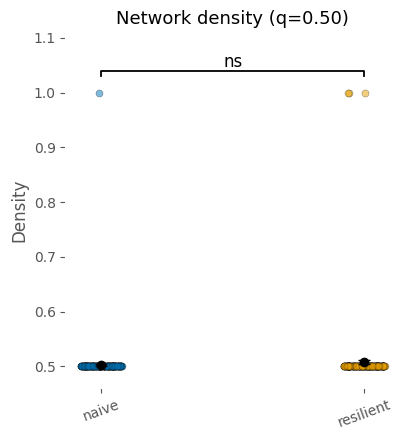


Saved to:
/content/drive/MyDrive/RNN_NW_density_q50_2026JUN23_2121


In [ ]:
#%%
# ==========================================================
# Density only, threshold q=0.50
# naive vs resilient
# Mann-Whitney U test
# Saves png/svg/pdf + stats CSV
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
from scipy.stats import mannwhitneyu


RUN_TS_DENSITY = datetime.now().strftime("%Y%b%d_%H%M").upper()

DENSITY_OUT = (
    Path("/content/drive/MyDrive")
    / f"RNN_NW_density_q50_{RUN_TS_DENSITY}"
)

DENSITY_OUT.mkdir(parents=True, exist_ok=True)


CONDITION_ORDER = ["naive", "resilient"]


COLORS = {
    "naive": "#0072B2",
    "resilient": "#E69F00",
}


def p_to_stars(p):
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"


def sem(x):
    x = np.asarray(x)
    return np.std(x, ddof=1)/np.sqrt(len(x))


def add_sig_bar(ax, x1, x2, y, h, text):

    ax.plot(
        [x1,x1,x2,x2],
        [y,y+h,y+h,y],
        lw=1.3,
        color='black'
    )

    ax.text(
        (x1+x2)/2,
        y+h,
        text,
        ha='center',
        va='bottom',
        fontsize=12
    )


def compute_density_q(W_rec, q=0.50):

    W = np.abs(
        np.asarray(W_rec, dtype=float)
    )


    N = W.shape[0]

    offdiag = ~np.eye(N, dtype=bool)

    vals = W[offdiag]


    thr = np.quantile(vals, q)


    A = (

        (W >= thr)

        & offdiag

    ).astype(int)



    num_edges = int(A.sum())


    n_possible = int(

        N*(N-1)

    )


    density = num_edges / n_possible



    return density, num_edges, n_possible, thr



############################################################

rows=[]


for condition in CONDITION_ORDER:


    for network_idx,W_rec in enumerate(

            loaded_networks[condition]["W_rec_list"]

    ):


        density,num_edges,n_possible,thr = compute_density_q(

                W_rec,

                q=0.50

        )



        rows.append({


            "condition":condition,

            "network_idx":network_idx,

            "threshold":0.50,

            "threshold_value":thr,

            "density":density,

            "num_edges":num_edges,

            "n_possible":n_possible

        })



density_df = pd.DataFrame(rows)



density_csv = (

        DENSITY_OUT

        /

        f"density_q50_values_{RUN_TS_DENSITY}.csv"

)


density_df.to_csv(

        density_csv,

        index=False

)


display(density_df.head())


############################################################
# statistics
############################################################

a = density_df.query(

        "condition=='naive'"

)["density"].values



b = density_df.query(

        "condition=='resilient'"

)["density"].values




U,p = mannwhitneyu(

        a,

        b,

        alternative='two-sided'

)



stats_df = pd.DataFrame([{

    "metric":"density",

    "threshold":0.50,


    "naive_n":len(a),
    "naive_mean":np.mean(a),
    "naive_sd":np.std(a),
    "naive_median":np.median(a),


    "resilient_n":len(b),
    "resilient_mean":np.mean(b),
    "resilient_sd":np.std(b),
    "resilient_median":np.median(b),



    "U":U,
    "p":p,

    "sig":p_to_stars(p)

}])


stats_csv = (

        DENSITY_OUT

        /

        f"density_q50_stats_{RUN_TS_DENSITY}.csv"

)


stats_df.to_csv(

        stats_csv,

        index=False

)

display(stats_df)



############################################################
# plot
############################################################

fig,ax = plt.subplots(

        figsize=(4.2,4.5),

        facecolor='white'

)


fig.patch.set_facecolor('white')
ax.set_facecolor('white')



rng=np.random.default_rng(42)



for x,cond,vals in zip(

        [1,2],

        CONDITION_ORDER,

        [a,b]

):


    jitter = rng.uniform(

            -0.08,

            0.08,

            len(vals)

    )


    ax.scatter(

        np.full(len(vals),x)+jitter,

        vals,


        s=26,

        alpha=.5,


        color=COLORS[cond],

        edgecolor='black',

        linewidth=.30

    )


    ax.errorbar(

        x,

        np.mean(vals),

        yerr=sem(vals),

        fmt='o',

        color='black',

        capsize=4

    )



ymin=min(np.min(a),np.min(b))
ymax=max(np.max(a),np.max(b))

yr=ymax-ymin

if yr==0:
    yr=.01



add_sig_bar(

        ax,

        1,

        2,

        ymax+.06*yr,

        .02*yr,

        p_to_stars(p)

)



ax.set_ylim(

        ymin-.08*yr,

        ymax+.22*yr

)



ax.set_xticks([1,2])

ax.set_xticklabels(

        ["naive","resilient"],

        rotation=20

)



ax.set_ylabel(

        "Density",

        fontsize=12

)



ax.set_title(

        "Network density (q=0.50)",

        fontsize=13

)



ax.grid(False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_linewidth(.8)
ax.spines["bottom"].set_linewidth(.8)



plt.tight_layout()



for ext in [

        "png",

        "svg",

        "pdf"

]:


    path = (

        DENSITY_OUT

        /

        f"density_q50_naive_vs_resilient_{RUN_TS_DENSITY}.{ext}"

    )


    fig.savefig(

            path,

            dpi=600,

            facecolor='white',

            bbox_inches='tight'

    )


plt.show()


print("\nSaved to:")
print(DENSITY_OUT)

/tmp/ipykernel_1357/3326531896.py:324: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


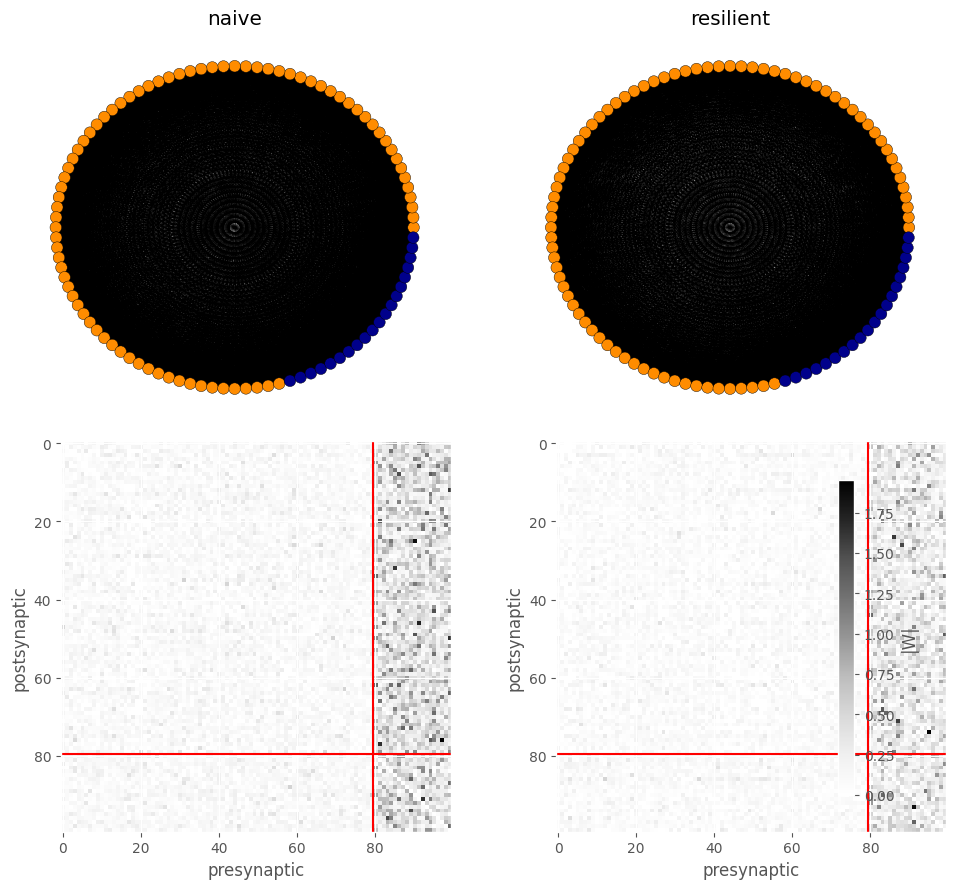

In [ ]:
# ==========================================================
# Plot network + adjacency matrix
# threshold = None
# W_rec[post,pre]
# edge = pre -> post
# ==========================================================

import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec
from matplotlib.colors import Normalize


network_idx = 0


W_naive = loaded_networks["naive"]["W_rec_list"][network_idx]
W_res = loaded_networks["resilient"]["W_rec_list"][network_idx]

N_exc = loaded_networks["naive"]["N_exc"]


colors = {

    "E":"darkorange",
    "I":"darkblue"

}


def build_graph(W):

    G = nx.DiGraph()

    N = W.shape[0]

    G.add_nodes_from(range(N))


    for post in range(N):
        for pre in range(N):

            if pre==post:
                continue


            w = W[post,pre]

            if w==0:
                continue


            G.add_edge(

                pre,
                post,

                weight=w,
                alpha=np.abs(w)

            )


    return G



def draw_network(ax, W, title):


    G = build_graph(W)


    N = W.shape[0]


    pos = nx.circular_layout(G)



    node_colors=[]


    for i in range(N):

        if i < N_exc:
            node_colors.append(colors["E"])

        else:
            node_colors.append(colors["I"])



    edges = list(G.edges())


    weights = np.array([

        G[u][v]["alpha"]

        for u,v in edges

    ])


    weights = weights/weights.max()



    nx.draw_networkx_nodes(

        G,
        pos,

        node_size=70,

        node_color=node_colors,

        edgecolors='black',

        linewidths=0.3,

        ax=ax

    )



    nx.draw_networkx_edges(

        G,
        pos,


        edge_color='black',


        alpha=0.15,


        width=0.5,


        arrows=False,


        ax=ax

    )



    for (u,v),a in zip(edges,weights):


        nx.draw_networkx_edges(

            G,
            pos,

            edgelist=[(u,v)],

            edge_color='black',

            alpha=a,

            width=0.6,

            arrows=False,

            ax=ax

        )



    ax.set_title(title)

    ax.axis("off")



def draw_matrix(ax,W):



    im=ax.imshow(


        np.abs(W),

        cmap='Greys',

        interpolation='nearest'

    )



    ax.axhline(

        N_exc-0.5,

        color='red'

    )


    ax.axvline(

        N_exc-0.5,

        color='red'

    )



    ax.set_xlabel("presynaptic")

    ax.set_ylabel("postsynaptic")


    return im





fig=plt.figure(

        figsize=(10,9),

        facecolor='white'

)


gs=GridSpec(

        2,
        2,

        height_ratios=[2,2]

)





ax1=fig.add_subplot(gs[0,0])

draw_network(

        ax1,

        W_naive,

        'naive'

)





ax2=fig.add_subplot(gs[0,1])

draw_network(

        ax2,

        W_res,

        'resilient'

)




ax3=fig.add_subplot(gs[1,0])

im=draw_matrix(

        ax3,

        W_naive

)




ax4=fig.add_subplot(gs[1,1])

draw_matrix(

        ax4,

        W_res

)



cbar=fig.colorbar(

        im,

        ax=[ax3,ax4],

        fraction=0.03

)


cbar.set_label("|W|")



plt.tight_layout()

plt.show()

Saving to:
/content/drive/MyDrive/RNN_NW_graph_None_alpha_2026JUN23_2140


/tmp/ipykernel_1357/3107131639.py:327: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


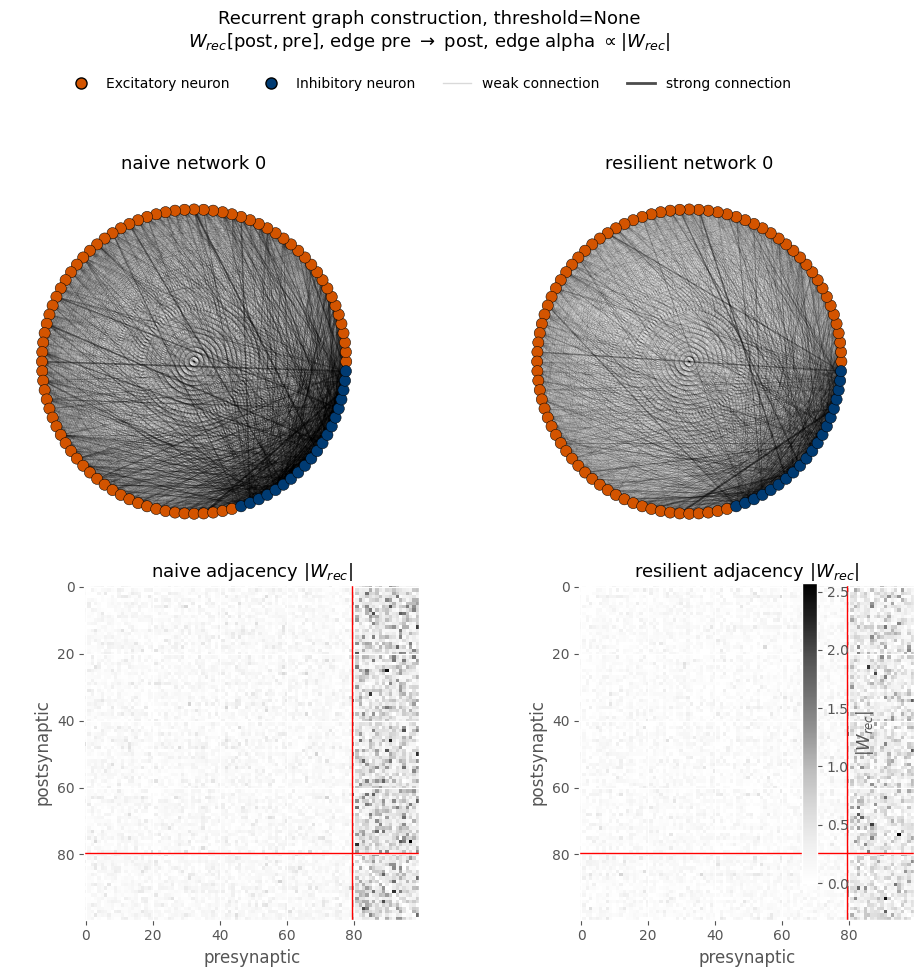

Saved to:
/content/drive/MyDrive/RNN_NW_graph_None_alpha_2026JUN23_2140


In [ ]:
#%%
# ==========================================================
# Circular graph + adjacency matrix
# threshold = None
#
# W_rec[post, pre]
# edge = pre -> post
#
# Edge transparency alpha ∝ |W_rec|
# E nodes = dark orange
# I nodes = dark blue
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from pathlib import Path
from datetime import datetime


# ----------------------------------------------------------
# User settings
# ----------------------------------------------------------

network_idx = 0

RUN_TS_GRAPH = datetime.now().strftime("%Y%b%d_%H%M").upper()

GRAPH_OUT = (
    Path("/content/drive/MyDrive")
    / f"RNN_NW_graph_None_alpha_{RUN_TS_GRAPH}"
)

GRAPH_OUT.mkdir(parents=True, exist_ok=True)

print("Saving to:")
print(GRAPH_OUT)


CONDITION_ORDER = ["naive", "resilient"]

NODE_COLORS = {
    "E": "#D35400",   # dark orange
    "I": "#003B73",   # dark blue
}

EDGE_COLOR = "black"


# ----------------------------------------------------------
# Build graph
# ----------------------------------------------------------

def build_graph_none(W_rec):
    """
    Build directed graph from W_rec without threshold.

    W_rec[post, pre]
    edge = pre -> post
    """
    W = np.asarray(W_rec, dtype=float).copy()
    np.fill_diagonal(W, 0.0)

    N = W.shape[0]

    G = nx.DiGraph()
    G.add_nodes_from(range(N))

    post_idx, pre_idx = np.where(W != 0)

    for post, pre in zip(post_idx, pre_idx):

        w = float(W[post, pre])

        G.add_edge(
            int(pre),
            int(post),
            weight_signed=w,
            weight_abs=abs(w),
        )

    return G


def circular_layout_ei(N, N_exc):
    """
    Put all neurons on one circle.
    E neurons first, then I neurons.
    """
    pos = {}

    theta = np.linspace(
        0,
        2 * np.pi,
        N,
        endpoint=False
    )

    for node, angle in enumerate(theta):
        pos[node] = np.array([
            np.cos(angle),
            np.sin(angle)
        ])

    return pos


# ----------------------------------------------------------
# Draw graph with weighted alpha
# ----------------------------------------------------------

def draw_graph_alpha(ax, W_rec, N_exc, title):
    """
    Draw graph with edge alpha proportional to |W|.
    """
    G = build_graph_none(W_rec)

    N = W_rec.shape[0]

    pos = circular_layout_ei(N, N_exc)

    weights = np.array(
        [d["weight_abs"] for _, _, d in G.edges(data=True)],
        dtype=float
    )

    if len(weights) == 0:
        max_w = 1.0
    else:
        max_w = np.nanmax(weights)

    node_color_list = [
        NODE_COLORS["E"] if node < N_exc else NODE_COLORS["I"]
        for node in G.nodes()
    ]

    # nodes
    nx.draw_networkx_nodes(
        G,
        pos,
        node_color=node_color_list,
        node_size=65,
        edgecolors="black",
        linewidths=0.35,
        ax=ax,
    )

    # edges drawn one by one so alpha can vary per edge
    for u, v, d in G.edges(data=True):

        alpha = 0.02 + 0.55 * (d["weight_abs"] / max_w)

        width = 0.15 + 1.20 * (d["weight_abs"] / max_w)

        nx.draw_networkx_edges(
            G,
            pos,
            edgelist=[(u, v)],
            edge_color=EDGE_COLOR,
            alpha=float(alpha),
            width=float(width),
            arrows=False,
            ax=ax,
        )

    ax.set_title(title, fontsize=13)
    ax.axis("off")
    ax.set_aspect("equal")


# ----------------------------------------------------------
# Draw adjacency matrix
# ----------------------------------------------------------

def draw_adjacency_abs(ax, W_rec, N_exc, title):
    """
    Plot |W_rec| adjacency matrix.

    rows = post
    cols = pre
    """
    W = np.abs(np.asarray(W_rec, dtype=float).copy())
    np.fill_diagonal(W, 0.0)

    vmax = np.nanmax(W)
    if vmax == 0 or np.isnan(vmax):
        vmax = 1.0

    im = ax.imshow(
        W,
        cmap="Greys",
        vmin=0,
        vmax=vmax,
        interpolation="nearest",
        aspect="equal",
    )

    ax.axhline(N_exc - 0.5, color="red", linewidth=1.0)
    ax.axvline(N_exc - 0.5, color="red", linewidth=1.0)

    ax.set_xlabel("presynaptic")
    ax.set_ylabel("postsynaptic")
    ax.set_title(title, fontsize=13)

    return im


# ----------------------------------------------------------
# Load selected networks
# ----------------------------------------------------------

W_naive = loaded_networks["naive"]["W_rec_list"][network_idx]
W_res = loaded_networks["resilient"]["W_rec_list"][network_idx]

N_exc = loaded_networks["naive"]["N_exc"]


# ----------------------------------------------------------
# Plot
# ----------------------------------------------------------

fig, axes = plt.subplots(
    2,
    2,
    figsize=(10, 9),
    facecolor="white",
    gridspec_kw={"height_ratios": [1.1, 1.0]},
)

fig.patch.set_facecolor("white")

for ax in axes.ravel():
    ax.set_facecolor("white")


draw_graph_alpha(
    axes[0, 0],
    W_naive,
    N_exc,
    f"naive network {network_idx}",
)

draw_graph_alpha(
    axes[0, 1],
    W_res,
    N_exc,
    f"resilient network {network_idx}",
)

im1 = draw_adjacency_abs(
    axes[1, 0],
    W_naive,
    N_exc,
    r"naive adjacency $|W_{rec}|$",
)

im2 = draw_adjacency_abs(
    axes[1, 1],
    W_res,
    N_exc,
    r"resilient adjacency $|W_{rec}|$",
)


# shared colorbar
cbar = fig.colorbar(
    im2,
    ax=axes[1, :],
    fraction=0.035,
    pad=0.04,
)

cbar.set_label(r"$|W_{rec}|$")


# legend
legend_elements = [
    plt.Line2D(
        [0], [0],
        marker="o",
        color="w",
        label="Excitatory neuron",
        markerfacecolor=NODE_COLORS["E"],
        markeredgecolor="black",
        markersize=8,
    ),
    plt.Line2D(
        [0], [0],
        marker="o",
        color="w",
        label="Inhibitory neuron",
        markerfacecolor=NODE_COLORS["I"],
        markeredgecolor="black",
        markersize=8,
    ),
    plt.Line2D(
        [0], [0],
        color="black",
        alpha=0.15,
        lw=1,
        label="weak connection",
    ),
    plt.Line2D(
        [0], [0],
        color="black",
        alpha=0.7,
        lw=2,
        label="strong connection",
    ),
]

fig.legend(
    handles=legend_elements,
    loc="upper center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, 1.02),
)

fig.suptitle(
    "Recurrent graph construction, threshold=None\n"
    r"$W_{rec}[\mathrm{post},\mathrm{pre}]$, edge pre $\rightarrow$ post, edge alpha $\propto |W_{rec}|$",
    fontsize=13,
    y=1.08,
)

plt.tight_layout()


# ----------------------------------------------------------
# Save
# ----------------------------------------------------------

for ext in ["png", "svg", "pdf"]:
    outpath = (
        GRAPH_OUT
        / f"network_graph_adjacency_None_alpha_idx{network_idx}_{RUN_TS_GRAPH}.{ext}"
    )

    fig.savefig(
        outpath,
        dpi=600,
        facecolor="white",
        bbox_inches="tight",
    )

plt.show()

print("Saved to:")
print(GRAPH_OUT)

Saving to:
/content/drive/MyDrive/RNN_NW_density_None_2026JUN23_2105
Saved density values:
/content/drive/MyDrive/RNN_NW_density_None_2026JUN23_2105/density_None_values_2026JUN23_2105.csv


,condition,network_idx,threshold,density,num_edges,n_possible
0,naive,0,None,0.887980,8791,9900
1,naive,1,None,0.828687,8204,9900
2,naive,2,None,0.884545,8757,9900
3,naive,3,None,0.781414,7736,9900
4,naive,4,None,0.632828,6265,9900


Saved stats:
/content/drive/MyDrive/RNN_NW_density_None_2026JUN23_2105/density_None_mannwhitney_stats_2026JUN23_2105.csv


,metric,threshold,naive_n,naive_mean,naive_sd,naive_median,resilient_n,resilient_mean,resilient_sd,resilient_median,U,p,sig
0,density,None,200,0.790177,0.074774,0.807727,200,0.713105,0.087599,0.721667,30414.0,2.115423e-19,***


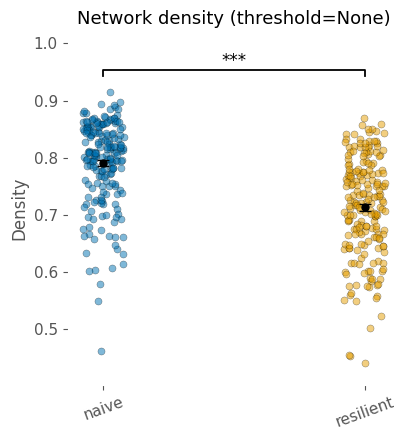

Saved plot files to:
/content/drive/MyDrive/RNN_NW_density_None_2026JUN23_2105


In [ ]:
#%%
# ==========================================================
# Density only, threshold None
# naive vs resilient
# Mann-Whitney U test
# Saves png/svg/pdf + stats CSV
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
from scipy.stats import mannwhitneyu

RUN_TS_DENSITY = datetime.now().strftime("%Y%b%d_%H%M").upper()

DENSITY_OUT = Path("/content/drive/MyDrive") / f"RNN_NW_density_None_{RUN_TS_DENSITY}"
DENSITY_OUT.mkdir(parents=True, exist_ok=True)

print("Saving to:")
print(DENSITY_OUT)


CONDITION_ORDER = ["naive", "resilient"]

COLORS = {
    "naive": "#0072B2",
    "resilient": "#E69F00",
}


def p_to_stars(p):
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"


def sem(x):
    x = np.asarray(x, dtype=float)
    return np.std(x, ddof=1) / np.sqrt(len(x))


def add_sig_bar(ax, x1, x2, y, h, text):
    ax.plot(
        [x1, x1, x2, x2],
        [y, y+h, y+h, y],
        lw=1.3,
        color="black"
    )
    ax.text(
        (x1+x2)/2,
        y+h,
        text,
        ha="center",
        va="bottom",
        fontsize=12
    )


def compute_density_none(W_rec):
    """
    Density at threshold None.

    W_rec[post, pre]
    Self-loops excluded.
    All non-zero off-diagonal weights count as edges.
    """
    W = np.asarray(W_rec, dtype=float).copy()

    N = W.shape[0]
    offdiag = ~np.eye(N, dtype=bool)

    A = ((np.abs(W) > 0) & offdiag).astype(int)

    num_edges = int(A.sum())
    n_possible = int(N * (N - 1))

    density = num_edges / n_possible

    return density, num_edges, n_possible


# ----------------------------------------------------------
# Compute density for all networks
# ----------------------------------------------------------

rows = []

for condition in CONDITION_ORDER:

    for network_idx, W_rec in enumerate(
        loaded_networks[condition]["W_rec_list"]
    ):

        density, num_edges, n_possible = compute_density_none(W_rec)

        rows.append({
            "condition": condition,
            "network_idx": network_idx,
            "threshold": "None",
            "density": density,
            "num_edges": num_edges,
            "n_possible": n_possible,
        })


density_df = pd.DataFrame(rows)

density_csv = DENSITY_OUT / f"density_None_values_{RUN_TS_DENSITY}.csv"
density_df.to_csv(density_csv, index=False)

print("Saved density values:")
print(density_csv)

display(density_df.head())


# ----------------------------------------------------------
# Mann-Whitney U statistics
# ----------------------------------------------------------

a = density_df[
    density_df["condition"] == "naive"
]["density"].values

b = density_df[
    density_df["condition"] == "resilient"
]["density"].values

U, p = mannwhitneyu(
    a,
    b,
    alternative="two-sided"
)

stats_df = pd.DataFrame([{
    "metric": "density",
    "threshold": "None",
    "naive_n": len(a),
    "naive_mean": np.mean(a),
    "naive_sd": np.std(a),
    "naive_median": np.median(a),
    "resilient_n": len(b),
    "resilient_mean": np.mean(b),
    "resilient_sd": np.std(b),
    "resilient_median": np.median(b),
    "U": U,
    "p": p,
    "sig": p_to_stars(p),
}])

stats_csv = DENSITY_OUT / f"density_None_mannwhitney_stats_{RUN_TS_DENSITY}.csv"
stats_df.to_csv(stats_csv, index=False)

print("Saved stats:")
print(stats_csv)

display(stats_df)


# ----------------------------------------------------------
# Plot density
# ----------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(4.2, 4.5),
    facecolor="white"
)

fig.patch.set_facecolor("white")
ax.set_facecolor("white")

rng = np.random.default_rng(42)

samples = [a, b]

for x, condition, vals in zip([1, 2], CONDITION_ORDER, samples):

    jitter = rng.uniform(-0.08, 0.08, size=len(vals))

    ax.scatter(

        np.full(len(vals), x) + jitter,

        vals,

        s=26,

        alpha=0.50,

        color=COLORS[condition],

        edgecolor="black",

        linewidth=0.30,

        zorder=2

    )


    ax.errorbar(

        x,

        np.mean(vals),

        yerr=sem(vals),

        fmt='o',

        color='black',

        markersize=5,

        capsize=4,

        lw=1.0,

        zorder=5

    )


# ----------------------------------------------------------
# significance
# ----------------------------------------------------------

y_min = min(np.min(a), np.min(b))
y_max = max(np.max(a), np.max(b))

yr = y_max - y_min

if yr == 0:
    yr = 0.01


add_sig_bar(

        ax,

        1,

        2,

        y_max + 0.06*yr,

        0.02*yr,

        p_to_stars(p)

)



ax.set_ylim(

        y_min - 0.08*yr,

        y_max + 0.22*yr

)


# ----------------------------------------------------------
# cosmetics
# ----------------------------------------------------------

ax.set_xticks([1,2])

ax.set_xticklabels(

        ["naive","resilient"],

        rotation=20

)


ax.set_ylabel(

        "Density",

        fontsize=12

)


ax.set_title(

        "Network density (threshold=None)",

        fontsize=13

)



# publication style

ax.grid(False)


ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_linewidth(0.8)
ax.spines["bottom"].set_linewidth(0.8)


ax.tick_params(

        axis='both',

        labelsize=11,

        width=0.8

)



plt.tight_layout()



# ----------------------------------------------------------
# save
# ----------------------------------------------------------

for ext in ["png","svg","pdf"]:


    plot_path = (

        DENSITY_OUT /

        f"density_None_naive_vs_resilient_{RUN_TS_DENSITY}.{ext}"

    )


    fig.savefig(

            plot_path,

            dpi=600,

            facecolor="white",

            edgecolor="none",

            bbox_inches="tight"

    )



plt.show()


print("Saved plot files to:")
print(DENSITY_OUT)

In [ ]:
#%%
# ==========================================================
# Graph plots + adjacency matrices
# Threshold: None only
#
# For selected network indices:
#   - left: naive
#   - right: resilient
#   - circular graph with E/I node colors
#   - node shapes encode source/target block role:
#       E->E : circle
#       E->I : square
#       I->E : diamond
#       I->I : triangle
#   - edge alpha encodes |weight|
#   - adjacency matrix saved in same folder
#
# Saves png/svg/pdf into:
#   .../graph_plots/<timestamp>/
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

from pathlib import Path
from datetime import datetime
from matplotlib.lines import Line2D
from matplotlib.patches import Patch


# ----------------------------------------------------------
# User settings
# ----------------------------------------------------------

network_idx_list = [0, 1, 2, 3, 4]   # adapt this list as needed

RUN_TS_GRAPH = datetime.now().strftime("%Y%b%d_%H%M").upper()

GRAPH_PLOTS_DIR = Path("/content/drive/MyDrive") / f"RNN_NW_results_2026JUN_{RUN_TS_GRAPH}" / "graph_plots"
GRAPH_PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print("Saving graph plots to:")
print(GRAPH_PLOTS_DIR)


# ----------------------------------------------------------
# Plot style
# ----------------------------------------------------------

NODE_COLORS = {
    "E": "#D35400",   # dark orange
    "I": "#0B3C5D",   # dark blue
}

EDGE_COLORS = {
    "positive": "#D35400",
    "negative": "#0B3C5D",
}

BLOCK_MARKERS = {
    "E->E": "o",   # circle
    "E->I": "s",   # square
    "I->E": "D",   # diamond / raute
    "I->I": "^",   # triangle
}


# ----------------------------------------------------------
# Helpers
# ----------------------------------------------------------

def save_fig_all_formats(fig, basepath, dpi=300):
    for ext in ["png", "svg", "pdf"]:
        fig.savefig(f"{basepath}.{ext}", dpi=dpi, bbox_inches="tight")


def get_block_of_edge(pre, post, N_exc):
    pre_type = "E" if pre < N_exc else "I"
    post_type = "E" if post < N_exc else "I"
    return f"{pre_type}->{post_type}"


def circular_positions_by_population(N, N_exc):
    """
    E and I nodes are placed on two separated circles.
    """
    pos = {}

    E_nodes = np.arange(0, N_exc)
    I_nodes = np.arange(N_exc, N)

    theta_E = np.linspace(0, 2 * np.pi, len(E_nodes), endpoint=False)
    theta_I = np.linspace(0, 2 * np.pi, len(I_nodes), endpoint=False)

    # left circle = E
    for node, theta in zip(E_nodes, theta_E):
        pos[int(node)] = np.array([
            -1.15 + 0.82 * np.cos(theta),
             0.00 + 0.82 * np.sin(theta),
        ])

    # right circle = I
    for node, theta in zip(I_nodes, theta_I):
        pos[int(node)] = np.array([
             1.15 + 0.55 * np.cos(theta),
             0.00 + 0.55 * np.sin(theta),
        ])

    return pos


def build_full_graph_none(W_rec):
    """
    Build full weighted directed graph.

    Convention:
        W_rec[post, pre]
        edge: pre -> post

    No quantile threshold.
    Only zero weights and self-loops are excluded.
    """
    W = np.asarray(W_rec, dtype=float).copy()
    np.fill_diagonal(W, 0.0)

    N = W.shape[0]

    G = nx.DiGraph()
    G.add_nodes_from(range(N))

    post_idx, pre_idx = np.where(W != 0)

    for post, pre in zip(post_idx, pre_idx):
        signed_w = float(W[post, pre])
        abs_w = abs(signed_w)

        G.add_edge(
            int(pre),
            int(post),
            weight_signed=signed_w,
            weight_abs=abs_w,
            sign="positive" if signed_w > 0 else "negative",
            block=get_block_of_edge(pre, post, N_exc=80),  # overwritten below if needed
        )

    return G


def plot_single_network_graph(ax, W_rec, N_exc, condition, title):
    """
    Circular graph plot for one network.
    Shows all non-zero edges.
    Edge alpha scales with |W|.
    Node color = E/I.
    Node shape = dominant outgoing block class for readability.
    """
    W = np.asarray(W_rec, dtype=float).copy()
    np.fill_diagonal(W, 0.0)

    N = W.shape[0]
    G = nx.DiGraph()
    G.add_nodes_from(range(N))

    post_idx, pre_idx = np.where(W != 0)

    for post, pre in zip(post_idx, pre_idx):
        signed_w = float(W[post, pre])
        abs_w = abs(signed_w)

        G.add_edge(
            int(pre),
            int(post),
            weight_signed=signed_w,
            weight_abs=abs_w,
            sign="positive" if signed_w > 0 else "negative",
            block=get_block_of_edge(pre, post, N_exc),
        )

    pos = circular_positions_by_population(N, N_exc)

    all_abs = np.array(
        [d["weight_abs"] for _, _, d in G.edges(data=True)],
        dtype=float,
    )

    if len(all_abs) == 0:
        max_abs = 1.0
    else:
        max_abs = np.nanmax(all_abs)

    # Draw edges block-wise, sign by color, magnitude by alpha
    for sign_name in ["positive", "negative"]:
        edgelist = [
            (u, v)
            for u, v, d in G.edges(data=True)
            if d["sign"] == sign_name
        ]

        if len(edgelist) == 0:
            continue

        edge_alphas = [
            0.03 + 0.35 * (G[u][v]["weight_abs"] / max_abs)
            for u, v in edgelist
        ]

        edge_widths = [
            0.15 + 1.20 * (G[u][v]["weight_abs"] / max_abs)
            for u, v in edgelist
        ]

        # NetworkX does not support individual alpha robustly in all versions,
        # so draw edges one by one.
        for (u, v), alpha, width in zip(edgelist, edge_alphas, edge_widths):
            nx.draw_networkx_edges(
                G,
                pos,
                edgelist=[(u, v)],
                ax=ax,
                edge_color=EDGE_COLORS[sign_name],
                alpha=float(alpha),
                width=float(width),
                arrows=True,
                arrowsize=4,
                connectionstyle="arc3,rad=0.06",
            )

    # Node markers: use block role approximated by node population and outgoing target population.
    # E nodes are split into E->E and E->I role by marker.
    # I nodes are split into I->E and I->I role by marker.
    E_nodes = list(range(0, N_exc))
    I_nodes = list(range(N_exc, N))

    # For visual block encoding:
    # E source nodes: circle; I source nodes: triangle.
    # To still show all four shapes, add small overlay markers for block anchors.
    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=E_nodes,
        node_color=NODE_COLORS["E"],
        node_shape="o",
        node_size=58,
        edgecolors="white",
        linewidths=0.45,
        ax=ax,
    )

    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=I_nodes,
        node_color=NODE_COLORS["I"],
        node_shape="^",
        node_size=70,
        edgecolors="white",
        linewidths=0.45,
        ax=ax,
    )

    # Block symbols as anchors around the plot
    anchor_positions = {
        "E->E": (-1.15,  1.10),
        "E->I": ( 0.00,  1.10),
        "I->E": ( 0.00, -1.10),
        "I->I": ( 1.15, -1.10),
    }

    for block, (x, y) in anchor_positions.items():
        ax.scatter(
            x,
            y,
            s=90,
            marker=BLOCK_MARKERS[block],
            color="black",
            zorder=10,
        )
        ax.text(
            x,
            y - 0.14,
            block,
            ha="center",
            va="top",
            fontsize=7,
        )

    ax.text(-1.15, -1.32, "E circle", ha="center", fontsize=8)
    ax.text(1.15, -1.32, "I circle", ha="center", fontsize=8)

    ax.set_title(title, fontsize=10)
    ax.set_aspect("equal")
    ax.axis("off")


def plot_single_adjacency(ax, W_rec, N_exc, condition, title):
    """
    Signed adjacency matrix of actual W_rec.
    No threshold.
    """
    W = np.asarray(W_rec, dtype=float).copy()
    np.fill_diagonal(W, 0.0)

    vmax = np.nanmax(np.abs(W))
    if vmax == 0 or np.isnan(vmax):
        vmax = 1.0

    im = ax.imshow(
        W,
        cmap="RdBu_r",
        vmin=-vmax,
        vmax=vmax,
        interpolation="nearest",
        aspect="equal",
    )

    ax.axvline(N_exc - 0.5, color="black", linestyle="--", linewidth=1)
    ax.axhline(N_exc - 0.5, color="black", linestyle="--", linewidth=1)

    ax.set_xlabel("pre")
    ax.set_ylabel("post")
    ax.set_title(title, fontsize=10)

    return im


def create_combined_naive_resilient_plot(network_idx):
    """
    One figure per network index:
        left: naive graph + adjacency
        right: resilient graph + adjacency
    """
    W_naive = loaded_networks["naive"]["W_rec_list"][network_idx]
    W_res = loaded_networks["resilient"]["W_rec_list"][network_idx]

    N_exc_naive = loaded_networks["naive"]["N_exc"]
    N_exc_res = loaded_networks["resilient"]["N_exc"]

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(11, 9),
        gridspec_kw={"height_ratios": [1.05, 1.0]},
    )

    plot_single_network_graph(
        axes[0, 0],
        W_naive,
        N_exc_naive,
        "naive",
        f"Naive network {network_idx}\nCircular graph, threshold None",
    )

    plot_single_network_graph(
        axes[0, 1],
        W_res,
        N_exc_res,
        "resilient",
        f"Resilient network {network_idx}\nCircular graph, threshold None",
    )

    im1 = plot_single_adjacency(
        axes[1, 0],
        W_naive,
        N_exc_naive,
        "naive",
        "Naive W_rec adjacency\nW_rec[post, pre]",
    )

    im2 = plot_single_adjacency(
        axes[1, 1],
        W_res,
        N_exc_res,
        "resilient",
        "Resilient W_rec adjacency\nW_rec[post, pre]",
    )

    # one shared colorbar
    cbar = fig.colorbar(
        im2,
        ax=axes[1, :],
        fraction=0.035,
        pad=0.04,
    )
    cbar.set_label("effective recurrent weight")

    legend_handles = [
        Line2D(
            [0], [0],
            marker="o",
            color="w",
            label="Excitatory neuron",
            markerfacecolor=NODE_COLORS["E"],
            markeredgecolor="white",
            markersize=8,
        ),
        Line2D(
            [0], [0],
            marker="^",
            color="w",
            label="Inhibitory neuron",
            markerfacecolor=NODE_COLORS["I"],
            markeredgecolor="white",
            markersize=8,
        ),
        Line2D(
            [0], [0],
            color=EDGE_COLORS["positive"],
            lw=2,
            label="Positive weight",
        ),
        Line2D(
            [0], [0],
            color=EDGE_COLORS["negative"],
            lw=2,
            label="Negative weight",
        ),
        Line2D(
            [0], [0],
            marker="o",
            color="black",
            label="E→E block marker",
            markersize=7,
            linestyle="None",
        ),
        Line2D(
            [0], [0],
            marker="s",
            color="black",
            label="E→I block marker",
            markersize=7,
            linestyle="None",
        ),
        Line2D(
            [0], [0],
            marker="D",
            color="black",
            label="I→E block marker",
            markersize=7,
            linestyle="None",
        ),
        Line2D(
            [0], [0],
            marker="^",
            color="black",
            label="I→I block marker",
            markersize=7,
            linestyle="None",
        ),
    ]

    fig.legend(
        handles=legend_handles,
        loc="upper center",
        ncol=4,
        frameon=False,
        fontsize=8,
        bbox_to_anchor=(0.5, 1.01),
    )

    fig.suptitle(
        f"Actual recurrent networks, network index {network_idx}\n"
        "Threshold None; edge pre → post; edge alpha ∝ |W_rec|",
        fontsize=13,
        y=1.08,
    )

    plt.tight_layout()

    base = GRAPH_PLOTS_DIR / f"actual_network_idx{network_idx}_naive_left_resilient_right_None_{RUN_TS_GRAPH}"

    save_fig_all_formats(fig, base)

    plt.show()
    plt.close(fig)


# ----------------------------------------------------------
# Run selected network indices
# ----------------------------------------------------------

for network_idx in network_idx_list:
    create_combined_naive_resilient_plot(network_idx)

print("Saved plots to:")
print(GRAPH_PLOTS_DIR)

In [ ]:
#------------- wihout betweenness shorter

In [ ]:
#%%
# ==========================================================
# Circular graph + adjacency matrix
# threshold = None
#
# W_rec[post, pre]
# edge = pre -> post
#
# Edge transparency alpha ∝ |W_rec|
# E nodes = dark orange
# I nodes = dark blue
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from pathlib import Path
from datetime import datetime


# ----------------------------------------------------------
# User settings
# ----------------------------------------------------------

network_idx = 0

RUN_TS_GRAPH = datetime.now().strftime("%Y%b%d_%H%M").upper()

GRAPH_OUT = (
    Path("/content/drive/MyDrive")
    / f"RNN_NW_graph_None_alpha_{RUN_TS_GRAPH}"
)

GRAPH_OUT.mkdir(parents=True, exist_ok=True)

print("Saving to:")
print(GRAPH_OUT)


CONDITION_ORDER = ["naive", "resilient"]

NODE_COLORS = {
    "E": "#D35400",   # dark orange
    "I": "#003B73",   # dark blue
}

EDGE_COLOR = "black"


# ----------------------------------------------------------
# Build graph
# ----------------------------------------------------------

def build_graph_none(W_rec):
    """
    Build directed graph from W_rec without threshold.

    W_rec[post, pre]
    edge = pre -> post
    """
    W = np.asarray(W_rec, dtype=float).copy()
    np.fill_diagonal(W, 0.0)

    N = W.shape[0]

    G = nx.DiGraph()
    G.add_nodes_from(range(N))

    post_idx, pre_idx = np.where(W != 0)

    for post, pre in zip(post_idx, pre_idx):

        w = float(W[post, pre])

        G.add_edge(
            int(pre),
            int(post),
            weight_signed=w,
            weight_abs=abs(w),
        )

    return G


def circular_layout_ei(N, N_exc):
    """
    Put all neurons on one circle.
    E neurons first, then I neurons.
    """
    pos = {}

    theta = np.linspace(
        0,
        2 * np.pi,
        N,
        endpoint=False
    )

    for node, angle in enumerate(theta):
        pos[node] = np.array([
            np.cos(angle),
            np.sin(angle)
        ])

    return pos


# ----------------------------------------------------------
# Draw graph with weighted alpha
# ----------------------------------------------------------

def draw_graph_alpha(ax, W_rec, N_exc, title):
    """
    Draw graph with edge alpha proportional to |W|.
    """
    G = build_graph_none(W_rec)

    N = W_rec.shape[0]

    pos = circular_layout_ei(N, N_exc)

    weights = np.array(
        [d["weight_abs"] for _, _, d in G.edges(data=True)],
        dtype=float
    )

    if len(weights) == 0:
        max_w = 1.0
    else:
        max_w = np.nanmax(weights)

    node_color_list = [
        NODE_COLORS["E"] if node < N_exc else NODE_COLORS["I"]
        for node in G.nodes()
    ]

    # nodes
    nx.draw_networkx_nodes(
        G,
        pos,
        node_color=node_color_list,
        node_size=65,
        edgecolors="black",
        linewidths=0.35,
        ax=ax,
    )

    # edges drawn one by one so alpha can vary per edge
    for u, v, d in G.edges(data=True):

        alpha = 0.02 + 0.55 * (d["weight_abs"] / max_w)

        width = 0.15 + 1.20 * (d["weight_abs"] / max_w)

        nx.draw_networkx_edges(
            G,
            pos,
            edgelist=[(u, v)],
            edge_color=EDGE_COLOR,
            alpha=float(alpha),
            width=float(width),
            arrows=False,
            ax=ax,
        )

    ax.set_title(title, fontsize=13)
    ax.axis("off")
    ax.set_aspect("equal")


# ----------------------------------------------------------
# Draw adjacency matrix
# ----------------------------------------------------------

def draw_adjacency_abs(ax, W_rec, N_exc, title):
    """
    Plot |W_rec| adjacency matrix.

    rows = post
    cols = pre
    """
    W = np.abs(np.asarray(W_rec, dtype=float).copy())
    np.fill_diagonal(W, 0.0)

    vmax = np.nanmax(W)
    if vmax == 0 or np.isnan(vmax):
        vmax = 1.0

    im = ax.imshow(
        W,
        cmap="Greys",
        vmin=0,
        vmax=vmax,
        interpolation="nearest",
        aspect="equal",
    )

    ax.axhline(N_exc - 0.5, color="red", linewidth=1.0)
    ax.axvline(N_exc - 0.5, color="red", linewidth=1.0)

    ax.set_xlabel("presynaptic")
    ax.set_ylabel("postsynaptic")
    ax.set_title(title, fontsize=13)

    return im


# ----------------------------------------------------------
# Load selected networks
# ----------------------------------------------------------

W_naive = loaded_networks["naive"]["W_rec_list"][network_idx]
W_res = loaded_networks["resilient"]["W_rec_list"][network_idx]

N_exc = loaded_networks["naive"]["N_exc"]


# ----------------------------------------------------------
# Plot
# ----------------------------------------------------------

fig, axes = plt.subplots(
    2,
    2,
    figsize=(10, 9),
    facecolor="white",
    gridspec_kw={"height_ratios": [1.1, 1.0]},
)

fig.patch.set_facecolor("white")

for ax in axes.ravel():
    ax.set_facecolor("white")


draw_graph_alpha(
    axes[0, 0],
    W_naive,
    N_exc,
    f"naive network {network_idx}",
)

draw_graph_alpha(
    axes[0, 1],
    W_res,
    N_exc,
    f"resilient network {network_idx}",
)

im1 = draw_adjacency_abs(
    axes[1, 0],
    W_naive,
    N_exc,
    r"naive adjacency $|W_{rec}|$",
)

im2 = draw_adjacency_abs(
    axes[1, 1],
    W_res,
    N_exc,
    r"resilient adjacency $|W_{rec}|$",
)


# shared colorbar
cbar = fig.colorbar(
    im2,
    ax=axes[1, :],
    fraction=0.035,
    pad=0.04,
)

cbar.set_label(r"$|W_{rec}|$")


# legend
legend_elements = [
    plt.Line2D(
        [0], [0],
        marker="o",
        color="w",
        label="Excitatory neuron",
        markerfacecolor=NODE_COLORS["E"],
        markeredgecolor="black",
        markersize=8,
    ),
    plt.Line2D(
        [0], [0],
        marker="o",
        color="w",
        label="Inhibitory neuron",
        markerfacecolor=NODE_COLORS["I"],
        markeredgecolor="black",
        markersize=8,
    ),
    plt.Line2D(
        [0], [0],
        color="black",
        alpha=0.15,
        lw=1,
        label="weak connection",
    ),
    plt.Line2D(
        [0], [0],
        color="black",
        alpha=0.7,
        lw=2,
        label="strong connection",
    ),
]

fig.legend(
    handles=legend_elements,
    loc="upper center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, 1.02),
)

fig.suptitle(
    "Recurrent graph construction, threshold=None\n"
    r"$W_{rec}[\mathrm{post},\mathrm{pre}]$, edge pre $\rightarrow$ post, edge alpha $\propto |W_{rec}|$",
    fontsize=13,
    y=1.08,
)

plt.tight_layout()


# ----------------------------------------------------------
# Save
# ----------------------------------------------------------

for ext in ["png", "svg", "pdf"]:
    outpath = (
        GRAPH_OUT
        / f"network_graph_adjacency_None_alpha_idx{network_idx}_{RUN_TS_GRAPH}.{ext}"
    )

    fig.savefig(
        outpath,
        dpi=600,
        facecolor="white",
        bbox_inches="tight",
    )

plt.show()

print("Saved to:")
print(GRAPH_OUT)

Output folder:
/content/drive/MyDrive/RNN_NW_results_2026JUN_2026JUN23_2026
Processing threshold: None all non-zero edges


KeyboardInterrupt: 

In [ ]:
#%%
# ==========================================================
# Weighted directed metrics: thresholds None, 0.50, 0.80
# naive vs resilient_SUpItoE
# CSVs + example graph plots + Mann-Whitney stats
# ==========================================================

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
from scipy.stats import mannwhitneyu

# ----------------------------------------------------------
# Output folder
# ----------------------------------------------------------

RUN_TIMESTAMP = datetime.now().strftime("%Y%b%d_%H%M").upper()

OUT_ROOT = Path("/content/drive/MyDrive") / f"weighted_directed_metrics_check_{RUN_TIMESTAMP}"
RESULTS_WD = OUT_ROOT / "results"
PLOTS_WD = OUT_ROOT / "plots"

RESULTS_WD.mkdir(parents=True, exist_ok=True)
PLOTS_WD.mkdir(parents=True, exist_ok=True)

print("Output folder:")
print(OUT_ROOT)

# ----------------------------------------------------------
# Settings
# ----------------------------------------------------------

CONDITIONS_WD = {
    "naive": "naive",
    "resilient": "resilient",
}

THRESHOLDS_WD = (
    None,
    0.50,
    0.80,
)

EXAMPLE_NETWORKS = [1, 13, 67]

COLORS_WD = {
    "naive": "#0072B2",
    "resilient": "#E69F00",
}

N_NETWORKS = 200
EPS = 1e-12


def threshold_suffix(q):
    if q is None:
        return "thNone"
    return f"th{int(q * 100):02d}"


def threshold_label(q):
    if q is None:
        return "None / all non-zero edges"
    return f"q={q:.2f} / strongest {int((1-q)*100)}%"


def p_to_stars(p):
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"


# ----------------------------------------------------------
# Weighted directed graph construction
# ----------------------------------------------------------

def build_weighted_digraph_from_W(W_rec, q=None):
    """
    W_rec[post, pre]
    Graph edge: pre -> post

    Edge attributes:
        weight_abs    = abs(W_ij)
        weight_signed = W_ij
        distance_inv  = 1 / (abs(W_ij) + eps)
    """
    W = np.asarray(W_rec, dtype=float).copy()
    np.fill_diagonal(W, 0.0)

    N = W.shape[0]
    offdiag = ~np.eye(N, dtype=bool)
    abs_vals = np.abs(W[offdiag])

    if q is None:
        thr = 0.0
        mask = offdiag & (np.abs(W) > 0)
    else:
        thr = float(np.quantile(abs_vals, q))
        mask = offdiag & (np.abs(W) > thr)

    G = nx.DiGraph()
    G.add_nodes_from(range(N))

    post_idx, pre_idx = np.where(mask)

    for post, pre in zip(post_idx, pre_idx):
        signed_w = float(W[post, pre])
        abs_w = abs(signed_w)

        G.add_edge(
            int(pre),
            int(post),
            weight_abs=abs_w,
            weight_signed=signed_w,
            distance_inv=1.0 / (abs_w + EPS),
            sign=1 if signed_w > 0 else -1 if signed_w < 0 else 0,
        )

    return G, thr


# ----------------------------------------------------------
# Metric computation
# ----------------------------------------------------------

def safe_dict_stats(d, prefix):
    try:
        vals = np.asarray(list(d.values()), dtype=float)
        return {
            f"mean_{prefix}": float(np.nanmean(vals)),
            f"std_{prefix}": float(np.nanstd(vals)),
            f"max_{prefix}": float(np.nanmax(vals)),
        }
    except Exception:
        return {
            f"mean_{prefix}": np.nan,
            f"std_{prefix}": np.nan,
            f"max_{prefix}": np.nan,
        }


def compute_weighted_directed_metrics(W_rec, condition, network_idx, q):
    G, thr = build_weighted_digraph_from_W(W_rec, q=q)

    in_deg = np.asarray([d for _, d in G.in_degree()], dtype=float)
    out_deg = np.asarray([d for _, d in G.out_degree()], dtype=float)

    in_strength = np.asarray([d for _, d in G.in_degree(weight="weight_abs")], dtype=float)
    out_strength = np.asarray([d for _, d in G.out_degree(weight="weight_abs")], dtype=float)
    total_strength = in_strength + out_strength

    pos_in, neg_in, pos_out, neg_out = [], [], [], []

    for node in G.nodes():
        in_edges = G.in_edges(node, data=True)
        out_edges = G.out_edges(node, data=True)

        pos_in.append(sum(d["weight_signed"] for _, _, d in in_edges if d["weight_signed"] > 0))
        neg_in.append(sum(abs(d["weight_signed"]) for _, _, d in in_edges if d["weight_signed"] < 0))
        pos_out.append(sum(d["weight_signed"] for _, _, d in out_edges if d["weight_signed"] > 0))
        neg_out.append(sum(abs(d["weight_signed"]) for _, _, d in out_edges if d["weight_signed"] < 0))

    row = {
        "condition": condition,
        "network_idx": network_idx,
        "threshold_q": "None" if q is None else q,
        "threshold_suffix": threshold_suffix(q),
        "threshold_label": threshold_label(q),
        "threshold_value": thr,

        "num_nodes": G.number_of_nodes(),
        "num_edges": G.number_of_edges(),
        "density": nx.density(G),
        "reciprocity": nx.reciprocity(G),

        "mean_degree_total": float(np.mean(in_deg + out_deg)),
        "mean_in_degree": float(np.mean(in_deg)),
        "mean_out_degree": float(np.mean(out_deg)),
        "std_in_degree": float(np.std(in_deg)),
        "std_out_degree": float(np.std(out_deg)),
        "max_in_degree": float(np.max(in_deg)),
        "max_out_degree": float(np.max(out_deg)),

        "mean_total_strength_abs": float(np.mean(total_strength)),
        "mean_in_strength_abs": float(np.mean(in_strength)),
        "mean_out_strength_abs": float(np.mean(out_strength)),
        "std_total_strength_abs": float(np.std(total_strength)),
        "std_in_strength_abs": float(np.std(in_strength)),
        "std_out_strength_abs": float(np.std(out_strength)),
        "max_total_strength_abs": float(np.max(total_strength)),
        "max_in_strength_abs": float(np.max(in_strength)),
        "max_out_strength_abs": float(np.max(out_strength)),

        "mean_positive_in_weight": float(np.mean(pos_in)),
        "mean_negative_in_weight_abs": float(np.mean(neg_in)),
        "mean_positive_out_weight": float(np.mean(pos_out)),
        "mean_negative_out_weight_abs": float(np.mean(neg_out)),

        "num_weakly_connected_components": nx.number_weakly_connected_components(G),
        "num_strongly_connected_components": nx.number_strongly_connected_components(G),
        "transitivity_unweighted": nx.transitivity(G),
    }

    try:
        row["avg_clustering_weighted_abs"] = nx.average_clustering(G, weight="weight_abs")
    except Exception:
        row["avg_clustering_weighted_abs"] = np.nan

    try:
        row["assortativity_total_degree"] = nx.degree_assortativity_coefficient(G)
    except Exception:
        row["assortativity_total_degree"] = np.nan

    for x, y, name in [
        ("in", "in", "assortativity_in_in"),
        ("in", "out", "assortativity_in_out"),
        ("out", "in", "assortativity_out_in"),
        ("out", "out", "assortativity_out_out"),
    ]:
        try:
            row[name] = nx.degree_pearson_correlation_coefficient(G, x=x, y=y)
        except Exception:
            row[name] = np.nan

    try:
        pr = nx.pagerank(G, alpha=0.85, weight="weight_abs")
        row.update(safe_dict_stats(pr, "pagerank_weighted"))
    except Exception:
        row.update(safe_dict_stats({}, "pagerank_weighted"))

    try:
        katz = nx.katz_centrality_numpy(G, alpha=0.01, beta=1.0, weight="weight_abs")
        row.update(safe_dict_stats(katz, "katz_weighted"))
    except Exception:
        row.update(safe_dict_stats({}, "katz_weighted"))

    try:
        bc = nx.betweenness_centrality(G, weight="distance_inv", normalized=True)
        row.update(safe_dict_stats(bc, "betweenness_weighted"))
    except Exception:
        row.update(safe_dict_stats({}, "betweenness_weighted"))

    try:
        cc = nx.closeness_centrality(G, distance="distance_inv")
        row.update(safe_dict_stats(cc, "closeness_weighted"))
    except Exception:
        row.update(safe_dict_stats({}, "closeness_weighted"))

    try:
        ev = nx.eigenvector_centrality_numpy(G, weight="weight_abs")
        row.update(safe_dict_stats(ev, "eigenvector_weighted"))
    except Exception:
        row.update(safe_dict_stats({}, "eigenvector_weighted"))

    return row


# ----------------------------------------------------------
# Run metrics
# ----------------------------------------------------------

rows = []

for q in THRESHOLDS_WD:
    print("Processing threshold:", threshold_label(q))

    for condition in CONDITIONS:
        for network_idx in range(N_NETWORKS):
            W_rec = loaded_networks[condition]["W_rec_list"][network_idx]

            rows.append(
                compute_weighted_directed_metrics(
                    W_rec=W_rec,
                    condition=condition,
                    network_idx=network_idx,
                    q=q,
                )
            )

weighted_directed_df = pd.DataFrame(rows)

all_csv = RESULTS_WD / f"weighted_directed_network_metrics_all_thresholds_{RUN_TIMESTAMP}.csv"
weighted_directed_df.to_csv(all_csv, index=False)

for suffix, sub in weighted_directed_df.groupby("threshold_suffix"):
    out_csv = RESULTS_WD / f"weighted_directed_network_metrics_{suffix}_{RUN_TIMESTAMP}.csv"
    sub.to_csv(out_csv, index=False)

print("Saved metric CSVs.")
display(weighted_directed_df.head())


# ----------------------------------------------------------
# Statistics naive vs resilient
# ----------------------------------------------------------

stat_metrics = [
    "num_edges",
    "density",
    "reciprocity",
    "mean_in_degree",
    "mean_out_degree",
    "mean_total_strength_abs",
    "mean_in_strength_abs",
    "mean_out_strength_abs",
    "mean_positive_in_weight",
    "mean_negative_in_weight_abs",
    "avg_clustering_weighted_abs",
    "transitivity_unweighted",
    "mean_pagerank_weighted",
    "max_pagerank_weighted",
    "mean_katz_weighted",
    "max_katz_weighted",
    "mean_betweenness_weighted",
    "max_betweenness_weighted",
    "mean_closeness_weighted",
    "max_closeness_weighted",
    "mean_eigenvector_weighted",
    "max_eigenvector_weighted",
]

stats_rows = []

for q in THRESHOLDS_WD:
    suffix = threshold_suffix(q)

    sub = weighted_directed_df[weighted_directed_df["threshold_suffix"] == suffix]

    for metric in stat_metrics:
        if metric not in sub.columns:
            continue

        a = sub[sub["condition"] == "naive"][metric].dropna().values
        b = sub[sub["condition"] == "resilient"][metric].dropna().values

        if len(a) > 1 and len(b) > 1:
            U, p = mannwhitneyu(a, b, alternative="two-sided")
        else:
            U, p = np.nan, np.nan

        stats_rows.append({
            "threshold_q": "None" if q is None else q,
            "threshold_suffix": suffix,
            "metric": metric,

            "naive_n": len(a),
            "naive_mean": np.nanmean(a) if len(a) else np.nan,
            "naive_sd": np.nanstd(a) if len(a) else np.nan,
            "naive_median": np.nanmedian(a) if len(a) else np.nan,

            "resilient_n": len(b),
            "resilient_mean": np.nanmean(b) if len(b) else np.nan,
            "resilient_sd": np.nanstd(b) if len(b) else np.nan,
            "resilient_median": np.nanmedian(b) if len(b) else np.nan,

            "U": U,
            "p": p,
            "sig": p_to_stars(p) if not np.isnan(p) else "NA",
        })

weighted_directed_stats_df = pd.DataFrame(stats_rows)

stats_csv = RESULTS_WD / f"weighted_directed_network_metrics_stats_naive_vs_resilient_{RUN_TIMESTAMP}.csv"
weighted_directed_stats_df.to_csv(stats_csv, index=False)

print("Saved stats CSV:")
print(stats_csv)
display(weighted_directed_stats_df.head())


# ----------------------------------------------------------
# Example graph plots
# ----------------------------------------------------------

def save_current_fig(path_base):
    for ext in ["png", "svg", "pdf"]:
        plt.savefig(f"{path_base}.{ext}", dpi=300, bbox_inches="tight")


def plot_example_graph(W_rec, condition, network_idx, q, max_plot_edges=400):
    G, thr = build_weighted_digraph_from_W(W_rec, q=q)

    # For readability only: if graph is very dense, plot strongest edges only.
    if G.number_of_edges() > max_plot_edges:
        edges_sorted = sorted(
            G.edges(data=True),
            key=lambda e: e[2]["weight_abs"],
            reverse=True,
        )[:max_plot_edges]

        H = nx.DiGraph()
        H.add_nodes_from(G.nodes())
        for u, v, d in edges_sorted:
            H.add_edge(u, v, **d)

        plot_note = f"visualization: strongest {max_plot_edges} edges only"
    else:
        H = G
        plot_note = "visualization: all retained edges"

    pos = nx.spring_layout(H, seed=network_idx, k=0.35)

    node_colors = [
        "#999999" if n < loaded_networks[condition]["N_exc"] else "#222222"
        for n in H.nodes()
    ]

    widths = [
        0.2 + 2.0 * H[u][v]["weight_abs"] / max(
            [d["weight_abs"] for _, _, d in H.edges(data=True)] + [1]
        )
        for u, v in H.edges()
    ]

    plt.figure(figsize=(7, 7))

    nx.draw_networkx_nodes(
        H,
        pos,
        node_size=35,
        node_color=node_colors,
        linewidths=0,
    )

    nx.draw_networkx_edges(
        H,
        pos,
        width=widths,
        alpha=0.35,
        arrows=True,
        arrowsize=5,
        edge_color=COLORS_WD[condition],
        connectionstyle="arc3,rad=0.05",
    )

    plt.title(
        f"{condition} network {network_idx} | {threshold_label(q)}\n"
        f"W_rec[post, pre], edge pre → post | {plot_note}",
        fontsize=10,
    )

    plt.axis("off")

    base = PLOTS_WD / f"example_graph_{condition}_network{network_idx}_{threshold_suffix(q)}_{RUN_TIMESTAMP}"
    save_current_fig(base)
    plt.show()


for q in THRESHOLDS_WD:
    for condition in CONDITIONS:
        for network_idx in EXAMPLE_NETWORKS:
            W_rec = loaded_networks[condition]["W_rec_list"][network_idx]
            plot_example_graph(
                W_rec=W_rec,
                condition=condition,
                network_idx=network_idx,
                q=q,
            )

print("Done.")
print("Results:", RESULTS_WD)
print("Plots:", PLOTS_WD)

Output folder:
/content/drive/MyDrive/weighted_directed_metrics_check_2026JUN23_1925
Processing threshold: None / all non-zero edges
Processing threshold: q=0.50 / strongest 50%


KeyboardInterrupt: 

In [ ]:
import numpy as np
import pandas as pd
import networkx as nx
from scipy.stats import mannwhitneyu
from pathlib import Path
from datetime import datetime
import json
import os
import warnings

# Unterdrücke Warnungen
warnings.filterwarnings("ignore")

# --- Projektpfade und Zeitstempel (aus aTloERMSkcTO) ---
PROJECT_NAME = "NWAnaRNN_2026JUN"
PROJECT = Path(f"/content/drive/MyDrive/{PROJECT_NAME}")
IMAGES = PROJECT / "images"
RESULTS = PROJECT / "results"
TABLES = PROJECT / "tables"
for folder in [PROJECT, IMAGES, RESULTS, TABLES]:
    folder.mkdir(parents=True, exist_ok=True)
NETWORK_ROOT = Path("/content/drive/MyDrive/networks")
NETWORK_SETS = {
    "naive": NETWORK_ROOT / "naive",
    "resilient": NETWORK_ROOT / "resilient_SUpItoE", # Use 'resilient' for consistency with main analysis
}
COLORS = {
    "naive": "#0072B2",
    "resilient": "#E69F00",
}
def make_timestamp():
    return datetime.now().strftime("%Y%b%d_%H%M").upper()
RUN_TIMESTAMP = make_timestamp()

# --- Funktionen zum Laden von Netzwerken (aus KCu7OJMvoK9X) ---
def load_checkpoint_simple(filepath):
    data = np.load(filepath, allow_pickle=False)
    params = {
        k[len("param__"):]: np.array(data[k])
        for k in data.files
        if k.startswith("param__")
    }
    D = np.array(data["D"])
    out_mask = np.array(data["out_mask"])
    connectivity_mask = np.array(data["connectivity_mask"])
    meta = json.loads(bytes(data["_meta"]).decode("utf-8"))
    config = meta["config"]
    step = meta.get("step", None)
    return params, config, D, out_mask, connectivity_mask, step

def effective_W(params, masks, connectivity_mask):
    D, _ = masks
    dale_sign = np.diag(np.array(D))
    w_rec = np.maximum(np.array(params["w_rec"]), 0.0)
    conn = np.array(connectivity_mask)
    W_rec = w_rec * dale_sign[None, :] * conn
    return W_rec

def load_W_rec(label, folder, network_idx):
    ckpt_path = os.path.join(str(folder), f"network_{network_idx}.npz")
    params, config, D, out_mask, connectivity_mask, step = load_checkpoint_simple(
        ckpt_path
    )
    W_rec = effective_W(
        params,
        (D, out_mask),
        connectivity_mask,
    )
    N_exc = int(config["N_exc"])
    return W_rec, N_exc

# --- Definitionen der Schwellenwerte (aus YneymSJDoNzI) ---
MAIN_THRESHOLD = 0.80
ROBUSTNESS_THRESHOLDS = (None, 0.30, 0.70, 0.80, 0.90,)
THRESHOLD_LABELS = {
    None: "None",
    0.30: "q=0.30 / top 70%",
    0.70: "q=0.70 / top 30%",
    0.80: "q=0.80 / top 20%",
    0.90: "q=0.90 / top 10%",
}
def threshold_suffix(q):
    if q is None:
        return "thNone"
    return f"th{int(round(q * 10)):02d}"

# --- Alle Netzwerke laden (aus yzNYmIvHoVfY) ---
N_NETWORKS = 200 # Annahme: 200 Netzwerke pro Bedingung
CONDITIONS_MAP = { # Umbenannt, um Konflikte zu vermeiden
    "naive": "naive",
    "resilient": "resilient_SUpItoE",
}
all_networks = {}
for short_label, folder_label in CONDITIONS_MAP.items():
    W_list = []
    print("Lade", short_label)
    for idx in range(N_NETWORKS):
        W, N_exc = load_W_rec(
            label=folder_label,
            folder=NETWORK_SETS[folder_label],
            network_idx=idx,
        )
        W_list.append(np.asarray(W, dtype=float))
    all_networks[short_label] = {
        "W": W_list,
        "N_exc": int(N_exc),
        "N": W_list[0].shape[0],
    }
print("Netzwerke geladen:")
for label, data in all_networks.items():
    print(label, len(data["W"]), data["W"][0].shape, "N_exc =", data["N_exc"])

# --- Hilfsfunktionen (aus DAbArv6XoVqd) ---
def sem(x):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    if len(x) < 2:
        return np.nan
    return np.std(x, ddof=1) / np.sqrt(len(x))

def p_to_stars(p):
    if pd.isna(p):
        return "NA"
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"

def threshold_adjacency(W, q):
    W = np.asarray(W, dtype=float)
    N = W.shape[0]
    offdiag = ~np.eye(N, dtype=bool)
    if q is None:
        A = (np.abs(W) > 0).astype(int)
        np.fill_diagonal(A, 0)
        return A, 0.0
    vals = np.abs(W[offdiag])
    thr = float(np.quantile(vals, q)) if q is not None else 0.0
    A = (np.abs(W) > thr).astype(int)
    np.fill_diagonal(A, 0)
    return A, thr

def build_weighted_digraph_from_W(W, q=None):
    A, thr = threshold_adjacency(W, q)
    G = nx.DiGraph()
    G.add_nodes_from(range(W.shape[0]))
    post_idx, pre_idx = np.where(A == 1)
    for post, pre in zip(post_idx, pre_idx):
        signed_w = float(W[post, pre])
        G.add_edge(
            int(pre),
            int(post),
            weight_abs=abs(signed_w),
            weight_signed=signed_w,
            sign=1 if signed_w > 0 else -1 if signed_w < 0 else 0,
        )
    return G, thr

print("Alle Abhängigkeiten für die gewichtete gerichtete Graphenanalyse sind eingerichtet.")

In [ ]:
#%%
# ==========================================================
# Weighted directed metrics: thresholds None, 0.50, 0.80
# naive vs resilient_SUpItoE
# CSVs + example graph plots + Mann-Whitney stats
# ==========================================================

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
from scipy.stats import mannwhitneyu

# ----------------------------------------------------------
# Output folder
# ----------------------------------------------------------

RUN_TIMESTAMP = datetime.now().strftime("%Y%b%d_%H%M").upper()

OUT_ROOT = Path("/content/drive/MyDrive") / f"weighted_directed_metrics_check_{RUN_TIMESTAMP}"
RESULTS_WD = OUT_ROOT / "results"
PLOTS_WD = OUT_ROOT / "plots"

RESULTS_WD.mkdir(parents=True, exist_ok=True)
PLOTS_WD.mkdir(parents=True, exist_ok=True)

print("Output folder:")
print(OUT_ROOT)

# ----------------------------------------------------------
# Settings
# ----------------------------------------------------------

CONDITIONS_WD = {
    "naive": "naive",
    "resilient": "resilient",
}

THRESHOLDS_WD = (
    None,
    0.50,
    0.80,
)

EXAMPLE_NETWORKS = [1, 13, 67]

COLORS_WD = {
    "naive": "#0072B2",
    "resilient": "#E69F00",
}

N_NETWORKS = 200
EPS = 1e-12


def threshold_suffix(q):
    if q is None:
        return "thNone"
    return f"th{int(q * 100):02d}"


def threshold_label(q):
    if q is None:
        return "None / all non-zero edges"
    return f"q={q:.2f} / strongest {int((1-q)*100)}%"


def p_to_stars(p):
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"


# ----------------------------------------------------------
# Weighted directed graph construction
# ----------------------------------------------------------

def build_weighted_digraph_from_W(W_rec, q=None):
    """
    W_rec[post, pre]
    Graph edge: pre -> post

    Edge attributes:
        weight_abs    = abs(W_ij)
        weight_signed = W_ij
        distance_inv  = 1 / (abs(W_ij) + eps)
    """
    W = np.asarray(W_rec, dtype=float).copy()
    np.fill_diagonal(W, 0.0)

    N = W.shape[0]
    offdiag = ~np.eye(N, dtype=bool)
    abs_vals = np.abs(W[offdiag])

    if q is None:
        thr = 0.0
        mask = offdiag & (np.abs(W) > 0)
    else:
        thr = float(np.quantile(abs_vals, q))
        mask = offdiag & (np.abs(W) > thr)

    G = nx.DiGraph()
    G.add_nodes_from(range(N))

    post_idx, pre_idx = np.where(mask)

    for post, pre in zip(post_idx, pre_idx):
        signed_w = float(W[post, pre])
        abs_w = abs(signed_w)

        G.add_edge(
            int(pre),
            int(post),
            weight_abs=abs_w,
            weight_signed=signed_w,
            distance_inv=1.0 / (abs_w + EPS),
            sign=1 if signed_w > 0 else -1 if signed_w < 0 else 0,
        )

    return G, thr


# ----------------------------------------------------------
# Metric computation
# ----------------------------------------------------------

def safe_dict_stats(d, prefix):
    try:
        vals = np.asarray(list(d.values()), dtype=float)
        return {
            f"mean_{prefix}": float(np.nanmean(vals)),
            f"std_{prefix}": float(np.nanstd(vals)),
            f"max_{prefix}": float(np.nanmax(vals)),
        }
    except Exception:
        return {
            f"mean_{prefix}": np.nan,
            f"std_{prefix}": np.nan,
            f"max_{prefix}": np.nan,
        }


def compute_weighted_directed_metrics(W_rec, condition, network_idx, q):
    G, thr = build_weighted_digraph_from_W(W_rec, q=q)

    in_deg = np.asarray([d for _, d in G.in_degree()], dtype=float)
    out_deg = np.asarray([d for _, d in G.out_degree()], dtype=float)

    in_strength = np.asarray([d for _, d in G.in_degree(weight="weight_abs")], dtype=float)
    out_strength = np.asarray([d for _, d in G.out_degree(weight="weight_abs")], dtype=float)
    total_strength = in_strength + out_strength

    pos_in, neg_in, pos_out, neg_out = [], [], [], []

    for node in G.nodes():
        in_edges = G.in_edges(node, data=True)
        out_edges = G.out_edges(node, data=True)

        pos_in.append(sum(d["weight_signed"] for _, _, d in in_edges if d["weight_signed"] > 0))
        neg_in.append(sum(abs(d["weight_signed"]) for _, _, d in in_edges if d["weight_signed"] < 0))
        pos_out.append(sum(d["weight_signed"] for _, _, d in out_edges if d["weight_signed"] > 0))
        neg_out.append(sum(abs(d["weight_signed"]) for _, _, d in out_edges if d["weight_signed"] < 0))

    row = {
        "condition": condition,
        "network_idx": network_idx,
        "threshold_q": "None" if q is None else q,
        "threshold_suffix": threshold_suffix(q),
        "threshold_label": threshold_label(q),
        "threshold_value": thr,

        "num_nodes": G.number_of_nodes(),
        "num_edges": G.number_of_edges(),
        "density": nx.density(G),
        "reciprocity": nx.reciprocity(G),

        "mean_degree_total": float(np.mean(in_deg + out_deg)),
        "mean_in_degree": float(np.mean(in_deg)),
        "mean_out_degree": float(np.mean(out_deg)),
        "std_in_degree": float(np.std(in_deg)),
        "std_out_degree": float(np.std(out_deg)),
        "max_in_degree": float(np.max(in_deg)),
        "max_out_degree": float(np.max(out_deg)),

        "mean_total_strength_abs": float(np.mean(total_strength)),
        "mean_in_strength_abs": float(np.mean(in_strength)),
        "mean_out_strength_abs": float(np.mean(out_strength)),
        "std_total_strength_abs": float(np.std(total_strength)),
        "std_in_strength_abs": float(np.std(in_strength)),
        "std_out_strength_abs": float(np.std(out_strength)),
        "max_total_strength_abs": float(np.max(total_strength)),
        "max_in_strength_abs": float(np.max(in_strength)),
        "max_out_strength_abs": float(np.max(out_strength)),

        "mean_positive_in_weight": float(np.mean(pos_in)),
        "mean_negative_in_weight_abs": float(np.mean(neg_in)),
        "mean_positive_out_weight": float(np.mean(pos_out)),
        "mean_negative_out_weight_abs": float(np.mean(neg_out)),

        "num_weakly_connected_components": nx.number_weakly_connected_components(G),
        "num_strongly_connected_components": nx.number_strongly_connected_components(G),
        "transitivity_unweighted": nx.transitivity(G),
    }

    try:
        row["avg_clustering_weighted_abs"] = nx.average_clustering(G, weight="weight_abs")
    except Exception:
        row["avg_clustering_weighted_abs"] = np.nan

    try:
        row["assortativity_total_degree"] = nx.degree_assortativity_coefficient(G)
    except Exception:
        row["assortativity_total_degree"] = np.nan

    for x, y, name in [
        ("in", "in", "assortativity_in_in"),
        ("in", "out", "assortativity_in_out"),
        ("out", "in", "assortativity_out_in"),
        ("out", "out", "assortativity_out_out"),
    ]:
        try:
            row[name] = nx.degree_pearson_correlation_coefficient(G, x=x, y=y)
        except Exception:
            row[name] = np.nan

    try:
        pr = nx.pagerank(G, alpha=0.85, weight="weight_abs")
        row.update(safe_dict_stats(pr, "pagerank_weighted"))
    except Exception:
        row.update(safe_dict_stats({}, "pagerank_weighted"))

    try:
        katz = nx.katz_centrality_numpy(G, alpha=0.01, beta=1.0, weight="weight_abs")
        row.update(safe_dict_stats(katz, "katz_weighted"))
    except Exception:
        row.update(safe_dict_stats({}, "katz_weighted"))

    try:
        bc = nx.betweenness_centrality(G, weight="distance_inv", normalized=True)
        row.update(safe_dict_stats(bc, "betweenness_weighted"))
    except Exception:
        row.update(safe_dict_stats({}, "betweenness_weighted"))

    try:
        cc = nx.closeness_centrality(G, distance="distance_inv")
        row.update(safe_dict_stats(cc, "closeness_weighted"))
    except Exception:
        row.update(safe_dict_stats({}, "closeness_weighted"))

    try:
        ev = nx.eigenvector_centrality_numpy(G, weight="weight_abs")
        row.update(safe_dict_stats(ev, "eigenvector_weighted"))
    except Exception:
        row.update(safe_dict_stats({}, "eigenvector_weighted"))

    return row


# ----------------------------------------------------------
# Run metrics
# ----------------------------------------------------------

rows = []

for q in THRESHOLDS_WD:
    print("Processing threshold:", threshold_label(q))

    for condition in CONDITIONS:
        for network_idx in range(N_NETWORKS):
            W_rec = loaded_networks[condition]["W_rec_list"][network_idx]

            rows.append(
                compute_weighted_directed_metrics(
                    W_rec=W_rec,
                    condition=condition,
                    network_idx=network_idx,
                    q=q,
                )
            )

weighted_directed_df = pd.DataFrame(rows)

all_csv = RESULTS_WD / f"weighted_directed_network_metrics_all_thresholds_{RUN_TIMESTAMP}.csv"
weighted_directed_df.to_csv(all_csv, index=False)

for suffix, sub in weighted_directed_df.groupby("threshold_suffix"):
    out_csv = RESULTS_WD / f"weighted_directed_network_metrics_{suffix}_{RUN_TIMESTAMP}.csv"
    sub.to_csv(out_csv, index=False)

print("Saved metric CSVs.")
display(weighted_directed_df.head())


# ----------------------------------------------------------
# Statistics naive vs resilient
# ----------------------------------------------------------

stat_metrics = [
    "num_edges",
    "density",
    "reciprocity",
    "mean_in_degree",
    "mean_out_degree",
    "mean_total_strength_abs",
    "mean_in_strength_abs",
    "mean_out_strength_abs",
    "mean_positive_in_weight",
    "mean_negative_in_weight_abs",
    "avg_clustering_weighted_abs",
    "transitivity_unweighted",
    "mean_pagerank_weighted",
    "max_pagerank_weighted",
    "mean_katz_weighted",
    "max_katz_weighted",
    "mean_betweenness_weighted",
    "max_betweenness_weighted",
    "mean_closeness_weighted",
    "max_closeness_weighted",
    "mean_eigenvector_weighted",
    "max_eigenvector_weighted",
]

stats_rows = []

for q in THRESHOLDS_WD:
    suffix = threshold_suffix(q)

    sub = weighted_directed_df[weighted_directed_df["threshold_suffix"] == suffix]

    for metric in stat_metrics:
        if metric not in sub.columns:
            continue

        a = sub[sub["condition"] == "naive"][metric].dropna().values
        b = sub[sub["condition"] == "resilient"][metric].dropna().values

        if len(a) > 1 and len(b) > 1:
            U, p = mannwhitneyu(a, b, alternative="two-sided")
        else:
            U, p = np.nan, np.nan

        stats_rows.append({
            "threshold_q": "None" if q is None else q,
            "threshold_suffix": suffix,
            "metric": metric,

            "naive_n": len(a),
            "naive_mean": np.nanmean(a) if len(a) else np.nan,
            "naive_sd": np.nanstd(a) if len(a) else np.nan,
            "naive_median": np.nanmedian(a) if len(a) else np.nan,

            "resilient_n": len(b),
            "resilient_mean": np.nanmean(b) if len(b) else np.nan,
            "resilient_sd": np.nanstd(b) if len(b) else np.nan,
            "resilient_median": np.nanmedian(b) if len(b) else np.nan,

            "U": U,
            "p": p,
            "sig": p_to_stars(p) if not np.isnan(p) else "NA",
        })

weighted_directed_stats_df = pd.DataFrame(stats_rows)

stats_csv = RESULTS_WD / f"weighted_directed_network_metrics_stats_naive_vs_resilient_{RUN_TIMESTAMP}.csv"
weighted_directed_stats_df.to_csv(stats_csv, index=False)

print("Saved stats CSV:")
print(stats_csv)
display(weighted_directed_stats_df.head())


# ----------------------------------------------------------
# Example graph plots
# ----------------------------------------------------------

def save_current_fig(path_base):
    for ext in ["png", "svg", "pdf"]:
        plt.savefig(f"{path_base}.{ext}", dpi=300, bbox_inches="tight")


def plot_example_graph(W_rec, condition, network_idx, q, max_plot_edges=400):
    G, thr = build_weighted_digraph_from_W(W_rec, q=q)

    # For readability only: if graph is very dense, plot strongest edges only.
    if G.number_of_edges() > max_plot_edges:
        edges_sorted = sorted(
            G.edges(data=True),
            key=lambda e: e[2]["weight_abs"],
            reverse=True,
        )[:max_plot_edges]

        H = nx.DiGraph()
        H.add_nodes_from(G.nodes())
        for u, v, d in edges_sorted:
            H.add_edge(u, v, **d)

        plot_note = f"visualization: strongest {max_plot_edges} edges only"
    else:
        H = G
        plot_note = "visualization: all retained edges"

    pos = nx.spring_layout(H, seed=network_idx, k=0.35)

    node_colors = [
        "#999999" if n < loaded_networks[condition]["N_exc"] else "#222222"
        for n in H.nodes()
    ]

    widths = [
        0.2 + 2.0 * H[u][v]["weight_abs"] / max(
            [d["weight_abs"] for _, _, d in H.edges(data=True)] + [1]
        )
        for u, v in H.edges()
    ]

    plt.figure(figsize=(7, 7))

    nx.draw_networkx_nodes(
        H,
        pos,
        node_size=35,
        node_color=node_colors,
        linewidths=0,
    )

    nx.draw_networkx_edges(
        H,
        pos,
        width=widths,
        alpha=0.35,
        arrows=True,
        arrowsize=5,
        edge_color=COLORS_WD[condition],
        connectionstyle="arc3,rad=0.05",
    )

    plt.title(
        f"{condition} network {network_idx} | {threshold_label(q)}\n"
        f"W_rec[post, pre], edge pre → post | {plot_note}",
        fontsize=10,
    )

    plt.axis("off")

    base = PLOTS_WD / f"example_graph_{condition}_network{network_idx}_{threshold_suffix(q)}_{RUN_TIMESTAMP}"
    save_current_fig(base)
    plt.show()


for q in THRESHOLDS_WD:
    for condition in CONDITIONS:
        for network_idx in EXAMPLE_NETWORKS:
            W_rec = loaded_networks[condition]["W_rec_list"][network_idx]
            plot_example_graph(
                W_rec=W_rec,
                condition=condition,
                network_idx=network_idx,
                q=q,
            )

print("Done.")
print("Results:", RESULTS_WD)
print("Plots:", PLOTS_WD)

In [ ]:
---


In [ ]:
#/ content / drive / MyDrive /

In [ ]:
#%%
!ls "/content/drive/MyDrive"

 ANN_analysis
 Auswahl_komodo_NOV24
'Colab Notebooks'
 curAHack_challenge4.gslides
 EAI_WS23_data
 Expose_ideas.gdoc
 faces
'Introduction: Networks as a Universal Framework.gdoc'
'Kopie von EI-RNN_NWAna2026JUN23.ipynb'
'Kopie von ML_LSTM.ipynb'
'Kopie von NW_idea_girlsday.ipynb'
'Kopie von WeeklyCalender_Program20250528.xlsx'
 Madeira
'Martina Beyer PowerPoint zur Bachelorarbeit.gslides'
'Mate choice - human evolution - Master module 2a (Antworten).gsheet'
'Mate choice - human evolution - Master module 2a.gform'
 networks
 NWAnaRNN_2026JUN
 NWAnaRNN_2026JUN_KW3COND
 sample_data_torchMAY19
'Unbenanntes Dokument.gdoc'
'Untitled Folder'


In [ ]:
import numpy as np
import pandas as pd
import networkx as nx
from scipy.stats import mannwhitneyu

# Helper function for safe scalar metric computation
def safe_scalar(func, G, *args, **kwargs):
    """
    Safely compute a NetworkX scalar metric, returning np.nan if an error occurs.
    """
    try:
        return float(func(G, *args, **kwargs))
    except Exception:
        return np.nan

def safe_avg_shortest_path_len_weighted(G, weight="weight_abs"):
    """
    Computes the average shortest path length for strongly connected components,
    returning np.nan if not applicable or an error occurs.
    """
    try:
        sccs = list(nx.strongly_connected_components(G))
        nontrivial_sccs = [scc for scc in sccs if len(scc) > 1]

        if not nontrivial_sccs:
            return np.nan

        all_path_lengths = []
        for scc_nodes in nontrivial_sccs:
            subgraph = G.subgraph(scc_nodes)
            if nx.is_strongly_connected(subgraph) and len(subgraph) > 1:
                path_lengths = []
                for source in subgraph.nodes():
                    paths = nx.shortest_path_length(subgraph, source=source, weight=weight)
                    for target, length in paths.items():
                        if source != target:
                            path_lengths.append(length)
                if path_lengths:
                    all_path_lengths.append(np.mean(path_lengths))
        if all_path_lengths:
            return float(np.mean(all_path_lengths))
        else:
            return np.nan
    except Exception:
        return np.nan

def safe_diameter_unweighted_scc(G):
    """
    Computes the diameter of the largest strongly connected component (SCC),
    returning np.nan if not applicable or an error occurs.
    """
    try:
        sccs = list(nx.strongly_connected_components(G))
        nontrivial_sccs = [scc for scc in sccs if len(scc) > 1]

        if not nontrivial_sccs:
            return np.nan

        largest_scc_nodes = max(nontrivial_sccs, key=len)
        subgraph = G.subgraph(largest_scc_nodes)

        if nx.is_strongly_connected(subgraph):
            return float(nx.diameter(subgraph))
        else:
            return np.nan
    except Exception:
        return np.nan

def analyse_weighted_directed_graph(G, graph_name, threshold_quantile, threshold_value):
    """
    Analyzes a weighted directed graph and returns a dictionary of metrics.
    """
    lwcc_size = np.nan
    lscc_size = np.nan
    weakly_connected_components = list(nx.weakly_connected_components(G))
    if weakly_connected_components:
        lwcc_size = len(max(weakly_connected_components, key=len))
    strongly_connected_components = list(nx.strongly_connected_components(G))
    if strongly_connected_components:
        lscc_size = len(max(strongly_connected_components, key=len))

    row = {
        "graph": graph_name,
        "threshold_quantile": threshold_quantile if threshold_quantile is not None else "None",
        "threshold_value": threshold_value,
        "num_nodes": G.number_of_nodes(),
        "num_edges": G.number_of_edges(),
        "density": safe_scalar(nx.density, G),
        "reciprocity": safe_scalar(nx.reciprocity, G),
        "num_weakly_connected_components": float(nx.number_weakly_connected_components(G)),
        "num_strongly_connected_components": float(nx.number_strongly_connected_components(G)),
        "largest_weakly_connected_component_size": lwcc_size,
        "largest_strongly_connected_component_size": lscc_size,
        "avg_shortest_path_len_weighted_scc": safe_avg_shortest_path_len_weighted(G, weight="weight_abs"),
        "diameter_unweighted_scc": safe_diameter_unweighted_scc(G),
        "transitivity_unweighted": safe_scalar(nx.transitivity, G),
        "avg_clustering_weighted_abs": safe_scalar(nx.average_clustering, G, weight="weight_abs"),
        "assortativity_total_degree": safe_scalar(nx.degree_assortativity_coefficient, G),
        "assortativity_in_in": safe_scalar(nx.degree_pearson_correlation_coefficient, G, x="in", y="in"),
        "assortativity_in_out": safe_scalar(nx.degree_pearson_correlation_coefficient, G, x="in", y="out"),
        "assortativity_out_in": safe_scalar(nx.degree_pearson_correlation_coefficient, G, x="out", y="in"),
        "assortativity_out_out": safe_scalar(nx.degree_pearson_correlation_coefficient, G, x="out", y="out"),
    }
    return row

# Collect metrics for threshold_quantile = None
metrics_rows = []

for condition, data in all_networks.items():
    for idx, W in enumerate(data["W"]):
        # Build weighted directed graph with q=None (all non-zero off-diagonal edges)
        G, thr = build_weighted_digraph_from_W(W, q=None)
        graph_name = f"{condition}_network_{idx}"
        metrics_rows.append(analyse_weighted_directed_graph(G, graph_name, None, thr))

metrics_weighted_directed_df = pd.DataFrame(metrics_rows)

# Save the metrics DataFrame to CSV
output_filename = f"meetrics_weighted_directed_thNone_{RUN_TIMESTAMP}.csv"
outpath_metrics = RESULTS / output_filename
metrics_weighted_directed_df.to_csv(outpath_metrics, index=False)
print(f"Saved metrics to: {outpath_metrics}")

# Perform Mann-Whitney U test and save stats to CSV
stats_rows = []
metrics_to_test = [
    col for col in metrics_weighted_directed_df.columns
    if col not in ["graph", "threshold_quantile", "threshold_value", "num_nodes"]
]

for metric in metrics_to_test:
    naive_vals = metrics_weighted_directed_df[
        (metrics_weighted_directed_df["graph"].str.startswith("naive"))
    ][metric].dropna().values
    resilient_vals = metrics_weighted_directed_df[
        (metrics_weighted_directed_df["graph"].str.startswith("resilient"))
    ][metric].dropna().values

    if len(naive_vals) > 1 and len(resilient_vals) > 1: # Require at least 2 samples for MWU test
        statistic, p_value = mannwhitneyu(naive_vals, resilient_vals, alternative="two-sided")
        stats_rows.append({
            "metric": metric,
            "mean_naive": np.nanmean(naive_vals),
            "sem_naive": sem(naive_vals),
            "mean_resilient": np.nanmean(resilient_vals),
            "sem_resilient": sem(resilient_vals),
            "mannwhitneyu_statistic": statistic,
            "p_value": p_value,
            "p_stars": p_to_stars(p_value)
        })
    else:
        stats_rows.append({
            "metric": metric,
            "mean_naive": np.nanmean(naive_vals) if len(naive_vals) > 0 else np.nan,
            "sem_naive": sem(naive_vals),
            "mean_resilient": np.nanmean(resilient_vals) if len(resilient_vals) > 0 else np.nan,
            "sem_resilient": sem(resilient_vals),
            "mannwhitneyu_statistic": np.nan,
            "p_value": np.nan,
            "p_stars": "NA"
        })

stats_df = pd.DataFrame(stats_rows)
stats_output_filename = f"mannwhitneyu_stats_weighted_directed_thNone_{RUN_TIMESTAMP}.csv"
outpath_stats = RESULTS / stats_output_filename
stats_df.to_csv(outpath_stats, index=False)
print(f"Saved Mann-Whitney U stats to: {outpath_stats}")

NameError: name 'all_networks' is not defined

In [ ]:
# imports and path

#%%
import json
import os
from pathlib import Path
from datetime import datetime

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


PROJECT = Path("/content/drive/MyDrive")
NETWORK_ROOT = PROJECT / "networks"

NETWORK_SETS = {
    "resilient_SUpItoE": NETWORK_ROOT / "resilient_SUpItoE",
    "resilient_SUprI": NETWORK_ROOT / "resilient_SUprI",
    "naive": NETWORK_ROOT / "naive",
}

OUTPUT_ROOT = PROJECT / "ANN_analysis"
IMAGES_DIR = OUTPUT_ROOT / "images"
RESULTS_DIR = OUTPUT_ROOT / "results"
TABLES_DIR = OUTPUT_ROOT / "tables"

for folder in [OUTPUT_ROOT, IMAGES_DIR, RESULTS_DIR, TABLES_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("NETWORK_ROOT exists:", NETWORK_ROOT.exists())
for label, folder in NETWORK_SETS.items():
    print(label, folder.exists(), folder)

NETWORK_ROOT exists: True
resilient_SUpItoE True /content/drive/MyDrive/networks/resilient_SUpItoE
resilient_SUprI True /content/drive/MyDrive/networks/resilient_SUprI
naive True /content/drive/MyDrive/networks/naive


In [ ]:
#2 check files

#%%
for label, folder in NETWORK_SETS.items():
    print("\n", label)
    print(os.listdir(folder)[:5])


 resilient_SUpItoE
['network_0.npz', 'network_1.npz', 'network_2.npz', 'network_3.npz', 'network_4.npz']

 resilient_SUprI
['network_0.npz', 'network_1.npz', 'network_2.npz', 'network_3.npz', 'network_4.npz']

 naive
['network_7.npz', 'network_153.npz', 'network_129.npz', 'network_51.npz', 'network_4.npz']


In [ ]:
# 3 load function

#%%
def load_checkpoint_simple(filepath):
    data = np.load(filepath, allow_pickle=False)

    params = {
        k[len("param__"):]: np.array(data[k])
        for k in data.files
        if k.startswith("param__")
    }

    D = np.array(data["D"])
    out_mask = np.array(data["out_mask"])
    connectivity_mask = np.array(data["connectivity_mask"])

    meta = json.loads(bytes(data["_meta"]).decode("utf-8"))
    config = meta["config"]
    step = meta.get("step", None)

    return params, config, D, out_mask, connectivity_mask, step


def effective_W(params, masks, connectivity_mask):
    """
    Full N x N effective recurrent weight matrix.

    Convention:
        W_rec[post, pre]

    Sign:
        positive = excitatory presynaptic neuron
        negative = inhibitory presynaptic neuron
    """
    D, _ = masks

    dale_sign = np.diag(np.array(D))
    w_rec = np.maximum(np.array(params["w_rec"]), 0.0)
    conn = np.array(connectivity_mask)

    W_rec = w_rec * dale_sign[None, :] * conn

    return W_rec


def load_W_rec(label, folder, network_idx):
    ckpt_path = os.path.join(str(folder), f"network_{network_idx}.npz")

    params, config, D, out_mask, connectivity_mask, step = load_checkpoint_simple(
        ckpt_path
    )

    W_rec = effective_W(
        params,
        (D, out_mask),
        connectivity_mask
    )

    N_exc = int(config["N_exc"])

    return W_rec, N_exc

In [ ]:
#4 test loader

#%%
label = "resilient_SUpItoE"
network_idx = 13

W_rec, N_exc = load_W_rec(
    label=label,
    folder=NETWORK_SETS[label],
    network_idx=network_idx,
)

print("W_rec:", W_rec.shape)
print("N_exc:", N_exc)
print("min:", np.min(W_rec))
print("max:", np.max(W_rec))
print("mean:", np.mean(W_rec))

W_rec: (100, 100)
N_exc: 80
min: -3.1361327
max: 0.7583378
mean: -0.0150029315


### Info

Networks start fully connected, no self connections -> 9900 possible edges

Each condition: 200 networks with 100 nodes each

The recurrent connectivity matrix (W_{rec}) has dimensions (N \times N), where (N=100) neurons in the present networks ((N_{exc}=80), (N_{inh}=20)). Following the convention used throughout the analysis, matrix entries are indexed as

[
W_{rec}[\mathrm{post},\mathrm{pre}],
]

such that rows correspond to postsynaptic target neurons and columns correspond to presynaptic source neurons. Consequently, an entry (W_{ij}) represents a directed connection from neuron (j) to neuron (i) (pre (\rightarrow) post).

Excitatory neurons occupy indices (0,\ldots,N_{exc}-1), whereas inhibitory neurons occupy indices (N_{exc},\ldots,N-1). This indexing allows the recurrent matrix to be partitioned into four biologically interpretable blocks:

[
W_{EE}=W_{rec}[0:N_{exc},,0:N_{exc}],
]

[
W_{EI}=W_{rec}[N_{exc}:N,,0:N_{exc}],
]

[
W_{IE}=W_{rec}[0:N_{exc},,N_{exc}:N],
]

[
W_{II}=W_{rec}[N_{exc}:N,,N_{exc}:N].
]

These correspond to excitatory-to-excitatory (E→E), excitatory-to-inhibitory (E→I), inhibitory-to-excitatory (I→E), and inhibitory-to-inhibitory (I→I) projections, respectively. Throughout graph construction, edges are therefore represented as directed connections from presynaptic to postsynaptic neurons (pre (\rightarrow) post), consistent with the indexing convention of (W_{rec}).




In [ ]:
"""

                 PRE neurons
             E(0-79)    I(80-99)

POST  E  -------------------------
      |    E→E      |    I→E
      |
      |
      I  -------------------------
      |    E→I      |    I→I
      """

'\n\n                 PRE neurons\n             E(0-79)    I(80-99)\n\nPOST  E  -------------------------\n      |    E→E      |    I→E\n      |\n      |\n      I  -------------------------\n      |    E→I      |    I→I\n      '

In [ ]:
#test wrek 4

#%%
def make_timestamp():
    return datetime.now().strftime("%Y%b%d_%H%M").upper()


def plot_W_rec_example(
    W_rec,
    N_exc,
    label="resilient_SUpItoE",
    network_idx=0,
    prefix="w_example",
    outdir=IMAGES_DIR,
    cmap="RdBu_r",
    figsize=(5, 4),
    dpi=300,
    save=True,
    show=True,
):
    outdir = Path(outdir)
    outdir.mkdir(parents=True, exist_ok=True)

    timestamp = make_timestamp()

    vmax = float(np.max(np.abs(W_rec)))
    if vmax == 0:
        vmax = 1.0

    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

    fig, ax = plt.subplots(figsize=figsize)

    im = ax.imshow(
        W_rec,
        cmap=cmap,
        norm=norm,
        interpolation="nearest",
        aspect="equal",
    )

    ax.axvline(N_exc - 0.5, color="k", linestyle="--", linewidth=1)
    ax.axhline(N_exc - 0.5, color="k", linestyle="--", linewidth=1)

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("effective weight")

    ax.set_xlabel("pre neuron")
    ax.set_ylabel("post neuron")
    ax.set_title(f"W_rec example: {label}, network {network_idx}")

    fig.tight_layout()

    saved_files = []

    if save:
        for ext in ["png", "svg", "pdf"]:
            path = outdir / f"{prefix}_{label}_network{network_idx}_{timestamp}.{ext}"
            fig.savefig(path, dpi=dpi, bbox_inches="tight")
            saved_files.append(path)

    if show:
        plt.show()

    plt.close(fig)

    if save:
        print("Saved:")
        for path in saved_files:
            print(path)

    return saved_files

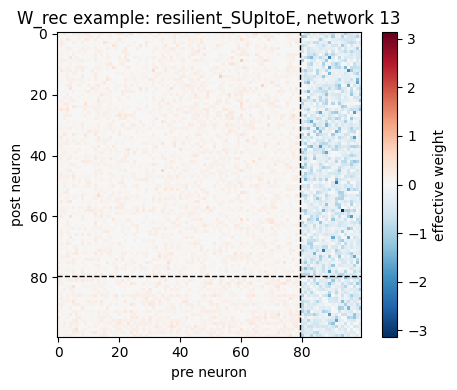

Saved:
/content/drive/MyDrive/ANN_analysis/images/w_example_resilient_SUpItoE_network13_2026JUN23_1845.png
/content/drive/MyDrive/ANN_analysis/images/w_example_resilient_SUpItoE_network13_2026JUN23_1845.svg
/content/drive/MyDrive/ANN_analysis/images/w_example_resilient_SUpItoE_network13_2026JUN23_1845.pdf


In [ ]:
#%%
saved_files = plot_W_rec_example(
    W_rec=W_rec,
    N_exc=N_exc,
    label=label,
    network_idx=network_idx,
    prefix="w_example",
)

In [ ]:
#new TUE JUN23


#%%
# ==========================================================
# 4. Analysis configuration
# ==========================================================

import pandas as pd
import networkx as nx
from scipy.stats import mannwhitneyu, kruskal

# ----------------------------------------------------------
# Conditions
# ----------------------------------------------------------

CONDITION_ORDER = [
    "naive",
    "resilient_SUprI",
    "resilient_SUpItoE",
]

CONDITION_COLORS = {
    "naive": "#0072B2",
    "resilient_SUprI": "#E69F00",
    "resilient_SUpItoE": "#009E73",
}

# ----------------------------------------------------------
# Network settings
# ----------------------------------------------------------

N_NETWORKS_PER_CONDITION = 200 #each with 100 nodes, 9900 possible edges for None

# Main threshold used for graph construction:
# q = 0.80 means retaining approximately the strongest 20% of |W_ij|.
MAIN_THRESHOLD = 0.50

# Thresholds used for sensitivity analyses.
# None = all non-zero off-diagonal weights retained
ROBUSTNESS_THRESHOLDS = (
    None,
    0.30,
    0.50,
    0.70,
    0.80,
    0.90,
)

BLOCKS_ALL = [
    "E->E",
    "E->I",
    "I->E",
    "I->I",
]

EPS = 1e-12

print("Analysis configuration loaded.")

Analysis configuration loaded.


In [ ]:
#%%
# ==========================================================
# 5. Utility functions: timestamps, saving, statistics
# ==========================================================

def timestamp_now():
    return datetime.now().strftime("%Y%b%d_%H%M").upper()


def savefig(name, dpi=300):
    """
    Save current matplotlib figure as png, svg, and pdf.
    Files are written to IMAGES_DIR.
    """
    ts = timestamp_now()

    for ext in ["png", "svg", "pdf"]:
        path = IMAGES_DIR / f"{name}_{ts}.{ext}"
        plt.savefig(path, dpi=dpi, bbox_inches="tight")

    print(f"Saved figure: {name}_{ts}")


def p_to_stars(p):
    if pd.isna(p):
        return "NA"
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"


def sem(x):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]

    if len(x) <= 1:
        return np.nan

    return np.std(x, ddof=1) / np.sqrt(len(x))


def add_sig_bar(ax, x1, x2, y, h, text):
    ax.plot(
        [x1, x1, x2, x2],
        [y, y + h, y + h, y],
        color="black",
        lw=1.2,
    )

    ax.text(
        (x1 + x2) / 2,
        y + h,
        text,
        ha="center",
        va="bottom",
        fontsize=10,
    )


print("Utility functions loaded.")

Utility functions loaded.


In [ ]:
#%%
# ==========================================================
# 5. Utility functions: timestamps, saving, statistics
# ==========================================================

def timestamp_now():
    return datetime.now().strftime("%Y%b%d_%H%M").upper()


def savefig(name, dpi=300):
    """
    Save current matplotlib figure as png, svg, and pdf.
    Files are written to IMAGES_DIR.
    """
    ts = timestamp_now()

    for ext in ["png", "svg", "pdf"]:
        path = IMAGES_DIR / f"{name}_{ts}.{ext}"
        plt.savefig(path, dpi=dpi, bbox_inches="tight")

    print(f"Saved figure: {name}_{ts}")


def p_to_stars(p):
    if pd.isna(p):
        return "NA"
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"


def sem(x):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]

    if len(x) <= 1:
        return np.nan

    return np.std(x, ddof=1) / np.sqrt(len(x))


def add_sig_bar(ax, x1, x2, y, h, text):
    ax.plot(
        [x1, x1, x2, x2],
        [y, y + h, y + h, y],
        color="black",
        lw=1.2,
    )

    ax.text(
        (x1 + x2) / 2,
        y + h,
        text,
        ha="center",
        va="bottom",
        fontsize=10,
    )


print("Utility functions loaded.")

Utility functions loaded.


In [ ]:
#%%
# ==========================================================
# 7. Load all networks
# ==========================================================

loaded_networks = {}

for label in CONDITION_ORDER:
    W_rec_list = []

    folder = NETWORK_SETS[label]

    print(f"Loading {label} from {folder}")

    for network_idx in range(N_NETWORKS_PER_CONDITION):
        W_rec, N_exc = load_W_rec(
            label=label,
            folder=folder,
            network_idx=network_idx,
        )

        W_rec_list.append(W_rec)

    loaded_networks[label] = {
        "W_rec_list": W_rec_list,
        "N_exc": int(N_exc),
        "N": int(W_rec_list[0].shape[0]),
    }

print("\nLoaded networks:")
for label, data in loaded_networks.items():
    print(
        label,
        "n_networks =", len(data["W_rec_list"]),
        "W_shape =", data["W_rec_list"][0].shape,
        "N_exc =", data["N_exc"],
        "N_inh =", data["N"] - data["N_exc"],
    )

Loading naive from /content/drive/MyDrive/networks/naive
Loading resilient_SUprI from /content/drive/MyDrive/networks/resilient_SUprI
Loading resilient_SUpItoE from /content/drive/MyDrive/networks/resilient_SUpItoE

Loaded networks:
naive n_networks = 200 W_shape = (100, 100) N_exc = 80 N_inh = 20
resilient_SUprI n_networks = 200 W_shape = (100, 100) N_exc = 80 N_inh = 20
resilient_SUpItoE n_networks = 200 W_shape = (100, 100) N_exc = 80 N_inh = 20


In [ ]:
#%%
# ==========================================================
# 8. Sanity checks
# ==========================================================

for label, data in loaded_networks.items():
    N = data["N"]
    N_exc = data["N_exc"]
    N_inh = N - N_exc

    assert N == 100, f"{label}: expected N=100, got N={N}"
    assert N_exc == 80, f"{label}: expected N_exc=80, got N_exc={N_exc}"
    assert N_inh == 20, f"{label}: expected N_inh=20, got N_inh={N_inh}"

    W0 = data["W_rec_list"][0]

    assert W0.shape == (N, N), f"{label}: W_rec shape mismatch"
    assert np.all(np.isfinite(W0)), f"{label}: non-finite values in W_rec"

print("All sanity checks passed.")
print("Convention: W_rec[post, pre], graph edge = pre -> post.")

All sanity checks passed.
Convention: W_rec[post, pre], graph edge = pre -> post.


Saved figure: Wrec_example_2026JUN23_1845


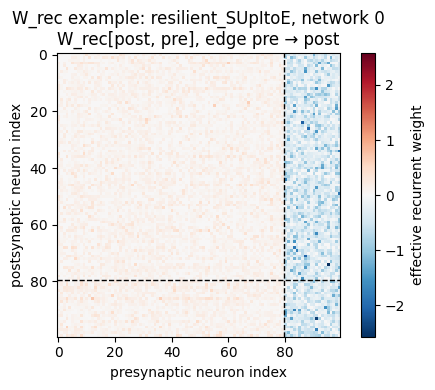

In [ ]:
#%%
# ==========================================================
# 9. Example W_rec plot
# ==========================================================

example_label = "resilient_SUpItoE"
example_idx = 0

W_example = loaded_networks[example_label]["W_rec_list"][example_idx]
N_exc_example = loaded_networks[example_label]["N_exc"]

vmax = np.max(np.abs(W_example))
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

fig, ax = plt.subplots(figsize=(5, 4))

im = ax.imshow(
    W_example,
    cmap="RdBu_r",
    norm=norm,
    interpolation="nearest",
)

ax.axvline(N_exc_example - 0.5, color="black", linestyle="--", lw=1)
ax.axhline(N_exc_example - 0.5, color="black", linestyle="--", lw=1)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("effective recurrent weight")

ax.set_xlabel("presynaptic neuron index")
ax.set_ylabel("postsynaptic neuron index")
ax.set_title(
    f"W_rec example: {example_label}, network {example_idx}\n"
    "W_rec[post, pre], edge pre → post"
)

plt.tight_layout()
savefig("Wrec_example")
plt.show()

In [ ]:
#%%
# ==========================================================
# 10. E/I balance per neuron
# ==========================================================

def compute_ei_inputs(W_rec, N_exc):
    """
    Compute excitatory and inhibitory input onto each postsynaptic neuron.

    W_rec[post, pre]
    rows = postsynaptic neurons
    cols = presynaptic neurons
    """
    W_rec = np.asarray(W_rec, dtype=float)
    N = W_rec.shape[0]

    exc = slice(0, N_exc)
    inh = slice(N_exc, N)

    E_input = np.sum(W_rec[:, exc], axis=1)
    I_input = np.sum(W_rec[:, inh], axis=1)

    return E_input, I_input


def compute_ei_balance_ratio(W_rec, N_exc, eps=EPS):
    E_input, I_input = compute_ei_inputs(W_rec, N_exc)

    ratio = np.abs(E_input) / (np.abs(I_input) + eps)
    log10_ratio = np.log10(ratio + eps)

    return E_input, I_input, ratio, log10_ratio


ei_rows = []

for label, data in loaded_networks.items():
    N_exc = data["N_exc"]

    for network_idx, W_rec in enumerate(data["W_rec_list"]):
        E_input, I_input, EI_ratio, log10_EI_ratio = compute_ei_balance_ratio(
            W_rec,
            N_exc,
        )

        for neuron_idx in range(W_rec.shape[0]):
            neuron_type = "E" if neuron_idx < N_exc else "I"

            ei_rows.append({
                "condition": label,
                "network_idx": network_idx,
                "neuron_idx": neuron_idx,
                "neuron_type": neuron_type,
                "E_input": float(E_input[neuron_idx]),
                "I_input": float(I_input[neuron_idx]),
                "abs_E_input": float(abs(E_input[neuron_idx])),
                "abs_I_input": float(abs(I_input[neuron_idx])),
                "EI_ratio": float(EI_ratio[neuron_idx]),
                "log10_EI_ratio": float(log10_EI_ratio[neuron_idx]),
            })

ei_balance_df = pd.DataFrame(ei_rows)

outpath = RESULTS_DIR / f"ei_balance_per_neuron_{timestamp_now()}.csv"
ei_balance_df.to_csv(outpath, index=False)

print("Saved:", outpath)
display(ei_balance_df.head())
print(ei_balance_df.shape)

Saved: /content/drive/MyDrive/ANN_analysis/results/ei_balance_per_neuron_2026JUN23_1846.csv


,condition,network_idx,neuron_idx,neuron_type,E_input,I_input,abs_E_input,abs_I_input,EI_ratio,log10_EI_ratio
0,naive,0,0,E,7.136389,-8.464568,7.136389,8.464568,0.843090,-0.074126
1,naive,0,1,E,8.375448,-7.943912,8.375448,7.943912,1.054323,0.022974
2,naive,0,2,E,6.701007,-8.894259,6.701007,8.894259,0.753408,-0.122970
3,naive,0,3,E,7.808160,-7.711320,7.808160,7.711320,1.012558,0.005420
4,naive,0,4,E,6.507070,-9.479329,6.507070,9.479329,0.686448,-0.163392


(60000, 10)


In [ ]:
#%%
# ==========================================================
# 10b. E/I balance: per-network summary
# ==========================================================

ei_summary_rows = []

for condition in CONDITION_ORDER:
    sub = ei_balance_df[ei_balance_df["condition"] == condition]

    for network_idx, net_df in sub.groupby("network_idx"):
        for neuron_type in ["E", "I"]:
            ndf = net_df[net_df["neuron_type"] == neuron_type]

            ei_summary_rows.append({
                "condition": condition,
                "network_idx": network_idx,
                "neuron_type": neuron_type,

                "mean_abs_E_input": ndf["abs_E_input"].mean(),
                "mean_abs_I_input": ndf["abs_I_input"].mean(),
                "mean_EI_ratio": ndf["EI_ratio"].mean(),
                "mean_log10_EI_ratio": ndf["log10_EI_ratio"].mean(),

                "std_abs_E_input": ndf["abs_E_input"].std(),
                "std_abs_I_input": ndf["abs_I_input"].std(),
                "std_log10_EI_ratio": ndf["log10_EI_ratio"].std(),
            })

ei_summary_df = pd.DataFrame(ei_summary_rows)

outpath = RESULTS_DIR / f"ei_balance_summary_per_network_{timestamp_now()}.csv"
ei_summary_df.to_csv(outpath, index=False)

print("Saved:", outpath)
display(ei_summary_df.head())

Saved: /content/drive/MyDrive/ANN_analysis/results/ei_balance_summary_per_network_2026JUN23_1847.csv


,condition,network_idx,neuron_type,mean_abs_E_input,mean_abs_I_input,mean_EI_ratio,mean_log10_EI_ratio,std_abs_E_input,std_abs_I_input,std_log10_EI_ratio
0,naive,0,E,7.194925,8.398348,0.890741,-0.066015,1.203538,1.477416,0.113180
1,naive,0,I,8.325983,8.010736,1.074329,0.017376,1.322278,1.401639,0.115445
2,naive,1,E,5.482611,6.326541,0.912089,-0.059584,1.012964,1.289259,0.129107
3,naive,1,I,6.755314,6.339471,1.086648,0.023217,1.359031,0.944439,0.110810
4,naive,2,E,8.357136,9.325499,0.912048,-0.048596,1.200015,1.158805,0.087208


Saved figure: ei_balance_summary_E_targets_2026JUN23_1848


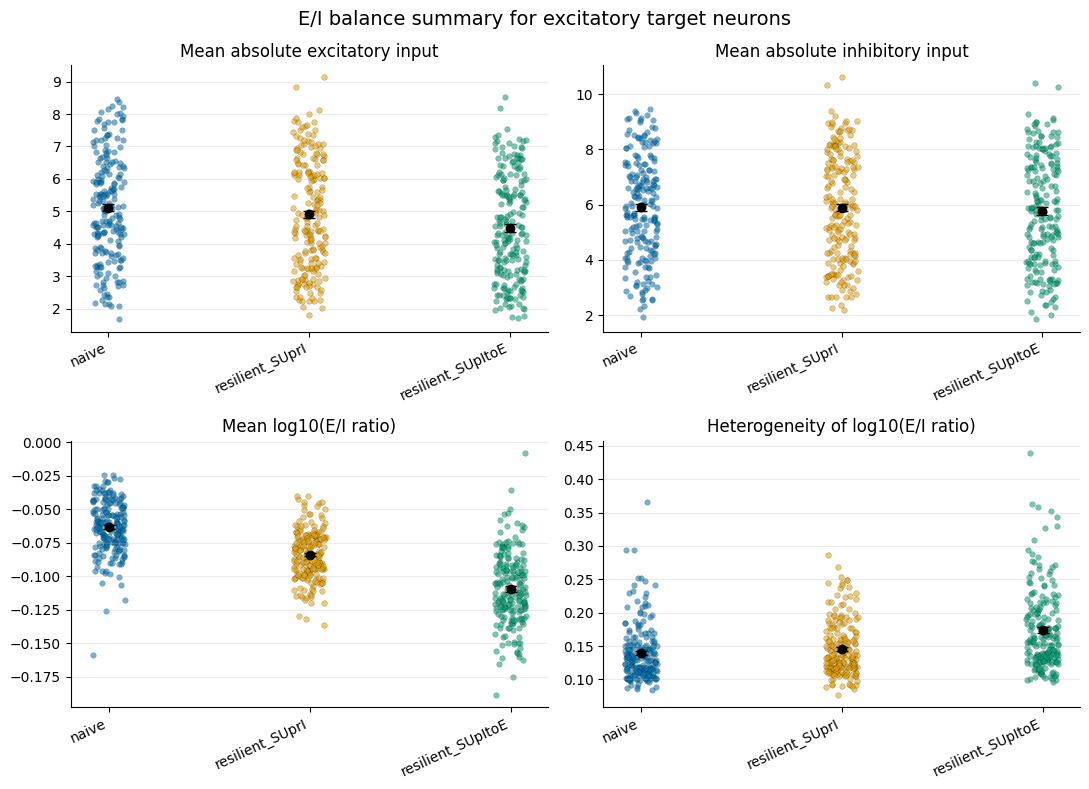

In [ ]:
#%%
# ==========================================================
# 10c. Plot E/I balance summary per network
# ==========================================================

plot_specs = [
    ("mean_abs_E_input", "Mean absolute excitatory input"),
    ("mean_abs_I_input", "Mean absolute inhibitory input"),
    ("mean_log10_EI_ratio", "Mean log10(E/I ratio)"),
    ("std_log10_EI_ratio", "Heterogeneity of log10(E/I ratio)"),
]

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes = axes.ravel()

rng = np.random.default_rng(10)

for ax, (metric, title) in zip(axes, plot_specs):

    for x, condition in enumerate(CONDITION_ORDER, start=1):
        vals = ei_summary_df[
            (ei_summary_df["condition"] == condition)
            & (ei_summary_df["neuron_type"] == "E")
        ][metric].dropna().values

        jitter = rng.uniform(-0.08, 0.08, len(vals))

        ax.scatter(
            np.full(len(vals), x) + jitter,
            vals,
            s=16,
            alpha=0.55,
            color=CONDITION_COLORS[condition],
            edgecolor="black",
            linewidth=0.2,
        )

        ax.errorbar(
            x,
            np.nanmean(vals),
            yerr=sem(vals),
            fmt="o",
            color="black",
            capsize=4,
            zorder=5,
        )

    ax.set_title(title)
    ax.set_xticks(range(1, len(CONDITION_ORDER) + 1))
    ax.set_xticklabels(CONDITION_ORDER, rotation=25, ha="right")
    ax.grid(axis="y", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle(
    "E/I balance summary for excitatory target neurons",
    fontsize=14,
)

plt.tight_layout()
savefig("ei_balance_summary_E_targets")
plt.show()

In [ ]:
#%%
from pathlib import Path
from datetime import datetime
import matplotlib.pyplot as plt


# ==========================================================
# Project folders
# ==========================================================

PROJECT_NAME = "NWAnaRNN_2026JUN"

PROJECT = Path(
    f"/content/drive/MyDrive/{PROJECT_NAME}"
)

IMAGES = PROJECT / "images"
RESULTS = PROJECT / "results"
TABLES = PROJECT / "tables"

for folder in [PROJECT, IMAGES, RESULTS, TABLES]:
    folder.mkdir(
        parents=True,
        exist_ok=True
    )

print("Project folder:")
print(PROJECT)


# ==========================================================
# Utility for saving plots
# ==========================================================

def savefig(name, dpi=300):
    """
    Save current matplotlib figure to

    MyDrive/NWAnaRNN_2026JUN/images/

    as

    name_YYYYMONDD_HHMM.png
    name_YYYYMONDD_HHMM.svg
    name_YYYYMONDD_HHMM.pdf
    """

    timestamp = datetime.now().strftime(
        "%Y%b%d_%H%M"
    ).upper()

    for ext in ["png", "svg", "pdf"]:

        filename = (
            IMAGES /
            f"{name}_{timestamp}.{ext}"
        )

        plt.savefig(
            filename,
            dpi=dpi,
            bbox_inches="tight"
        )

    print(f"Saved: {name}_{timestamp}")

Project folder:
/content/drive/MyDrive/NWAnaRNN_2026JUN


Saved: threshold_check_example_2026JUN22_1221


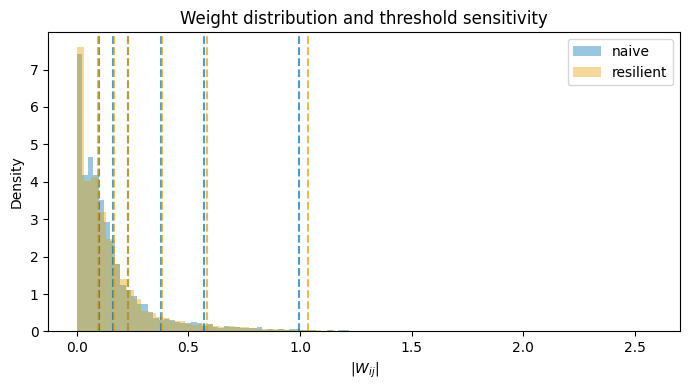

In [ ]:
#%%
# ==========================================================
# Threshold sensitivity
# Naive vs resilient_SUpItoE
# ==========================================================

thresholds = (
    0.50,
    0.70,
    0.80,
    0.90,
    0.95,
    0.99
)


colors = {
    "naive":"#0072B2",
    "resilient_SUpItoE":"#E69F00"
}


# ----------------------------------------------------------
# load examples
# ----------------------------------------------------------

W_naive,N_exc = load_W_rec(
        label="naive",
        folder=NETWORK_SETS["naive"],
        network_idx=0
)


W_res,N_exc = load_W_rec(
        label="resilient_SUpItoE",
        folder=NETWORK_SETS["resilient_SUpItoE"],
        network_idx=0
)


# remove diagonal
mask = ~np.eye(W_naive.shape[0],dtype=bool)

w_naive = np.abs(W_naive[mask])
w_res = np.abs(W_res[mask])



# ----------------------------------------------------------
# plot
# ----------------------------------------------------------

fig,ax = plt.subplots(
        figsize=(7,4)
)


ax.hist(

        w_naive,

        bins=80,

        density=True,

        alpha=.4,

        color=colors["naive"],

        label="naive"

)


ax.hist(

        w_res,

        bins=80,

        density=True,

        alpha=.4,

        color=colors["resilient_SUpItoE"],

        label="resilient"

)



# threshold lines

for q in thresholds:

    t_n = np.quantile(
            w_naive,
            q
    )

    t_r = np.quantile(
            w_res,
            q
    )


    ax.axvline(

            t_n,

            color=colors["naive"],

            ls='--',

            alpha=.7

    )


    ax.axvline(

            t_r,

            color=colors["resilient_SUpItoE"],

            ls='--',

            alpha=.7

    )



ax.set_xlabel(r"$|W_{ij}|$")

ax.set_ylabel("Density")

ax.set_title(

    "Weight distribution and threshold sensitivity"

)

ax.legend()

plt.tight_layout()

savefig(
    "threshold_check_example"
)

plt.show()

The overall distribution of recurrent weight magnitudes is highly similar between naive and resilient networks, suggesting that resilience training does not substantially alter the global connectivity budget. However, resilient networks exhibit a subtle rightward shift at higher quantiles, indicating a tendency toward retaining a small subset of stronger synaptic interactions. This motivates subsequent threshold sensitivity analyses to determine whether graph-theoretical conclusions depend on the choice of edge threshold.


Saved: threshold_sensitivity_2026JUN22_1224


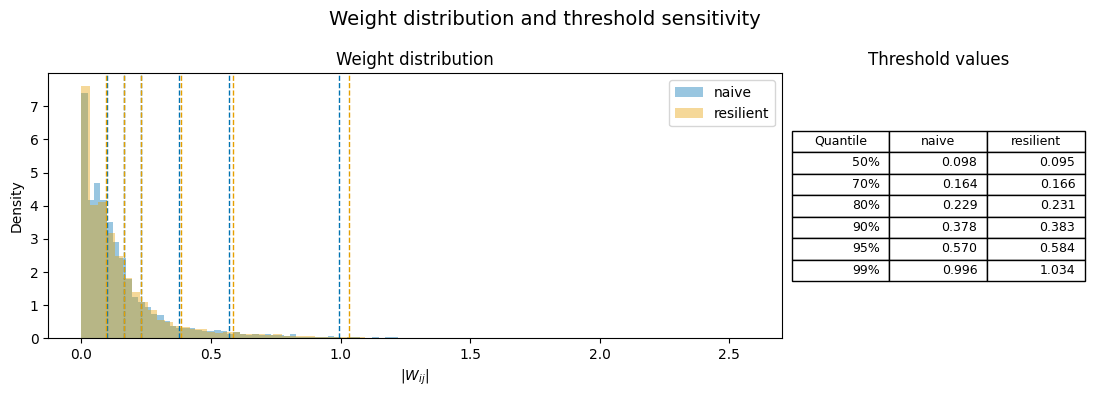

In [ ]:
#%%
thresholds = (
    0.50,
    0.70,
    0.80,
    0.90,
    0.95,
    0.99
)

colors = {
    "naive":"#0072B2",
    "resilient":"#E69F00"
}


# ---------------------------------------------------------
# Example networks
# ---------------------------------------------------------

W_naive,_ = load_W_rec(
        label="naive",
        folder=NETWORK_SETS["naive"],
        network_idx=0
)

W_res,_ = load_W_rec(
        label="resilient_SUpItoE",
        folder=NETWORK_SETS["resilient_SUpItoE"],
        network_idx=0
)


mask = ~np.eye(W_naive.shape[0],dtype=bool)

w_naive = np.abs(W_naive[mask])
w_res = np.abs(W_res[mask])


# ---------------------------------------------------------
# threshold dataframe
# ---------------------------------------------------------

rows=[]

for q in thresholds:

    tn = np.quantile(w_naive,q)
    tr = np.quantile(w_res,q)

    rows.append(

        [

            f"{int(q*100)}%",

            f"{tn:.3f}",

            f"{tr:.3f}"

        ]

    )


# ---------------------------------------------------------
# plot
# ---------------------------------------------------------

fig,axes = plt.subplots(

        1,
        2,

        figsize=(11,4),

        gridspec_kw={"width_ratios":[3,1]}
)



ax=axes[0]

ax.hist(

        w_naive,

        bins=80,

        density=True,

        alpha=.4,

        color=colors["naive"],

        label="naive"

)


ax.hist(

        w_res,

        bins=80,

        density=True,

        alpha=.4,

        color=colors["resilient"],

        label="resilient"

)



for q in thresholds:

    tn=np.quantile(w_naive,q)
    tr=np.quantile(w_res,q)


    ax.axvline(

        tn,

        color=colors["naive"],

        ls='--',

        lw=1
    )

    ax.axvline(

        tr,

        color=colors["resilient"],

        ls='--',

        lw=1
    )



ax.set_xlabel(r"$|W_{ij}|$")

ax.set_ylabel("Density")

ax.set_title(

    "Weight distribution"

)

ax.legend()



# ---------------------------------------------------------
# table
# ---------------------------------------------------------

ax2=axes[1]

ax2.axis('off')


table=ax2.table(

        cellText=rows,

        colLabels=[

            "Quantile",

            "naive",

            "resilient"

        ],

        loc='center'

)


table.auto_set_font_size(False)

table.set_fontsize(9)

table.scale(1.2,1.5)



ax2.set_title(

    "Threshold values"

)


plt.suptitle(

    "Weight distribution and threshold sensitivity",

    fontsize=14

)

plt.tight_layout()


savefig(

    "threshold_sensitivity"

)

plt.show()


Threshold selection

To construct directed graph representations from the recurrent weight matrices, a quantile-based thresholding approach was employed. Thresholds were determined from the empirical distribution of absolute recurrent weights ($|W_{ij}|$) (Figure X).

The main analysis was performed using a threshold corresponding to the 80th percentile of the weight distribution, thereby retaining the strongest 20% of recurrent connections. This threshold was selected because it removes a large fraction of very weak, near-zero connections while preserving a sufficiently dense graph for robust estimation of graph-theoretical measures. Importantly, naive and resilient networks exhibited highly comparable threshold values at this quantile (Figure X), minimizing potential biases introduced by condition-specific thresholding. Furthermore, the 80th percentile represents a compromise between preserving meaningful connectivity patterns and avoiding overly sparse graphs, which can occur at more stringent thresholds such as the 95th or 99th percentile.

To assess the robustness of network-level conclusions, additional analyses were performed across several thresholds. Specifically, robustness checks considered the 50th, 70th, 90th, and 95th percentiles, corresponding to retaining approximately 50%, 30%, 10%, and 5% of the strongest recurrent connections, respectively. This sensitivity analysis ensures that observed structural differences between naive and resilient networks are not driven by an arbitrary threshold choice.

Figure caption

Figure X. Distribution of recurrent weight magnitudes and threshold selection. Distribution of absolute recurrent weights ($|W_{ij}|$) for representative naive and resilient networks. Dashed lines indicate quantile-based thresholds used for graph construction. The main analysis employed the 80th percentile (top 20% strongest connections), while supplementary robustness analyses additionally considered thresholds at the 50th, 70th, 90th, and 95th percentiles. The table summarizes the corresponding threshold values for both network classes.

\subsection{Threshold Selection and Sensitivity Analysis}

To construct directed graph representations from the recurrent weight matrices, a quantile-based thresholding approach was employed. Thresholds were determined from the empirical distribution of absolute recurrent weights, $|W_{ij}|$ (Figure~\ref{fig:threshold_sensitivity}).

The primary analyses were performed using the \textbf{80th percentile} of the weight distribution, thereby retaining the \textbf{strongest 20\% of recurrent connections}. This threshold was selected for several reasons. First, it removes a substantial fraction of very weak, near-zero connections that are unlikely to contribute meaningfully to network organization. Second, it preserves a sufficiently dense graph for stable estimation of graph-theoretical measures. Third, naive and resilient networks exhibit highly similar threshold values at this quantile, minimizing biases arising from condition-specific thresholding. Finally, the 80th percentile represents a compromise between preserving biologically relevant connectivity patterns and avoiding excessively sparse graphs, which may occur when applying more stringent thresholds such as the 95th or 99th percentile.

To evaluate the robustness of network-level conclusions, additional analyses were performed across multiple thresholds. Specifically, robustness analyses considered the \textbf{50th, 70th, 90th, and 95th percentiles}, corresponding to retaining approximately \textbf{50\%, 30\%, 10\%, and 5\%} of the strongest recurrent connections, respectively. These sensitivity analyses ensure that observed differences in network organization between naive and resilient networks are not driven by an arbitrary threshold choice.

Figure~\ref{fig:threshold_sensitivity} illustrates representative weight distributions for naive and resilient networks together with the quantile-based thresholds used throughout the study. Based on this analysis, the 80th percentile was chosen as the primary threshold for graph construction, while the remaining thresholds were used to assess the robustness of all graph-theoretical findings.

In [ ]:
#-----

---


# Network analysis pipeline: naive vs resilient_SUpItoE

Colab-ready pipeline for recurrent ANN `W_rec`.

Thresholds requested by PI:
- `None`: all non-zero off-diagonal edges
- `0.30`: strongest 70%
- `0.70`: strongest 30%
- `0.80`: strongest 20% main threshold
- `0.90`: strongest 10%

Main focus:
- density, sparsity, redundancy
- I→E compared to E→E
- I→I because it is not directly touched by the stress
- directed and weighted directed network metrics for all thresholds
- spectral metrics

In [ ]:
# ==========================================================
# 00 Colab setup, output folders, and plot saving
# ==========================================================

from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
from datetime import datetime
import json
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from scipy.stats import mannwhitneyu
from matplotlib.colors import TwoSlopeNorm

warnings.filterwarnings("ignore")

PROJECT_NAME = "NWAnaRNN_2026JUN"

PROJECT = Path(f"/content/drive/MyDrive/{PROJECT_NAME}")
IMAGES = PROJECT / "images"
RESULTS = PROJECT / "results"
TABLES = PROJECT / "tables"

for folder in [PROJECT, IMAGES, RESULTS, TABLES]:
    folder.mkdir(parents=True, exist_ok=True)

NETWORK_ROOT = Path("/content/drive/MyDrive/networks")

NETWORK_SETS = {
    "naive": NETWORK_ROOT / "naive",
    "resilient_SUpItoE": NETWORK_ROOT / "resilient_SUpItoE",
}

COLORS = {
    "naive": "#0072B2",
    "resilient": "#E69F00",
}

def make_timestamp():
    return datetime.now().strftime("%Y%b%d_%H%M").upper()

RUN_TIMESTAMP = make_timestamp()

def savefig(name, dpi=300):
    for ext in ["png", "svg", "pdf"]:
        plt.savefig(
            IMAGES / f"{name}_{RUN_TIMESTAMP}.{ext}",
            dpi=dpi,
            bbox_inches="tight",
        )
    print(f"Saved figure: {name}_{RUN_TIMESTAMP}")

print("Project folder:", PROJECT)
print("Network root:", NETWORK_ROOT)
for key, folder in NETWORK_SETS.items():
    print(key, folder.exists(), folder)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project folder: /content/drive/MyDrive/NWAnaRNN_2026JUN
Network root: /content/drive/MyDrive/networks
naive True /content/drive/MyDrive/networks/naive
resilient_SUpItoE True /content/drive/MyDrive/networks/resilient_SUpItoE


In [ ]:
# ==========================================================
# 01 Self-contained network loader
# ==========================================================

def load_checkpoint_simple(filepath):
    data = np.load(filepath, allow_pickle=False)

    params = {
        k[len("param__"):]: np.array(data[k])
        for k in data.files
        if k.startswith("param__")
    }

    D = np.array(data["D"])
    out_mask = np.array(data["out_mask"])
    connectivity_mask = np.array(data["connectivity_mask"])

    meta = json.loads(bytes(data["_meta"]).decode("utf-8"))
    config = meta["config"]
    step = meta.get("step", None)

    return params, config, D, out_mask, connectivity_mask, step


def effective_W(params, masks, connectivity_mask):
    # Returns effective recurrent matrix W_rec.
    # Convention: W_rec[post, pre], so edge direction is pre -> post.
    # Dale: excitatory presynaptic columns are positive, inhibitory columns negative.
    D, _ = masks

    dale_sign = np.diag(np.array(D))
    w_rec = np.maximum(np.array(params["w_rec"]), 0.0)
    conn = np.array(connectivity_mask)

    W_rec = w_rec * dale_sign[None, :] * conn

    return W_rec


def load_W_rec(label, folder, network_idx):
    ckpt_path = os.path.join(str(folder), f"network_{network_idx}.npz")

    params, config, D, out_mask, connectivity_mask, step = load_checkpoint_simple(
        ckpt_path
    )

    W_rec = effective_W(
        params,
        (D, out_mask),
        connectivity_mask,
    )

    N_exc = int(config["N_exc"])

    return W_rec, N_exc

W_rec: (100, 100)
N_exc: 80
min/max: -2.5737336 0.69352996
Saved figure: 00_Wrec_example_2026JUN22_1358


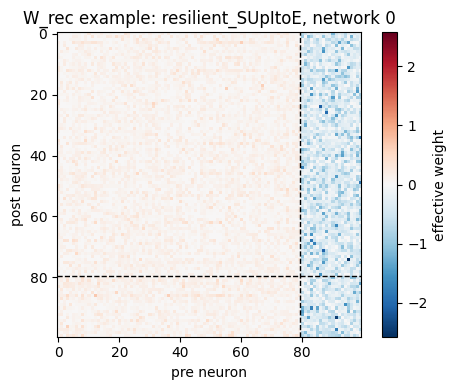

In [ ]:
# ==========================================================
# 02 Test load and plot one W_rec example
# ==========================================================

label = "resilient_SUpItoE"
network_idx = 0

W_rec, N_exc = load_W_rec(
    label=label,
    folder=NETWORK_SETS[label],
    network_idx=network_idx,
)

print("W_rec:", W_rec.shape)
print("N_exc:", N_exc)
print("min/max:", np.min(W_rec), np.max(W_rec))

fig, ax = plt.subplots(figsize=(5, 4))

vmax = float(np.max(np.abs(W_rec)))
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

im = ax.imshow(W_rec, cmap="RdBu_r", norm=norm, interpolation="nearest")
ax.axvline(N_exc - 0.5, color="k", linestyle="--", linewidth=1)
ax.axhline(N_exc - 0.5, color="k", linestyle="--", linewidth=1)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("effective weight")

ax.set_xlabel("pre neuron")
ax.set_ylabel("post neuron")
ax.set_title(f"W_rec example: {label}, network {network_idx}")

plt.tight_layout()
savefig("00_Wrec_example")
plt.show()

In [ ]:
# ==========================================================
# 03 Threshold definitions requested by PI
# ==========================================================

MAIN_THRESHOLD = 0.80

ROBUSTNESS_THRESHOLDS = (
    None,   # all non-zero off-diagonal edges
    0.30,   # strongest 70%
    0.70,   # strongest 30%
    0.80,   # strongest 20%; main threshold
    0.90,   # strongest 10%
)

THRESHOLD_LABELS = {
    None: "None",
    0.30: "q=0.30 / top 70%",
    0.70: "q=0.70 / top 30%",
    0.80: "q=0.80 / top 20%",
    0.90: "q=0.90 / top 10%",
}

def threshold_suffix(q):
    if q is None:
        return "thNone"
    return f"th{int(round(q * 10)):02d}"

for q in ROBUSTNESS_THRESHOLDS:
    print(q, THRESHOLD_LABELS[q], threshold_suffix(q))

None None thNone
0.3 q=0.30 / top 70% th03
0.7 q=0.70 / top 30% th07
0.8 q=0.80 / top 20% th08
0.9 q=0.90 / top 10% th09


Saved figure: 01_threshold_selection_2026JUN22_1358


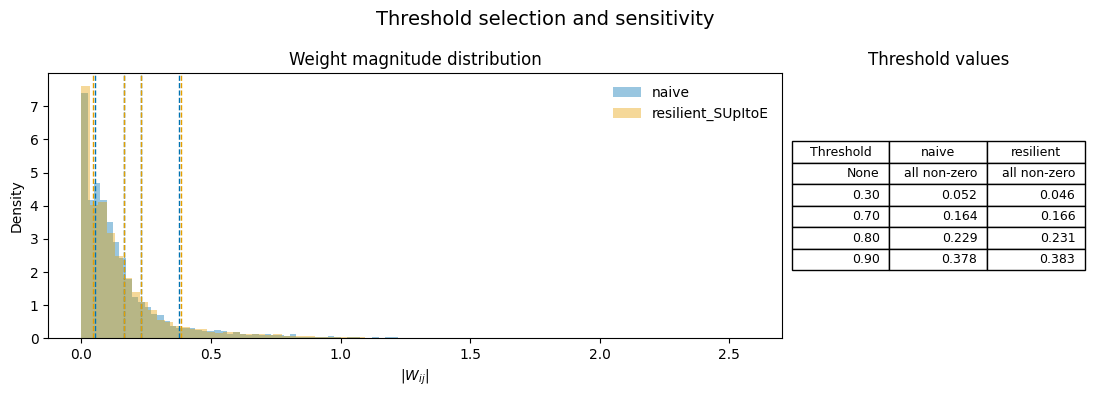

In [ ]:
# ==========================================================
# 04 Threshold selection plot with table
# ==========================================================

thresholds_for_plot = tuple(q for q in ROBUSTNESS_THRESHOLDS if q is not None)

W_naive, _ = load_W_rec(
    label="naive",
    folder=NETWORK_SETS["naive"],
    network_idx=0,
)

W_res, _ = load_W_rec(
    label="resilient_SUpItoE",
    folder=NETWORK_SETS["resilient_SUpItoE"],
    network_idx=0,
)

mask = ~np.eye(W_naive.shape[0], dtype=bool)

w_naive = np.abs(W_naive[mask])
w_res = np.abs(W_res[mask])

rows = []
rows.append(["None", "all non-zero", "all non-zero"])

for q in thresholds_for_plot:
    tn = np.quantile(w_naive, q)
    tr = np.quantile(w_res, q)

    rows.append([
        f"{q:.2f}",
        f"{tn:.3f}",
        f"{tr:.3f}",
    ])

fig, axes = plt.subplots(
    1,
    2,
    figsize=(11, 4),
    gridspec_kw={"width_ratios": [3, 1]},
)

ax = axes[0]

ax.hist(
    w_naive,
    bins=80,
    density=True,
    alpha=0.4,
    color=COLORS["naive"],
    label="naive",
)

ax.hist(
    w_res,
    bins=80,
    density=True,
    alpha=0.4,
    color=COLORS["resilient"],
    label="resilient_SUpItoE",
)

for q in thresholds_for_plot:
    tn = np.quantile(w_naive, q)
    tr = np.quantile(w_res, q)

    ax.axvline(tn, color=COLORS["naive"], ls="--", lw=1)
    ax.axvline(tr, color=COLORS["resilient"], ls="--", lw=1)

ax.set_xlabel(r"$|W_{ij}|$")
ax.set_ylabel("Density")
ax.set_title("Weight magnitude distribution")
ax.legend(frameon=False)

ax2 = axes[1]
ax2.axis("off")

table = ax2.table(
    cellText=rows,
    colLabels=["Threshold", "naive", "resilient"],
    loc="center",
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.5)

ax2.set_title("Threshold values")

plt.suptitle("Threshold selection and sensitivity", fontsize=14)
plt.tight_layout()
savefig("01_threshold_selection")
plt.show()

In [ ]:
# ==========================================================
# 05 Load all networks: 200 naive and 200 resilient_SUpItoE
# ==========================================================

N_NETWORKS = 200

CONDITIONS = {
    "naive": "naive",
    "resilient": "resilient_SUpItoE",
}

all_networks = {}

for short_label, folder_label in CONDITIONS.items():
    W_list = []

    print("Loading", short_label)

    for idx in range(N_NETWORKS):
        W, N_exc = load_W_rec(
            label=folder_label,
            folder=NETWORK_SETS[folder_label],
            network_idx=idx,
        )
        W_list.append(np.asarray(W, dtype=float))

    all_networks[short_label] = {
        "W": W_list,
        "N_exc": int(N_exc),
        "N": W_list[0].shape[0],
    }

print("Loaded networks:")
for label, data in all_networks.items():
    print(label, len(data["W"]), data["W"][0].shape, "N_exc =", data["N_exc"])

Loading naive
Loading resilient
Loaded networks:
naive 200 (100, 100) N_exc = 80
resilient 200 (100, 100) N_exc = 80


In [ ]:
# ==========================================================
# 06 Helper functions
# ==========================================================

def sem(x):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    if len(x) < 2:
        return np.nan
    return np.std(x, ddof=1) / np.sqrt(len(x))


def p_to_stars(p):
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"


def add_sig_bar(ax, x1, x2, y, h, text):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.2, c="black")
    ax.text((x1+x2)/2, y+h, text, ha="center", va="bottom", fontsize=10)


def get_indices(N_exc, N):
    exc = np.arange(0, N_exc)
    inh = np.arange(N_exc, N)
    return exc, inh


def get_block(W, block, N_exc):
    exc, inh = get_indices(N_exc, W.shape[0])

    if block == "E->E":
        return W[np.ix_(exc, exc)]
    if block == "I->E":
        return W[np.ix_(exc, inh)]   # post E, pre I
    if block == "E->I":
        return W[np.ix_(inh, exc)]   # post I, pre E
    if block == "I->I":
        return W[np.ix_(inh, inh)]

    raise ValueError(f"Unknown block: {block}")


def threshold_adjacency(W, q):
    # Returns binary directed adjacency A.
    # W[post, pre]; A[post, pre] = 1 means edge pre -> post.
    # q=None keeps all non-zero off-diagonal weights.
    # q=0.80 keeps |W| above 80th percentile, i.e. strongest 20%.
    W = np.asarray(W, dtype=float)
    N = W.shape[0]

    offdiag = ~np.eye(N, dtype=bool)

    if q is None:
        A = (np.abs(W) > 0).astype(int)
        np.fill_diagonal(A, 0)
        return A, 0.0

    vals = np.abs(W[offdiag])
    thr = float(np.quantile(vals, q))

    A = (np.abs(W) > thr).astype(int)
    np.fill_diagonal(A, 0)

    return A, thr


def mean_pairwise_jaccard_rows(A_block):
    A_block = np.asarray(A_block).astype(bool)
    n_rows = A_block.shape[0]

    if n_rows < 2:
        return np.nan

    vals = []

    for i in range(n_rows):
        for j in range(i + 1, n_rows):
            inter = np.logical_and(A_block[i], A_block[j]).sum()
            union = np.logical_or(A_block[i], A_block[j]).sum()

            if union > 0:
                vals.append(inter / union)

    return float(np.mean(vals)) if len(vals) else np.nan


def build_digraph_from_A(A):
    # Converts A[post, pre] into NetworkX DiGraph edge pre -> post.
    G = nx.DiGraph()
    G.add_nodes_from(range(A.shape[0]))

    post_idx, pre_idx = np.where(A == 1)
    G.add_edges_from([(int(pre), int(post)) for post, pre in zip(post_idx, pre_idx)])

    return G


def build_weighted_digraph_from_W(W, q=None):
    # Builds weighted DiGraph from W[post, pre], edge pre -> post.
    A, thr = threshold_adjacency(W, q)

    G = nx.DiGraph()
    G.add_nodes_from(range(W.shape[0]))

    post_idx, pre_idx = np.where(A == 1)

    for post, pre in zip(post_idx, pre_idx):
        signed_w = float(W[post, pre])
        G.add_edge(
            int(pre),
            int(post),
            weight_abs=abs(signed_w),
            weight_signed=signed_w,
            sign=1 if signed_w > 0 else -1 if signed_w < 0 else 0,
        )

    return G, thr


def plot_two_group_metric(df, metric, title=None, ylabel=None, save_name=None):
    fig, ax = plt.subplots(figsize=(5, 4))
    rng = np.random.default_rng(42)

    samples = [
        df.loc[df["condition"] == cond, metric].dropna().values
        for cond in ["naive", "resilient"]
    ]

    for x, cond, vals in zip([1, 2], ["naive", "resilient"], samples):
        jitter = rng.uniform(-0.08, 0.08, len(vals))

        ax.scatter(
            np.full(len(vals), x) + jitter,
            vals,
            s=18,
            alpha=0.55,
            color=COLORS[cond],
            edgecolor="black",
            linewidth=0.2,
        )

        ax.errorbar(
            x,
            np.mean(vals),
            yerr=sem(vals),
            fmt="o",
            color="black",
            capsize=4,
            zorder=5,
        )

    _, p = mannwhitneyu(samples[0], samples[1], alternative="two-sided")

    y_max = max(np.max(samples[0]), np.max(samples[1]))
    y_min = min(np.min(samples[0]), np.min(samples[1]))
    yr = y_max - y_min if y_max > y_min else 1.0

    add_sig_bar(ax, 1, 2, y_max + 0.06 * yr, 0.02 * yr, p_to_stars(p))

    ax.set_xticks([1, 2])
    ax.set_xticklabels(["naive", "resilient"], rotation=15)
    ax.set_ylabel(ylabel if ylabel is not None else metric)
    ax.set_title(title if title is not None else metric)
    ax.grid(axis="y", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()

    if save_name is not None:
        savefig(save_name)

    plt.show()

In [ ]:
# ==========================================================
# 07 Weight QC across all networks
# ==========================================================

qc_rows = []

for condition, data in all_networks.items():
    for idx, W in enumerate(data["W"]):
        N = W.shape[0]
        offdiag = ~np.eye(N, dtype=bool)

        vals = W[offdiag]
        abs_vals = np.abs(vals)

        qc_rows.append({
            "condition": condition,
            "network_idx": idx,
            "mean_weight": np.mean(vals),
            "mean_abs_weight": np.mean(abs_vals),
            "median_abs_weight": np.median(abs_vals),
            "std_abs_weight": np.std(abs_vals),
            "p95_abs_weight": np.percentile(abs_vals, 95),
            "p99_abs_weight": np.percentile(abs_vals, 99),
            "fraction_near_zero_001": np.mean(abs_vals < 0.01),
            "fraction_positive": np.mean(vals > 0),
            "fraction_negative": np.mean(vals < 0),
            "fraction_zero": np.mean(abs_vals == 0),
        })

qc_df = pd.DataFrame(qc_rows)
qc_df.to_csv(RESULTS / f"weight_qc_{RUN_TIMESTAMP}.csv", index=False)
qc_df.head()

,condition,network_idx,mean_weight,mean_abs_weight,median_abs_weight,std_abs_weight,p95_abs_weight,p99_abs_weight,fraction_near_zero_001,fraction_positive,fraction_negative,fraction_zero
0,naive,0,-0.009088,0.159010,0.097895,0.200033,0.569794,0.995719,0.132929,0.691313,0.196667,0.112020
1,naive,1,-0.005980,0.121882,0.072406,0.160068,0.442515,0.775038,0.198283,0.637677,0.191010,0.171313
2,naive,2,-0.006988,0.178955,0.113884,0.219157,0.637877,1.087164,0.131010,0.687879,0.196667,0.115455
3,naive,3,-0.003317,0.097498,0.058358,0.130086,0.347363,0.636017,0.246465,0.592525,0.188889,0.218586
4,naive,4,0.000440,0.052309,0.023073,0.079886,0.209832,0.372209,0.412424,0.468788,0.164040,0.367172


Saved figure: 02_weight_qc_2026JUN22_1358


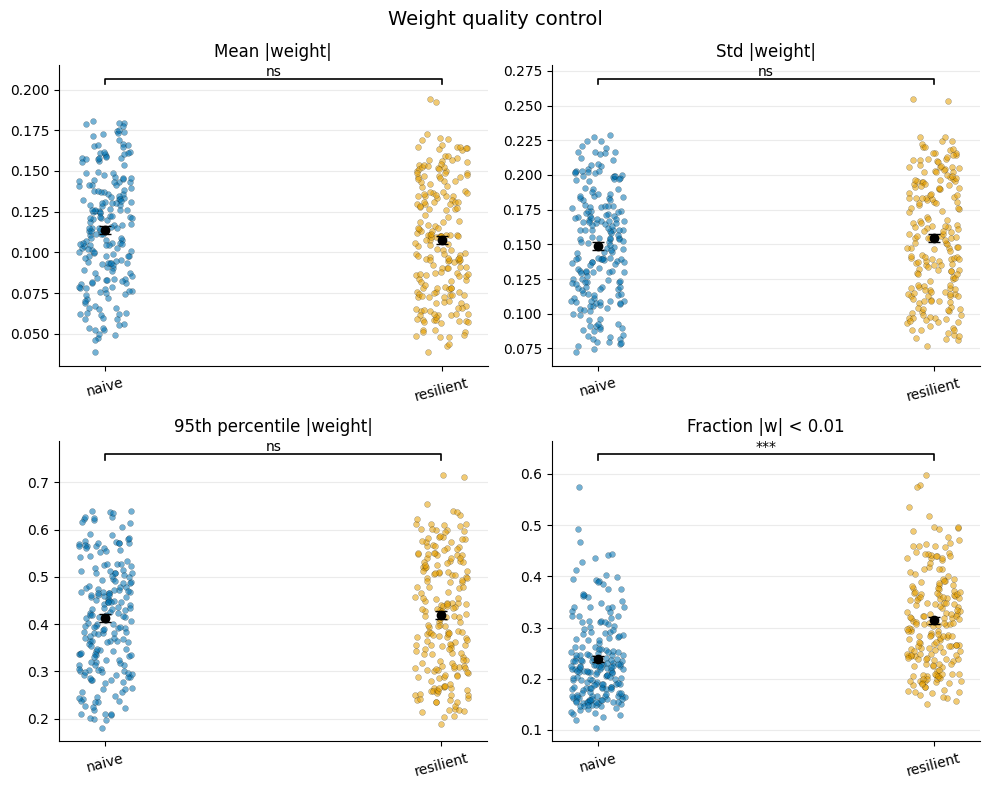

In [ ]:
# ==========================================================
# 08 Plot Weight QC
# ==========================================================

metrics = [
    ("mean_abs_weight", "Mean |weight|"),
    ("std_abs_weight", "Std |weight|"),
    ("p95_abs_weight", "95th percentile |weight|"),
    ("fraction_near_zero_001", "Fraction |w| < 0.01"),
]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()
rng = np.random.default_rng(1)

for ax, (metric, title) in zip(axes, metrics):
    samples = [
        qc_df.loc[qc_df["condition"] == cond, metric].values
        for cond in ["naive", "resilient"]
    ]

    for x, cond, vals in zip([1, 2], ["naive", "resilient"], samples):
        jitter = rng.uniform(-0.08, 0.08, len(vals))
        ax.scatter(np.full(len(vals), x) + jitter, vals, s=18, alpha=0.55,
                   color=COLORS[cond], edgecolor="black", linewidth=0.2)
        ax.errorbar(x, np.mean(vals), yerr=sem(vals), fmt="o", color="black", capsize=4, zorder=5)

    _, p = mannwhitneyu(samples[0], samples[1], alternative="two-sided")
    y_max = max(np.max(samples[0]), np.max(samples[1]))
    y_min = min(np.min(samples[0]), np.min(samples[1]))
    yr = y_max - y_min if y_max > y_min else 1.0
    add_sig_bar(ax, 1, 2, y_max + 0.06 * yr, 0.02 * yr, p_to_stars(p))

    ax.set_xticks([1, 2])
    ax.set_xticklabels(["naive", "resilient"], rotation=15)
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle("Weight quality control", fontsize=14)
plt.tight_layout()
savefig("02_weight_qc")
plt.show()

In [ ]:
# ==========================================================
# 09 Weighted block strength: E->E, I->E, E->I, I->I
# ==========================================================

block_rows = []

for condition, data in all_networks.items():
    N_exc = data["N_exc"]

    for idx, W in enumerate(data["W"]):
        for block in ["E->E", "I->E", "E->I", "I->I"]:
            B = get_block(W, block, N_exc)
            abs_B = np.abs(B)

            block_rows.append({
                "condition": condition,
                "network_idx": idx,
                "block": block,
                "mean_abs_weight": np.mean(abs_B),
                "sum_abs_weight": np.sum(abs_B),
                "median_abs_weight": np.median(abs_B),
                "std_abs_weight": np.std(abs_B),
                "p95_abs_weight": np.percentile(abs_B, 95),
                "max_abs_weight": np.max(abs_B),
            })

block_weight_df = pd.DataFrame(block_rows)
block_weight_df.to_csv(RESULTS / f"weighted_block_strength_{RUN_TIMESTAMP}.csv", index=False)
block_weight_df.head()

,condition,network_idx,block,mean_abs_weight,sum_abs_weight,median_abs_weight,std_abs_weight,p95_abs_weight,max_abs_weight
0,naive,0,E->E,0.089937,575.594020,0.072891,0.081998,0.253145,0.539306
1,naive,0,I->E,0.419917,671.867854,0.356535,0.296925,1.005553,1.951958
2,naive,0,E->I,0.104075,166.519668,0.088656,0.083066,0.262575,0.587217
3,naive,0,I->I,0.400537,160.214716,0.339416,0.299627,0.964857,1.624727
4,naive,1,E->E,0.068533,438.608912,0.052119,0.070599,0.206801,0.533528


Saved figure: 03_weighted_block_strength_2026JUN22_1358


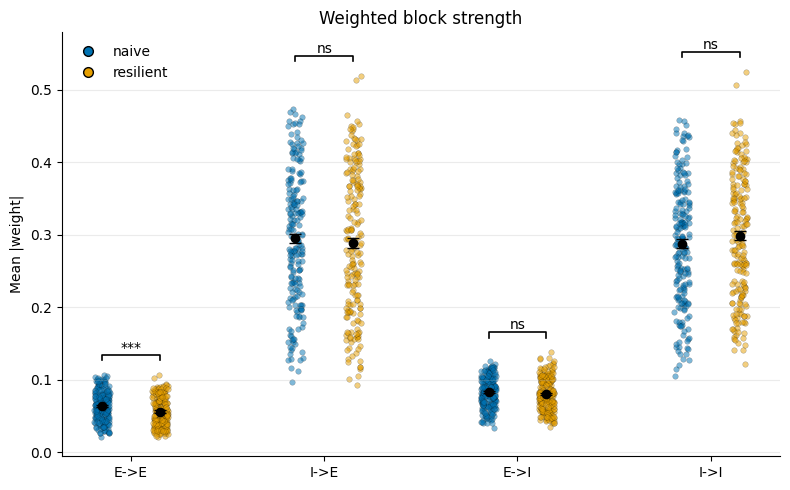

In [ ]:
# ==========================================================
# 10 Plot weighted block strength
# ==========================================================

metric = "mean_abs_weight"
blocks = ["E->E", "I->E", "E->I", "I->I"]

fig, ax = plt.subplots(figsize=(8, 5))
rng = np.random.default_rng(2)

x_positions = np.arange(len(blocks)) + 1
offset = {"naive": -0.15, "resilient": 0.15}

for cond in ["naive", "resilient"]:
    for x, block in zip(x_positions, blocks):
        vals = block_weight_df[(block_weight_df["condition"] == cond) & (block_weight_df["block"] == block)][metric].dropna().values
        jitter = rng.uniform(-0.04, 0.04, len(vals))
        ax.scatter(np.full(len(vals), x + offset[cond]) + jitter, vals, s=16, alpha=0.50,
                   color=COLORS[cond], edgecolor="black", linewidth=0.2)
        ax.errorbar(x + offset[cond], np.mean(vals), yerr=sem(vals), fmt="o", color="black", capsize=4, zorder=5)

for x, block in zip(x_positions, blocks):
    a = block_weight_df[(block_weight_df["condition"] == "naive") & (block_weight_df["block"] == block)][metric].dropna().values
    b = block_weight_df[(block_weight_df["condition"] == "resilient") & (block_weight_df["block"] == block)][metric].dropna().values
    _, p = mannwhitneyu(a, b, alternative="two-sided")
    y = max(np.max(a), np.max(b))
    yr = np.max(block_weight_df[metric]) - np.min(block_weight_df[metric])
    yr = yr if yr > 0 else 1.0
    add_sig_bar(ax, x - 0.15, x + 0.15, y + 0.04 * yr, 0.015 * yr, p_to_stars(p))

ax.set_xticks(x_positions)
ax.set_xticklabels(blocks)
ax.set_ylabel("Mean |weight|")
ax.set_title("Weighted block strength")
ax.grid(axis="y", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

handles = [plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=COLORS[c],
                      markeredgecolor="black", markersize=7, label=c) for c in ["naive", "resilient"]]
ax.legend(handles=handles, frameon=False)

plt.tight_layout()
savefig("03_weighted_block_strength")
plt.show()

In [ ]:
# ==========================================================
# 11 Main threshold q=0.80: density, sparsity, redundancy
# ==========================================================

main_rows = []

for condition, data in all_networks.items():
    N_exc = data["N_exc"]
    for idx, W in enumerate(data["W"]):
        A, thr = threshold_adjacency(W, MAIN_THRESHOLD)

        for block in ["E->E", "I->E", "I->I"]:
            A_block = get_block(A, block, N_exc)
            density = np.mean(A_block)

            main_rows.append({
                "condition": condition,
                "network_idx": idx,
                "threshold_q": MAIN_THRESHOLD,
                "threshold_label": THRESHOLD_LABELS[MAIN_THRESHOLD],
                "threshold_value": thr,
                "block": block,
                "density": density,
                "sparsity": 1 - density,
                "redundancy_jaccard": mean_pairwise_jaccard_rows(A_block),
                "n_edges": int(A_block.sum()),
                "n_possible": int(A_block.size),
            })

main_threshold_df = pd.DataFrame(main_rows)
main_threshold_df.to_csv(RESULTS / f"thresholded_block_metrics_th08_{RUN_TIMESTAMP}.csv", index=False)
main_threshold_df.head()

,condition,network_idx,threshold_q,threshold_label,threshold_value,block,density,sparsity,redundancy_jaccard,n_edges,n_possible
0,naive,0,0.8,q=0.80 / top 20%,0.22918,E->E,0.068125,0.931875,0.033324,436,6400
1,naive,0,0.8,q=0.80 / top 20%,0.22918,I->E,0.708750,0.291250,0.549011,1134,1600
2,naive,0,0.8,q=0.80 / top 20%,0.22918,I->I,0.675000,0.325000,0.505404,270,400
3,naive,1,0.8,q=0.80 / top 20%,0.18328,E->E,0.072188,0.927813,0.040860,462,6400
4,naive,1,0.8,q=0.80 / top 20%,0.18328,I->E,0.672500,0.327500,0.502259,1076,1600


Saved figure: 04_thresholded_density_sparsity_redundancy_q080_2026JUN22_1358


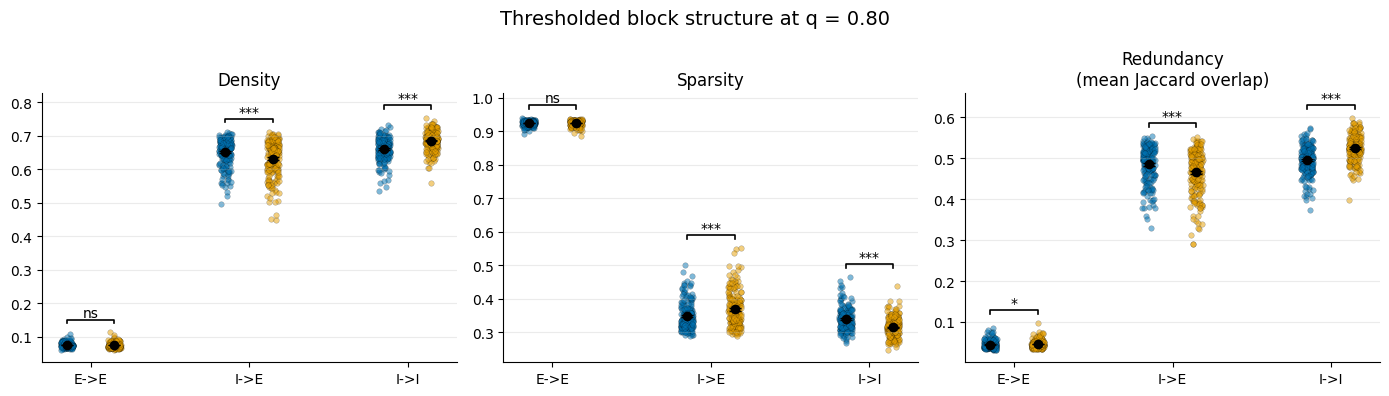

In [ ]:
# ==========================================================
# 12 Plot main threshold q=0.80
# ==========================================================

metrics = [("density", "Density"), ("sparsity", "Sparsity"), ("redundancy_jaccard", "Redundancy\n(mean Jaccard overlap)")]
block_order = ["E->E", "I->E", "I->I"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
rng = np.random.default_rng(3)

for ax, (metric, title) in zip(axes, metrics):
    x_positions = np.arange(len(block_order)) + 1
    offset = {"naive": -0.15, "resilient": 0.15}

    for cond in ["naive", "resilient"]:
        for x, block in zip(x_positions, block_order):
            vals = main_threshold_df[(main_threshold_df["condition"] == cond) & (main_threshold_df["block"] == block)][metric].dropna().values
            jitter = rng.uniform(-0.04, 0.04, len(vals))
            ax.scatter(np.full(len(vals), x + offset[cond]) + jitter, vals, s=16, alpha=0.50,
                       color=COLORS[cond], edgecolor="black", linewidth=0.2)
            ax.errorbar(x + offset[cond], np.mean(vals), yerr=sem(vals), fmt="o", color="black", capsize=4, zorder=5)

    for x, block in zip(x_positions, block_order):
        a = main_threshold_df[(main_threshold_df["condition"] == "naive") & (main_threshold_df["block"] == block)][metric].dropna().values
        b = main_threshold_df[(main_threshold_df["condition"] == "resilient") & (main_threshold_df["block"] == block)][metric].dropna().values
        _, p = mannwhitneyu(a, b, alternative="two-sided")
        y = max(np.max(a), np.max(b))
        yr = max(main_threshold_df[metric].dropna()) - min(main_threshold_df[metric].dropna())
        yr = yr if yr > 0 else 1.0
        add_sig_bar(ax, x - 0.15, x + 0.15, y + 0.04 * yr, 0.015 * yr, p_to_stars(p))

    ax.set_xticks(x_positions)
    ax.set_xticklabels(block_order)
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle("Thresholded block structure at q = 0.80", fontsize=14)
plt.tight_layout()
savefig("04_thresholded_density_sparsity_redundancy_q080")
plt.show()

In [ ]:
# ==========================================================
# 13 Robustness across PI thresholds: None, 0.30, 0.70, 0.80, 0.90
# ==========================================================

robust_rows = []

for q in ROBUSTNESS_THRESHOLDS:
    suffix = threshold_suffix(q)
    for condition, data in all_networks.items():
        N_exc = data["N_exc"]
        for idx, W in enumerate(data["W"]):
            A, thr = threshold_adjacency(W, q)

            for block in ["E->E", "I->E", "I->I"]:
                A_block = get_block(A, block, N_exc)
                robust_rows.append({
                    "condition": condition,
                    "network_idx": idx,
                    "threshold_q": "None" if q is None else q,
                    "threshold_suffix": suffix,
                    "threshold_label": THRESHOLD_LABELS[q],
                    "threshold_value": thr,
                    "block": block,
                    "density": np.mean(A_block),
                    "sparsity": 1 - np.mean(A_block),
                    "redundancy_jaccard": mean_pairwise_jaccard_rows(A_block),
                    "n_edges": int(A_block.sum()),
                    "n_possible": int(A_block.size),
                })

robust_df = pd.DataFrame(robust_rows)
robust_df.to_csv(RESULTS / f"threshold_robustness_all_thresholds_{RUN_TIMESTAMP}.csv", index=False)
robust_df.head()

,condition,network_idx,threshold_q,threshold_suffix,threshold_label,threshold_value,block,density,sparsity,redundancy_jaccard,n_edges,n_possible
0,naive,0,None,thNone,None,0.0,E->E,0.842656,0.157344,0.742074,5393,6400
1,naive,0,None,thNone,None,0.0,I->E,0.984375,0.015625,0.969341,1575,1600
2,naive,0,None,thNone,None,0.0,I->I,0.930000,0.070000,0.865429,372,400
3,naive,1,None,thNone,None,0.0,E->E,0.778125,0.221875,0.660618,4980,6400
4,naive,1,None,thNone,None,0.0,I->E,0.950625,0.049375,0.906459,1521,1600


Saved figure: 05_threshold_robustness_density_redundancy_2026JUN22_1358


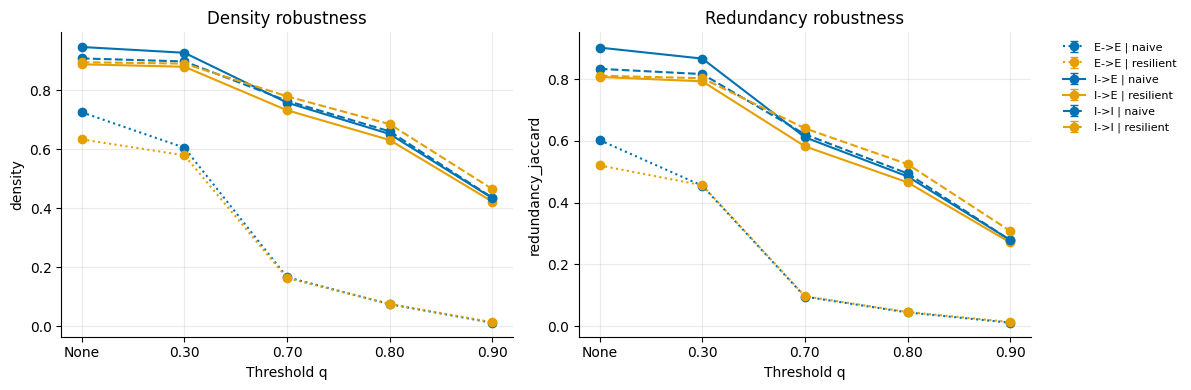

In [ ]:
# ==========================================================
# 14 Plot threshold robustness: density and redundancy
# ==========================================================

plot_order = ["thNone", "th03", "th07", "th08", "th09"]
x_labels = ["None", "0.30", "0.70", "0.80", "0.90"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, metric, title in zip(axes, ["density", "redundancy_jaccard"], ["Density robustness", "Redundancy robustness"]):
    for block in ["E->E", "I->E", "I->I"]:
        for cond in ["naive", "resilient"]:
            means, errors = [], []
            for suffix in plot_order:
                vals = robust_df[(robust_df["condition"] == cond) & (robust_df["block"] == block) & (robust_df["threshold_suffix"] == suffix)][metric].dropna().values
                means.append(np.mean(vals))
                errors.append(sem(vals))

            ax.errorbar(np.arange(len(plot_order)), means, yerr=errors, marker="o",
                        linestyle="-" if block == "I->E" else "--" if block == "I->I" else ":",
                        color=COLORS[cond], capsize=3, label=f"{block} | {cond}")

    ax.set_xticks(np.arange(len(plot_order)))
    ax.set_xticklabels(x_labels)
    ax.set_xlabel("Threshold q")
    ax.set_ylabel(metric)
    ax.set_title(title)
    ax.grid(alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[1].legend(frameon=False, fontsize=8, bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
savefig("05_threshold_robustness_density_redundancy")
plt.show()

In [ ]:
# ==========================================================
# 15 Inhibitory input redistribution: WEI and WII focus
# ==========================================================
# W_rec[post, pre]
# I->E block = W[E targets, I sources]
# I->I block = W[I targets, I sources]
# Out-degree/out-strength is column-based because W[post, pre].
# In-degree/in-strength is row-based.

ei_rows = []

for condition, data in all_networks.items():
    N_exc = data["N_exc"]

    for idx, W in enumerate(data["W"]):
        N = W.shape[0]
        exc, inh = get_indices(N_exc, N)

        E_input_abs = np.sum(np.abs(W[:, exc]), axis=1)
        I_input_abs = np.sum(np.abs(W[:, inh]), axis=1)

        W_EE = get_block(W, "E->E", N_exc)
        W_IE = get_block(W, "I->E", N_exc)
        W_EI = get_block(W, "E->I", N_exc)
        W_II = get_block(W, "I->I", N_exc)

        ei_rows.append({
            "condition": condition,
            "network_idx": idx,
            "mean_abs_WEI": np.mean(np.abs(W_IE)),
            "sum_abs_WEI": np.sum(np.abs(W_IE)),
            "mean_abs_WII": np.mean(np.abs(W_II)),
            "sum_abs_WII": np.sum(np.abs(W_II)),
            "mean_abs_WEE": np.mean(np.abs(W_EE)),
            "sum_abs_WEE": np.sum(np.abs(W_EE)),
            "mean_I_input_to_E": np.mean(I_input_abs[exc]),
            "mean_I_input_to_I": np.mean(I_input_abs[inh]),
            "mean_E_input_to_E": np.mean(E_input_abs[exc]),
            "mean_E_input_to_I": np.mean(E_input_abs[inh]),
            "mean_log10_EI_Etargets": np.mean(np.log10((E_input_abs[exc] + 1e-12) / (I_input_abs[exc] + 1e-12))),
            "mean_log10_EI_Itargets": np.mean(np.log10((E_input_abs[inh] + 1e-12) / (I_input_abs[inh] + 1e-12))),
        })

ei_df = pd.DataFrame(ei_rows)
ei_df.to_csv(RESULTS / f"inhibitory_input_redistribution_{RUN_TIMESTAMP}.csv", index=False)
ei_df.head()

,condition,network_idx,mean_abs_WEI,sum_abs_WEI,mean_abs_WII,sum_abs_WII,mean_abs_WEE,sum_abs_WEE,mean_I_input_to_E,mean_I_input_to_I,mean_E_input_to_E,mean_E_input_to_I,mean_log10_EI_Etargets,mean_log10_EI_Itargets
0,naive,0,0.419917,671.867854,0.400537,160.214716,0.089937,575.594020,8.398348,8.010736,7.194925,8.325983,-0.066015,0.017376
1,naive,1,0.316327,506.123245,0.316974,126.789411,0.068533,438.608912,6.326541,6.339471,5.482611,6.755314,-0.059584,0.023217
2,naive,2,0.466275,746.039881,0.435947,174.378620,0.104464,668.570902,9.325499,8.718931,8.357136,9.133248,-0.048596,0.021321
3,naive,3,0.248777,398.043753,0.252479,100.991404,0.054151,346.563421,4.975547,5.049570,4.332043,5.981549,-0.053491,0.074520
4,naive,4,0.128460,205.536303,0.128043,51.217293,0.029473,188.625824,2.569204,2.560865,2.357823,3.623988,-0.046190,0.153034


Saved figure: 06_inhibitory_input_redistribution_2026JUN22_1358


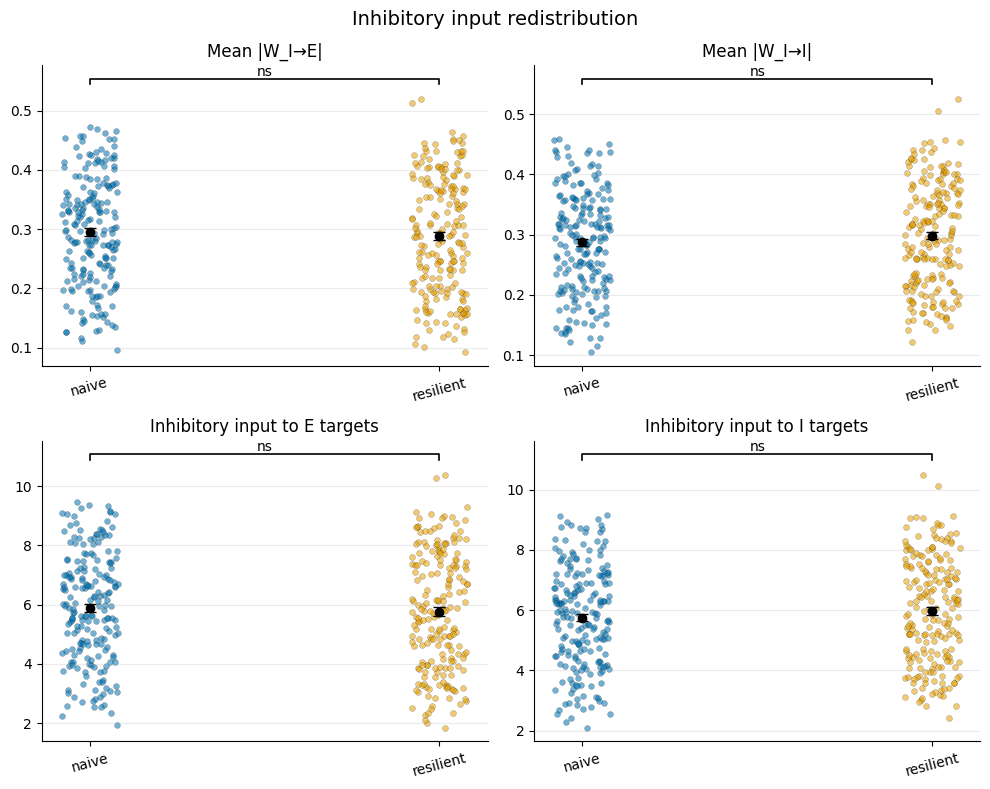

In [ ]:
# ==========================================================
# 16 Plot inhibitory redistribution
# ==========================================================

metrics = [
    ("mean_abs_WEI", "Mean |W_I→E|"),
    ("mean_abs_WII", "Mean |W_I→I|"),
    ("mean_I_input_to_E", "Inhibitory input to E targets"),
    ("mean_I_input_to_I", "Inhibitory input to I targets"),
]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()
rng = np.random.default_rng(4)

for ax, (metric, title) in zip(axes, metrics):
    samples = [ei_df.loc[ei_df["condition"] == cond, metric].dropna().values for cond in ["naive", "resilient"]]
    for x, cond, vals in zip([1, 2], ["naive", "resilient"], samples):
        jitter = rng.uniform(-0.08, 0.08, len(vals))
        ax.scatter(np.full(len(vals), x) + jitter, vals, s=18, alpha=0.55,
                   color=COLORS[cond], edgecolor="black", linewidth=0.2)
        ax.errorbar(x, np.mean(vals), yerr=sem(vals), fmt="o", color="black", capsize=4)

    _, p = mannwhitneyu(samples[0], samples[1], alternative="two-sided")
    y = max(np.max(samples[0]), np.max(samples[1]))
    y_min = min(np.min(samples[0]), np.min(samples[1]))
    yr = y - y_min if y > y_min else 1.0
    add_sig_bar(ax, 1, 2, y + 0.06 * yr, 0.02 * yr, p_to_stars(p))
    ax.set_xticks([1, 2])
    ax.set_xticklabels(["naive", "resilient"], rotation=15)
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle("Inhibitory input redistribution", fontsize=14)
plt.tight_layout()
savefig("06_inhibitory_input_redistribution")
plt.show()

In [ ]:
# ==========================================================
# 17 Directed network metrics for all thresholds
# ==========================================================

def compute_directed_metrics_from_A(A, condition, network_idx, q, thr):
    G = build_digraph_from_A(A)

    in_deg = np.array([d for _, d in G.in_degree()], dtype=float)
    out_deg = np.array([d for _, d in G.out_degree()], dtype=float)

    row = {
        "condition": condition, "network_idx": network_idx,
        "threshold_q": "None" if q is None else q,
        "threshold_suffix": threshold_suffix(q),
        "threshold_label": THRESHOLD_LABELS[q],
        "threshold_value": thr,
        "num_nodes": G.number_of_nodes(),
        "num_edges": G.number_of_edges(),
        "density": nx.density(G),
        "reciprocity": nx.reciprocity(G),
        "mean_degree_total": np.mean([d for _, d in G.degree()]),
        "mean_in_degree": np.mean(in_deg),
        "mean_out_degree": np.mean(out_deg),
        "std_in_degree": np.std(in_deg),
        "std_out_degree": np.std(out_deg),
        "max_in_degree": np.max(in_deg),
        "max_out_degree": np.max(out_deg),
        "num_weakly_connected_components": nx.number_weakly_connected_components(G),
        "num_strongly_connected_components": nx.number_strongly_connected_components(G),
        "transitivity": nx.transitivity(G),
        "avg_clustering_directed": nx.average_clustering(G),
    }

    try:
        row["assortativity_total_degree"] = nx.degree_assortativity_coefficient(G)
    except Exception:
        row["assortativity_total_degree"] = np.nan

    try:
        pr = nx.pagerank(G)
        row["mean_pagerank"] = np.mean(list(pr.values()))
        row["std_pagerank"] = np.std(list(pr.values()))
        row["max_pagerank"] = np.max(list(pr.values()))
    except Exception:
        row["mean_pagerank"] = np.nan
        row["std_pagerank"] = np.nan
        row["max_pagerank"] = np.nan

    try:
        katz = nx.katz_centrality_numpy(G, alpha=0.01)
        row["mean_katz_centrality"] = np.mean(list(katz.values()))
        row["std_katz_centrality"] = np.std(list(katz.values()))
        row["max_katz_centrality"] = np.max(list(katz.values()))
    except Exception:
        row["mean_katz_centrality"] = np.nan
        row["std_katz_centrality"] = np.nan
        row["max_katz_centrality"] = np.nan

    try:
        bc = nx.betweenness_centrality(G, normalized=True)
        row["mean_betweenness_centrality"] = np.mean(list(bc.values()))
        row["std_betweenness_centrality"] = np.std(list(bc.values()))
        row["max_betweenness_centrality"] = np.max(list(bc.values()))
    except Exception:
        row["mean_betweenness_centrality"] = np.nan
        row["std_betweenness_centrality"] = np.nan
        row["max_betweenness_centrality"] = np.nan

    return row


directed_rows = []

for q in ROBUSTNESS_THRESHOLDS:
    for condition, data in all_networks.items():
        for idx, W in enumerate(data["W"]):
            A, thr = threshold_adjacency(W, q)
            directed_rows.append(compute_directed_metrics_from_A(A, condition, idx, q, thr))

directed_metrics_all_df = pd.DataFrame(directed_rows)

for suffix, sub in directed_metrics_all_df.groupby("threshold_suffix"):
    sub.to_csv(RESULTS / f"directed_network_metrics_{suffix}_{RUN_TIMESTAMP}.csv", index=False)

directed_metrics_all_df.to_csv(RESULTS / f"directed_network_metrics_all_thresholds_{RUN_TIMESTAMP}.csv", index=False)
directed_metrics_all_df.head()

,condition,network_idx,threshold_q,threshold_suffix,threshold_label,threshold_value,num_nodes,num_edges,density,reciprocity,...,assortativity_total_degree,mean_pagerank,std_pagerank,max_pagerank,mean_katz_centrality,std_katz_centrality,max_katz_centrality,mean_betweenness_centrality,std_betweenness_centrality,max_betweenness_centrality
0,naive,0,None,thNone,None,0.0,100,8791,0.887980,0.897281,...,-0.070537,0.01,0.000569,0.011165,0.099864,0.005220,0.110555,0.001143,0.000279,0.001666
1,naive,1,None,thNone,None,0.0,100,8204,0.828687,0.857387,...,-0.096427,0.01,0.000995,0.011919,0.099637,0.008516,0.115781,0.001748,0.000663,0.003086
2,naive,2,None,thNone,None,0.0,100,8757,0.884545,0.893228,...,-0.055621,0.01,0.000576,0.011179,0.099849,0.005486,0.110964,0.001178,0.000230,0.001689
3,naive,3,None,thNone,None,0.0,100,7736,0.781414,0.811272,...,-0.089591,0.01,0.001018,0.012298,0.099671,0.008107,0.117580,0.002230,0.000876,0.004186
4,naive,4,None,thNone,None,0.0,100,6265,0.632828,0.692737,...,-0.109921,0.01,0.001741,0.013882,0.099372,0.011189,0.123595,0.003747,0.002182,0.009053


In [ ]:
# ==========================================================
# 18 Weighted directed network metrics for all thresholds
# ==========================================================

def compute_weighted_directed_metrics_from_W(W, condition, network_idx, q):
    G, thr = build_weighted_digraph_from_W(W, q=q)
    in_strength = np.array([d for _, d in G.in_degree(weight="weight_abs")], dtype=float)
    out_strength = np.array([d for _, d in G.out_degree(weight="weight_abs")], dtype=float)

    row = {
        "condition": condition, "network_idx": network_idx,
        "threshold_q": "None" if q is None else q,
        "threshold_suffix": threshold_suffix(q),
        "threshold_label": THRESHOLD_LABELS[q],
        "threshold_value": thr,
        "num_nodes": G.number_of_nodes(),
        "num_edges": G.number_of_edges(),
        "density": nx.density(G),
        "reciprocity": nx.reciprocity(G),
        "mean_in_strength_abs": np.mean(in_strength),
        "mean_out_strength_abs": np.mean(out_strength),
        "mean_total_strength_abs": np.mean(in_strength + out_strength),
        "std_in_strength_abs": np.std(in_strength),
        "std_out_strength_abs": np.std(out_strength),
        "max_in_strength_abs": np.max(in_strength),
        "max_out_strength_abs": np.max(out_strength),
        "transitivity_unweighted": nx.transitivity(G),
        "avg_clustering_weighted_abs": nx.average_clustering(G, weight="weight_abs"),
    }

    pos_in, neg_in, pos_out, neg_out = [], [], [], []

    for node in G.nodes():
        in_edges = G.in_edges(node, data=True)
        out_edges = G.out_edges(node, data=True)
        pos_in.append(sum(d["weight_signed"] for _, _, d in in_edges if d["weight_signed"] > 0))
        neg_in.append(sum(abs(d["weight_signed"]) for _, _, d in in_edges if d["weight_signed"] < 0))
        pos_out.append(sum(d["weight_signed"] for _, _, d in out_edges if d["weight_signed"] > 0))
        neg_out.append(sum(abs(d["weight_signed"]) for _, _, d in out_edges if d["weight_signed"] < 0))

    row["mean_positive_in_weight"] = np.mean(pos_in)
    row["mean_negative_in_weight_abs"] = np.mean(neg_in)
    row["mean_positive_out_weight"] = np.mean(pos_out)
    row["mean_negative_out_weight_abs"] = np.mean(neg_out)

    try:
        pr = nx.pagerank(G, alpha=0.85, weight="weight_abs")
        row["mean_pagerank_weighted"] = np.mean(list(pr.values()))
        row["std_pagerank_weighted"] = np.std(list(pr.values()))
        row["max_pagerank_weighted"] = np.max(list(pr.values()))
    except Exception:
        row["mean_pagerank_weighted"] = np.nan
        row["std_pagerank_weighted"] = np.nan
        row["max_pagerank_weighted"] = np.nan

    try:
        katz = nx.katz_centrality_numpy(G, alpha=0.01, beta=1.0, weight="weight_abs")
        row["mean_katz_weighted"] = np.mean(list(katz.values()))
        row["std_katz_weighted"] = np.std(list(katz.values()))
        row["max_katz_weighted"] = np.max(list(katz.values()))
    except Exception:
        row["mean_katz_weighted"] = np.nan
        row["std_katz_weighted"] = np.nan
        row["max_katz_weighted"] = np.nan

    try:
        bc = nx.betweenness_centrality(G, weight="weight_abs", normalized=True)
        row["mean_betweenness_weighted"] = np.mean(list(bc.values()))
        row["std_betweenness_weighted"] = np.std(list(bc.values()))
        row["max_betweenness_weighted"] = np.max(list(bc.values()))
    except Exception:
        row["mean_betweenness_weighted"] = np.nan
        row["std_betweenness_weighted"] = np.nan
        row["max_betweenness_weighted"] = np.nan

    return row


weighted_directed_rows = []

for q in ROBUSTNESS_THRESHOLDS:
    for condition, data in all_networks.items():
        for idx, W in enumerate(data["W"]):
            weighted_directed_rows.append(compute_weighted_directed_metrics_from_W(W, condition, idx, q))

weighted_directed_metrics_all_df = pd.DataFrame(weighted_directed_rows)

for suffix, sub in weighted_directed_metrics_all_df.groupby("threshold_suffix"):
    sub.to_csv(RESULTS / f"weighted_directed_network_metrics_{suffix}_{RUN_TIMESTAMP}.csv", index=False)

weighted_directed_metrics_all_df.to_csv(RESULTS / f"weighted_directed_network_metrics_all_thresholds_{RUN_TIMESTAMP}.csv", index=False)
weighted_directed_metrics_all_df.head()

,condition,network_idx,threshold_q,threshold_suffix,threshold_label,threshold_value,num_nodes,num_edges,density,reciprocity,...,mean_negative_out_weight_abs,mean_pagerank_weighted,std_pagerank_weighted,max_pagerank_weighted,mean_katz_weighted,std_katz_weighted,max_katz_weighted,mean_betweenness_weighted,std_betweenness_weighted,max_betweenness_weighted
0,naive,0,None,thNone,None,0.0,100,8791,0.887980,0.897281,...,8.320826,0.01,0.001193,0.013028,0.099984,0.001791,0.104763,0.026770,0.031447,0.178211
1,naive,1,None,thNone,None,0.0,100,8204,0.828687,0.857387,...,6.329127,0.01,0.001442,0.013853,0.099986,0.001678,0.104332,0.023904,0.029993,0.177180
2,naive,2,None,thNone,None,0.0,100,8757,0.884545,0.893228,...,9.204185,0.01,0.001003,0.012392,0.099986,0.001662,0.104106,0.023400,0.031910,0.194805
3,naive,3,None,thNone,None,0.0,100,7736,0.781414,0.811272,...,4.990352,0.01,0.001639,0.014975,0.099988,0.001530,0.103697,0.023071,0.023574,0.098330
4,naive,4,None,thNone,None,0.0,100,6265,0.632828,0.692737,...,2.567536,0.01,0.002514,0.016246,0.099992,0.001233,0.102805,0.025404,0.039074,0.224799


Saved figure: directed_three_metrics_th08_2026JUN22_1358


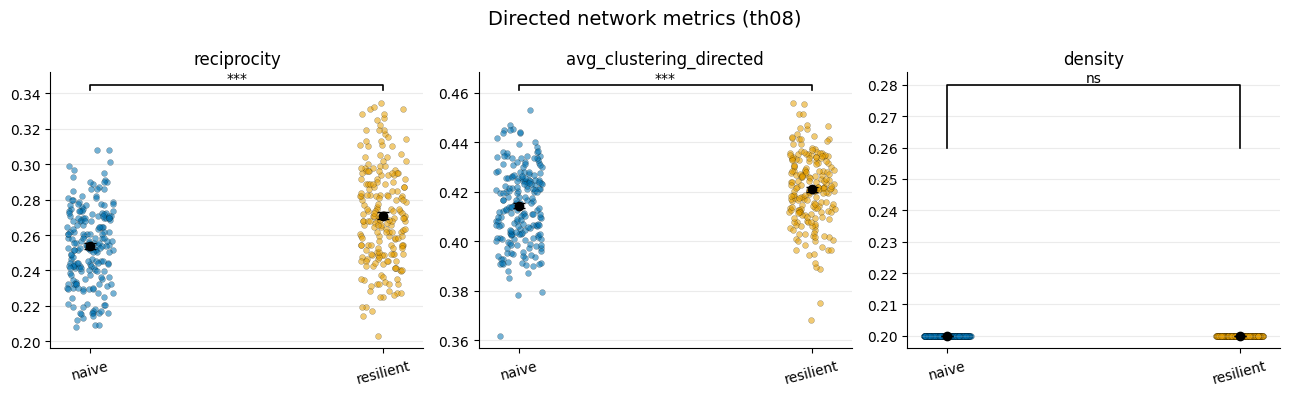

In [ ]:
# ==========================================================
# 19 Plot any three metrics from a network-metrics dataframe
# ==========================================================

def plot_three_network_metrics(df, metrics, threshold_suffix_to_use="th08",
                               title_prefix="Network metrics",
                               save_prefix="network_metrics_three_panel"):
    assert len(metrics) == 3, "Provide exactly three metric names."

    plot_df = df[df["threshold_suffix"] == threshold_suffix_to_use].copy()

    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    rng = np.random.default_rng(11)

    for ax, metric in zip(axes, metrics):
        samples = [plot_df.loc[plot_df["condition"] == cond, metric].dropna().values for cond in ["naive", "resilient"]]

        for x, cond, vals in zip([1, 2], ["naive", "resilient"], samples):
            jitter = rng.uniform(-0.08, 0.08, len(vals))
            ax.scatter(np.full(len(vals), x) + jitter, vals, s=18, alpha=0.55,
                       color=COLORS[cond], edgecolor="black", linewidth=0.2)
            ax.errorbar(x, np.mean(vals), yerr=sem(vals), fmt="o", color="black", capsize=4, zorder=5)

        if len(samples[0]) > 0 and len(samples[1]) > 0:
            _, p = mannwhitneyu(samples[0], samples[1], alternative="two-sided")
            y = max(np.max(samples[0]), np.max(samples[1]))
            y_min = min(np.min(samples[0]), np.min(samples[1]))
            yr = y - y_min if y > y_min else 1.0
            add_sig_bar(ax, 1, 2, y + 0.06 * yr, 0.02 * yr, p_to_stars(p))

        ax.set_xticks([1, 2])
        ax.set_xticklabels(["naive", "resilient"], rotation=15)
        ax.set_title(metric)
        ax.grid(axis="y", alpha=0.25)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    plt.suptitle(f"{title_prefix} ({threshold_suffix_to_use})", fontsize=14)
    plt.tight_layout()
    savefig(f"{save_prefix}_{threshold_suffix_to_use}")
    plt.show()


metrics_to_plot = ["reciprocity", "avg_clustering_directed", "density"]

plot_three_network_metrics(
    directed_metrics_all_df,
    metrics=metrics_to_plot,
    threshold_suffix_to_use="th08",
    title_prefix="Directed network metrics",
    save_prefix="directed_three_metrics",
)

In [ ]:
# ==========================================================
# 20 Spectral metrics from full W_rec
# ==========================================================

spectral_rows = []

for condition, data in all_networks.items():
    for idx, W in enumerate(data["W"]):
        eigvals = np.linalg.eigvals(W)
        spectral_rows.append({
            "condition": condition,
            "network_idx": idx,
            "spectral_radius": np.max(np.abs(eigvals)),
            "max_real_eigenvalue": np.max(np.real(eigvals)),
            "fraction_outside_unit_circle": np.mean(np.abs(eigvals) > 1),
            "mean_abs_eigenvalue": np.mean(np.abs(eigvals)),
        })

spectral_df = pd.DataFrame(spectral_rows)
spectral_df.to_csv(RESULTS / f"spectral_metrics_{RUN_TIMESTAMP}.csv", index=False)
spectral_df.head()

,condition,network_idx,spectral_radius,max_real_eigenvalue,fraction_outside_unit_circle,mean_abs_eigenvalue
0,naive,0,3.662753,1.748768,0.22,0.781719
1,naive,1,2.764289,1.713817,0.16,0.645881
2,naive,2,3.539872,2.044340,0.29,0.872521
3,naive,3,3.020871,1.869346,0.07,0.552048
4,naive,4,1.910844,1.390865,0.06,0.348929


Saved figure: 09_spectral_metrics_2026JUN22_1358


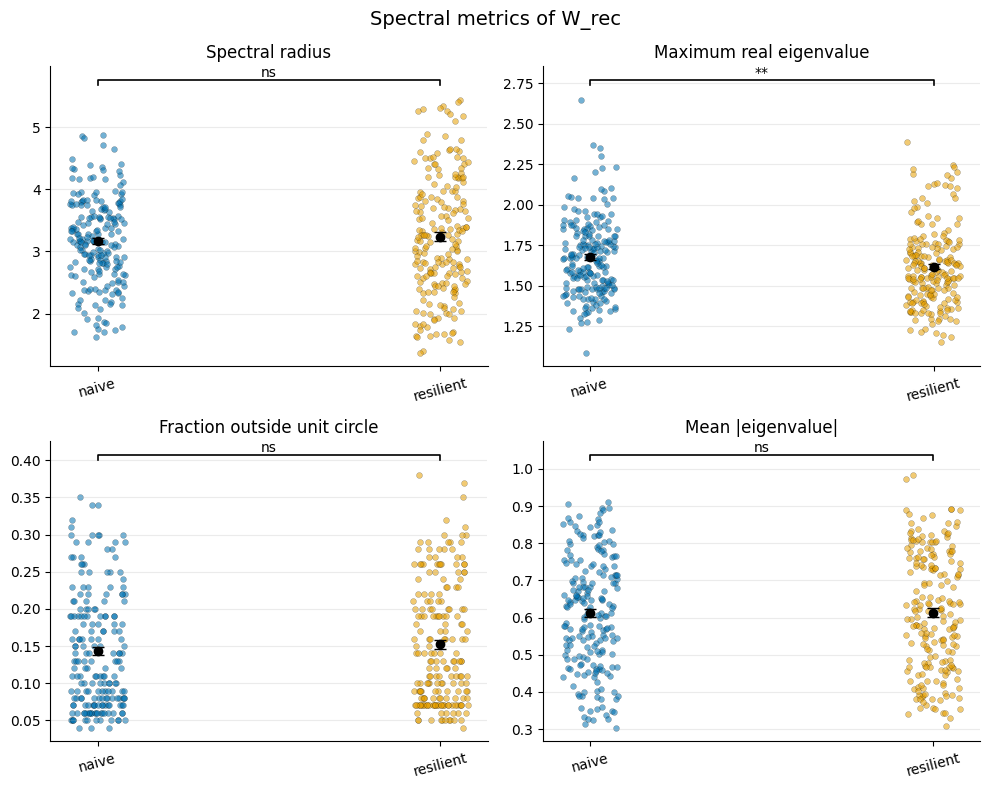

In [ ]:
# ==========================================================
# 21 Plot spectral metrics
# ==========================================================

metrics = [
    ("spectral_radius", "Spectral radius"),
    ("max_real_eigenvalue", "Maximum real eigenvalue"),
    ("fraction_outside_unit_circle", "Fraction outside unit circle"),
    ("mean_abs_eigenvalue", "Mean |eigenvalue|"),
]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()
rng = np.random.default_rng(7)

for ax, (metric, title) in zip(axes, metrics):
    samples = [spectral_df.loc[spectral_df["condition"] == cond, metric].dropna().values for cond in ["naive", "resilient"]]

    for x, cond, vals in zip([1, 2], ["naive", "resilient"], samples):
        jitter = rng.uniform(-0.08, 0.08, len(vals))
        ax.scatter(np.full(len(vals), x) + jitter, vals, s=18, alpha=0.55,
                   color=COLORS[cond], edgecolor="black", linewidth=0.2)
        ax.errorbar(x, np.mean(vals), yerr=sem(vals), fmt="o", color="black", capsize=4)

    _, p = mannwhitneyu(samples[0], samples[1], alternative="two-sided")
    y = max(np.max(samples[0]), np.max(samples[1]))
    y_min = min(np.min(samples[0]), np.min(samples[1]))
    yr = y - y_min if y > y_min else 1.0
    add_sig_bar(ax, 1, 2, y + 0.06 * yr, 0.02 * yr, p_to_stars(p))

    ax.set_xticks([1, 2])
    ax.set_xticklabels(["naive", "resilient"], rotation=15)
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle("Spectral metrics of W_rec", fontsize=14)
plt.tight_layout()
savefig("09_spectral_metrics")
plt.show()

In [ ]:
# ==========================================================
# 22 Final overview of exported files
# ==========================================================

print("Figures saved to:")
print(IMAGES)

print("\nTables/results saved to:")
print(RESULTS)

print("\nGenerated CSV files:")
for f in sorted(RESULTS.glob("*.csv")):
    print(f.name)

Figures saved to:
/content/drive/MyDrive/NWAnaRNN_2026JUN/images

Tables/results saved to:
/content/drive/MyDrive/NWAnaRNN_2026JUN/results

Generated CSV files:
directed_network_metrics_all_thresholds_2026JUN22_1358.csv
directed_network_metrics_all_thresholds_2026JUN22_1441.csv
directed_network_metrics_th03_2026JUN22_1358.csv
directed_network_metrics_th07_2026JUN22_1358.csv
directed_network_metrics_th08_2026JUN22_1358.csv
directed_network_metrics_th09_2026JUN22_1358.csv
directed_network_metrics_th30_2026JUN22_1441.csv
directed_network_metrics_th50_2026JUN22_1441.csv
directed_network_metrics_th70_2026JUN22_1441.csv
directed_network_metrics_th80_2026JUN22_1441.csv
directed_network_metrics_th90_2026JUN22_1441.csv
directed_network_metrics_thNone_2026JUN22_1358.csv
directed_network_metrics_thnone_2026JUN22_1441.csv
inhibitory_input_redistribution_2026JUN22_1358.csv
inhibitory_input_redistribution_2026JUN22_1430.csv
spectral_metrics_2026JUN22_1358.csv
threshold_robustness_all_thresholds_2026

# methods

## Network Construction and Threshold Selection

Recurrent connectivity was extracted from the effective recurrent weight matrix (W_{rec}), which incorporates Dale's principle and the learned structural connectivity mask. Following training, (W_{rec}) was interpreted as a directed connectivity matrix, where matrix elements (W_{ij}) represent synaptic projections from presynaptic neuron (j) to postsynaptic neuron (i). Positive weights correspond to excitatory projections, whereas negative weights correspond to inhibitory projections.

To enable graph-theoretical analyses, thresholded directed graphs were constructed from the absolute recurrent weights (|W_{ij}|) using a quantile-based thresholding strategy. The primary analyses employed the 80th percentile of the empirical weight distribution, retaining the strongest 20% of recurrent connections. This threshold was selected because it removes a substantial fraction of weak, near-zero weights while preserving sufficiently dense graphs for robust estimation of graph-theoretical measures. Furthermore, naive and resilient networks exhibited highly similar threshold values at this quantile, reducing potential biases associated with condition-specific thresholding.

To evaluate the robustness of network-level conclusions, supplementary analyses were performed across multiple thresholds corresponding to retaining all connections (None), as well as the strongest 70%, 50%, 30%, 20%, and 10% of recurrent connections (quantiles (q=) 0.30, 0.50, 0.70, 0.80, and 0.90, respectively). Results obtained across these thresholds were used to assess the sensitivity of graph metrics to edge selection.

## Block-wise Connectivity Analysis

The excitatory and inhibitory populations were identified according to the network architecture. The recurrent weight matrix was partitioned into four submatrices corresponding to excitatory-to-excitatory (E→E), excitatory-to-inhibitory (E→I), inhibitory-to-excitatory (I→E), and inhibitory-to-inhibitory (I→I) projections. Particular emphasis was placed on I→E connectivity, which was directly exposed to multiplicative stress during training, and I→I connectivity, which remained unaffected by the imposed perturbations.

For each connectivity block, weighted metrics including mean absolute weight, total synaptic strength, median weight, and upper-tail statistics were calculated. After thresholding, graph density, sparsity, and redundancy measures were additionally quantified.

## Directed Graph Analysis

Thresholded recurrent connectivity matrices were represented as directed graphs using NetworkX. Graph construction preserved the orientation implied by the recurrent weight matrix such that an edge from neuron (j) to neuron (i) corresponds to a non-zero element (W_{ij}). Consequently, graph edges follow the convention:

[
j \rightarrow i ;;\Leftrightarrow;; W_{ij}
]

Directed graph metrics included in-degree, out-degree, reciprocity, clustering coefficient, PageRank, Katz centrality, and the number of weakly and strongly connected components. Degree-based metrics were computed globally and separately within selected connectivity blocks, with particular focus on inhibitory projections to excitatory neurons (I→E) and inhibitory recurrent interactions (I→I).

## Redundancy Analysis

Redundancy within inhibitory subnetworks was estimated by quantifying the overlap of inhibitory input patterns between neurons. Pairwise similarity measures were computed on thresholded adjacency matrices using Jaccard overlap coefficients, providing an estimate of shared inhibitory pathways. Redundancy analyses focused primarily on I→E and I→I subnetworks to assess whether resilience training promotes alternative inhibitory routes capable of compensating for perturbations.

## Spectral Analysis

Spectral properties of the full weighted recurrent matrices were investigated without thresholding. Metrics included the spectral radius, the largest real eigenvalue, the distribution of eigenvalues in the complex plane, and the fraction of eigenvalues located outside the unit circle. These analyses were used to characterize the dynamical regime of recurrent activity and to evaluate whether resilience training alters global network stability.

## Statistical Analysis

Comparisons between naive and resilient networks were performed using two-sided Mann–Whitney U tests, as the distributions of graph-theoretical measures were not assumed to be normally distributed. Statistical significance was reported using the following convention: ns ((p \geq 0.05)), * ((p < 0.05)), ** ((p < 0.01)), and *** ((p < 0.001)). Throughout the study, individual networks constituted independent observations, resulting in sample sizes of (n=200) networks per experimental condition.


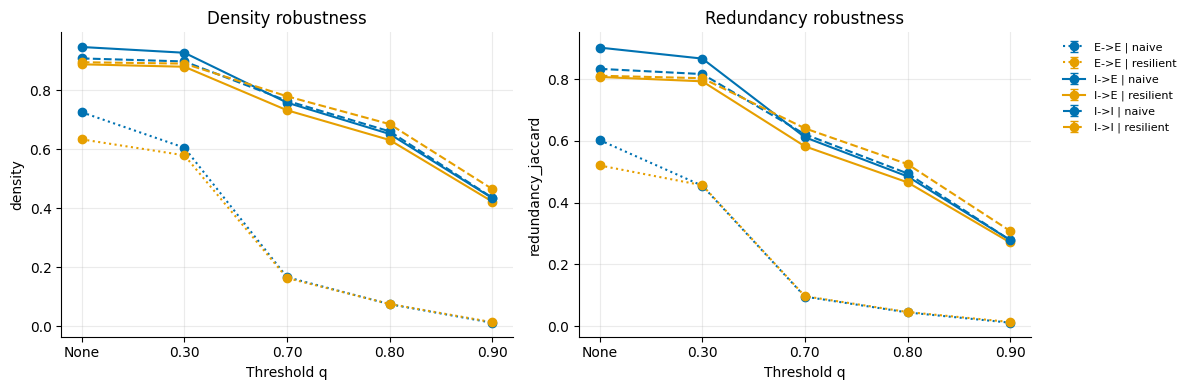


## Threshold robustness

This figure evaluates whether the inferred network organization depends on the specific threshold used for graph construction.

Binary directed graphs were generated by retaining progressively stronger fractions of recurrent connections:

| Quantile q | Retained edges |
|-----------|----------------|
| None | 100% |
| 0.30 | 70% |
| 0.70 | 30% |
| 0.80 | 20% |
| 0.90 | 10% |

For each threshold, graph density and redundancy were computed separately for the

* E→E subnetworks
* I→E subnetworks
* I→I subnetworks

---

### Density robustness

Network density was calculated as

\[
Density = \frac{E}{N(N-1)}
\]

where \(E\) denotes the number of existing directed edges.

The E→E and I→I subnetworks exhibit a gradual decrease in density with increasing threshold stringency and remain relatively densely connected even at higher thresholds.

In contrast, the I→E subnetworks rapidly lose connectivity as weaker edges are removed. This suggests that inhibitory projections onto excitatory neurons are concentrated within a comparatively small subset of stronger inhibitory connections.

Overall, density profiles are highly similar between naïve and resilient networks, indicating that the observed structural organization is largely robust to threshold selection.

---

### Redundancy robustness

Redundancy was estimated using pairwise Jaccard overlap coefficients, which quantify the extent to which neurons share common presynaptic inputs.

Higher values indicate the presence of multiple alternative pathways, whereas lower values reflect more specialized connectivity.

The E→E and I→I subnetworks show a smooth decline in redundancy across thresholds, suggesting a distributed and robust organization.

The I→E subnetworks display a marked reduction in shared inhibitory inputs at stringent thresholds, indicating that only a small subset of strong inhibitory projections remains common across excitatory neurons.

---

### Interpretation

These results demonstrate that the major structural conclusions are not strongly dependent on the chosen graph threshold.

In particular,

* E→E and I→I connectivity patterns appear robust across threshold choices.
* I→E connectivity is mediated by a relatively sparse subset of stronger inhibitory projections.
* The similarity between naïve and resilient networks across thresholds suggests that resilience training does not globally alter network density, but may instead induce more subtle redistributions within inhibitory subnetworks.

This analysis supports the use of **q = 0.80** as the primary threshold for graph construction, while confirming that the main findings are preserved across a broad range of threshold values.
